First part deals with creating our own RSE neighbourhood map aggregate.

In [238]:
import pandas as pd


# Load the Census/RSE Mapping Data (CSV)
census_path = '../data_processed/rse_x_census data 2025.csv'
df_census = pd.read_csv(census_path)

# --- 0) Pre-join baselines ---
n_before = len(df_census)
n_events_before = df_census["cad_event_number"].nunique(dropna=False) if "cad_event_number" in df_census.columns else None

print("=== PRE-JOIN ===")
print(f"Rows (df_census): {n_before:,}")


=== PRE-JOIN ===
Rows (df_census): 179


In [239]:
from pathlib import Path
import csv

df_census_copy = df_census.copy()

# 1) Drop all columns that are percentiles (and optionally quintiles)
cols_to_drop = [c for c in df_census_copy.columns if "Percentile" in c]
df_no_pct = df_census_copy.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} percentile columns.")
print("Remaining columns:", df_no_pct.shape[1])

# (Optional) also drop Quintile columns if you don't want them either
quintile_cols = [c for c in df_no_pct.columns if "Quintile" in c]
df_no_pct = df_no_pct.drop(columns=quintile_cols)

print(f"Dropped {len(quintile_cols)} quantile columns.")
print("Remaining columns:", df_no_pct.shape[1])

# 2) Count how many unique GEOIDs per Community Reporting Area
geo_col = "GEOID"
cra_col = "Community Reporting Area Name"

geoid_per_cra = (df_no_pct.groupby(cra_col)[geo_col]
                 .nunique(dropna=False)
                 .sort_values(ascending=False)
                 .reset_index(name="n_geoids"))

print("\nTop 20 CRAs by number of GEOIDs:")
print(geoid_per_cra.head(20))

# Optional quick summary
print("\nDistribution of n_geoids across CRAs:")
print(geoid_per_cra["n_geoids"].describe())

out_path = Path("../data_processed/intermediate_stats/geoid_neighborhood_mapstat.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
geoid_per_cra.to_csv(out_path, index=False)

Dropped 12 percentile columns.
Remaining columns: 43
Dropped 4 quantile columns.
Remaining columns: 39

Top 20 CRAs by number of GEOIDs:
         Community Reporting Area Name  n_geoids
0                           Queen Anne        12
1                         Capitol Hill         9
2                  University District         7
3                       Ravenna/Bryant         7
4                     Cascade/Eastlake         7
5              Greenwood/Phinney Ridge         6
6                              Fremont         5
7   West Seattle Junction/Genesee Hill         5
8               Cedar Park/Meadowbrook         5
9             Central Area/Squire Park         5
10                       Columbia City         5
11                         Wallingford         5
12                       Rainier Beach         4
13                          Green Lake         4
14                 Wedgwood/View Ridge         4
15                          First Hill         4
16                  Fauntleroy

addign population col numerical so that we can do weighted avg.

In [240]:
nbhd_col = "Community Reporting Area Name"
geo_col  = "GEOID"

pop_weight_col = "Total population denominator for POC share"  
df_no_pct[pop_weight_col] = pd.to_numeric(df_no_pct[pop_weight_col], errors="coerce")


In [241]:
import numpy as np
# -----------------------------
# Helper: robust weighted mean for shares (and any continuous variables)
# -----------------------------
def weighted_mean(group: pd.DataFrame, value_col: str, weight_col: str) -> float:
    """
    Compute weighted mean of group[value_col] using group[weight_col].

    - Coerces values + weights to numeric.
    - Ignores rows where either is missing or weight <= 0.
    - Returns NaN if no valid rows.
    """
    x = pd.to_numeric(group[value_col], errors="coerce")
    w = pd.to_numeric(group[weight_col], errors="coerce")

    m = x.notna() & w.notna() & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(x[m], weights=w[m]))


In [242]:
# -----------------------------
# Aggregate absolute counts/denominators (where available)
#    This preserves "true" totals and lets us recompute shares correctly.
# -----------------------------
# These are columns your schema shows explicitly.
# If any are missing in your actual df, we guard with `if c in df.columns`.
abs_cols = [
    "People of Color",
    "Total population denominator for POC share",
    "Foreign Born",
    "Total population denominator for foreign born",
]

for c in abs_cols:
    if c in df_no_pct.columns:
        df_no_pct[c] = pd.to_numeric(df_no_pct[c], errors="coerce")

In [243]:
def print_schema(df, name="df"):
    print(f"Schema for {name}  |  rows={len(df):,} cols={df.shape[1]:,}")
    for col, dt in df.dtypes.items():
        print(f"  - {col}: {dt}")



In [244]:
# Base aggregation: one row per neighborhood
# - n_geoids: how many unique GEOIDs in the neighborhood
# - pop_total: sum of GEOID populations (our best proxy for neighborhood population)
# - counts/denoms: summed
base_agg = (df_no_pct.groupby(nbhd_col, as_index=False)
              .agg(
                  n_geoids=(geo_col, "nunique"),
                  pop_total=(pop_weight_col, "sum"),
                  poc_count=("People of Color", "sum") if "People of Color" in df_no_pct.columns else (pop_weight_col, "sum"),
                  foreign_born_count=("Foreign Born", "sum") if "Foreign Born" in df_no_pct.columns else (pop_weight_col, "sum"),
                  foreign_born_denom=("Total population denominator for foreign born", "sum")
                      if "Total population denominator for foreign born" in df_no_pct.columns else (pop_weight_col, "sum"),
              ))


print_schema(base_agg, "df_call_map_joined")

print_schema(df_no_pct, "df_call_map_joined")


Schema for df_call_map_joined  |  rows=53 cols=6
  - Community Reporting Area Name: object
  - n_geoids: int64
  - pop_total: int64
  - poc_count: int64
  - foreign_born_count: int64
  - foreign_born_denom: int64
Schema for df_call_map_joined  |  rows=179 cols=39
  - OBJECTID: int64
  - GEOID: int64
  - Community Reporting Area Name: object
  - Community Reporting Area Neighborhoods: object
  - Gross Acres: float64
  - Share of population who are people of color: float64
  - Share of population who speak English less than very well: float64
  - Share of population who are foreign born: float64
  - Share of population with income below 200% of poverty level: float64
  - Share of population 25 and older with less than a bachelor's degree: float64
  - Share of adults with no leisure-time physical activity: float64
  - Share of adults with diagnosed diabetes: float64
  - Share of adults with obesity: float64
  - Share of adults reporting mental health is not good: float64
  - Share of adul

In [245]:
# Recompute shares from the summed counts/denoms (principled)
base_agg["poc_share_recalc"] = np.where(
    base_agg["pop_total"] > 0,
    base_agg["poc_count"] / base_agg["pop_total"],
    np.nan
)

base_agg["foreign_born_share_recalc"] = np.where(
    base_agg["foreign_born_denom"] > 0,
    base_agg["foreign_born_count"] / base_agg["foreign_born_denom"],
    np.nan
)
print_schema(base_agg, "df_call_map_joined")

Schema for df_call_map_joined  |  rows=53 cols=8
  - Community Reporting Area Name: object
  - n_geoids: int64
  - pop_total: int64
  - poc_count: int64
  - foreign_born_count: int64
  - foreign_born_denom: int64
  - poc_share_recalc: float64
  - foreign_born_share_recalc: float64


In [246]:
# -----------------------------
# Aggregate ALL "Share of ..." columns, even if only fractional values exist
#    using population-weighted averages across GEOIDs.
# -----------------------------
# This is exactly what you asked: do NOT lose those share columns.
share_cols = [c for c in df_no_pct.columns if c.startswith("Share of ")]

# We will still compute weighted means for all shares for completeness,
# but for POC/Foreign Born we will prefer the recomputed versions later.
df_share_wavg = (df_no_pct.groupby(nbhd_col)
                   .apply(lambda g: pd.Series({
                       c: weighted_mean(g, c, pop_weight_col) for c in share_cols
                   }))
                   .reset_index())

print_schema(df_share_wavg, "df_share_wavg")
# Keep "score" columns as weighted means too
#    These are continuous scores, so weighted average is reasonable.
# -----------------------------
score_cols = [c for c in df_no_pct.columns if c.endswith(" score") or c.endswith(" score ") or c.endswith(" score")]

df_scores = (df_no_pct.groupby(nbhd_col)
               .apply(lambda g: pd.Series({
                   c: weighted_mean(g, c, pop_weight_col) for c in score_cols
               }))
               .reset_index()) if score_cols else pd.DataFrame({nbhd_col: df_no_pct[nbhd_col].unique()})
print_schema(df_scores, "df_scores")

Schema for df_share_wavg  |  rows=53 cols=12
  - Community Reporting Area Name: object
  - Share of population who are people of color: float64
  - Share of population who speak English less than very well: float64
  - Share of population who are foreign born: float64
  - Share of population with income below 200% of poverty level: float64
  - Share of population 25 and older with less than a bachelor's degree: float64
  - Share of adults with no leisure-time physical activity: float64
  - Share of adults with diagnosed diabetes: float64
  - Share of adults with obesity: float64
  - Share of adults reporting mental health is not good: float64
  - Share of adults with asthma: float64
  - Share of adults with disability: float64
Schema for df_scores  |  rows=53 cols=5
  - Community Reporting Area Name: object
  - Race, ELL, and origins score: float64
  - Socioeconomic disadvantage score: float64
  - Health disadvantage score: float64
  - Composite score: float64


/var/folders/3_/1rhf9qv926gdc06htyqtwt580000gn/T/ipykernel_5151/1781853740.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/3_/1rhf9qv926gdc06htyqtwt580000gn/T/ipykernel_5151/1781853740.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [247]:
# -----------------------------
# Combine everything into ONE neighborhood-level table
# -----------------------------
df_tier2df_nbhd = (base_agg
           .merge(df_share_wavg, on=nbhd_col, how="left", validate="1:1")
           .merge(df_scores, on=nbhd_col, how="left", validate="1:1"))

print_schema(df_nbhd, "df_nbhd")

Schema for df_nbhd  |  rows=53 cols=25
  - Community Reporting Area Name: object
  - n_geoids: int64
  - pop_total: int64
  - poc_count: int64
  - foreign_born_count: int64
  - foreign_born_denom: int64
  - poc_share_recalc: float64
  - foreign_born_share_recalc: float64
  - Share of population who are people of color: float64
  - Share of population who speak English less than very well: float64
  - Share of population who are foreign born: float64
  - Share of population with income below 200% of poverty level: float64
  - Share of population 25 and older with less than a bachelor's degree: float64
  - Share of adults with no leisure-time physical activity: float64
  - Share of adults with diagnosed diabetes: float64
  - Share of adults with obesity: float64
  - Share of adults reporting mental health is not good: float64
  - Share of adults with asthma: float64
  - Share of adults with disability: float64
  - Race, ELL, and origins score: float64
  - Socioeconomic disadvantage score

In [248]:
# Rename the original share columns so it’s clear they’re weighted aggregates at neighborhood level.
# (We leave them as-is, but we also overwrite the two where we have "better" versions.)
if "Share of population who are people of color" in df_nbhd.columns:
    df_nbhd["Share of population who are people of color__wavg"] = df_nbhd["Share of population who are people of color"]
    df_nbhd["Share of population who are people of color"] = df_nbhd["poc_share_recalc"]

if "Share of population who are foreign born" in df_nbhd.columns:
    df_nbhd["Share of population who are foreign born__wavg"] = df_nbhd["Share of population who are foreign born"]
    df_nbhd["Share of population who are foreign born"] = df_nbhd["foreign_born_share_recalc"]


In [249]:
print("Neighborhood-level table created.")
print("Rows:", len(df_nbhd))
print("Unique neighborhoods:", df_nbhd[nbhd_col].nunique(dropna=False))
assert len(df_nbhd) == df_nbhd[nbhd_col].nunique(dropna=False), "Not 1 row per neighborhood!"

print("\nMissing pop_total rate:", df_nbhd["pop_total"].isna().mean())
print("Example columns:", df_nbhd.columns[:20].tolist())

Neighborhood-level table created.
Rows: 53
Unique neighborhoods: 53

Missing pop_total rate: 0.0
Example columns: ['Community Reporting Area Name', 'n_geoids', 'pop_total', 'poc_count', 'foreign_born_count', 'foreign_born_denom', 'poc_share_recalc', 'foreign_born_share_recalc', 'Share of population who are people of color', 'Share of population who speak English less than very well', 'Share of population who are foreign born', 'Share of population with income below 200% of poverty level', "Share of population 25 and older with less than a bachelor's degree", 'Share of adults with no leisure-time physical activity', 'Share of adults with diagnosed diabetes', 'Share of adults with obesity', 'Share of adults reporting mental health is not good', 'Share of adults with asthma', 'Share of adults with disability', 'Race, ELL, and origins score']


Neighbourhood agg map of RSE created above.

In [250]:
out_path = Path("../data_processed/neighborhood_agg_cra_rse.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_nbhd.to_csv(out_path, index=False)

JOIN BEGIN:

In [251]:
#  Load the Call Data (Parquet)
calls_path = '../data_processed/calls_2025_tiered_final_Re.parquet' #this is already deduped
df_calls = pd.read_parquet(calls_path)


# Load the Census/RSE Mapping Data (CSV)
map_path = '../Data/CallData_CRA_map.csv'
df_map = pd.read_csv(map_path)

# 3. Clean and Normalize Join Keys
df_calls['dispatch_neighborhood'] = df_calls['dispatch_neighborhood'].str.strip().str.upper()
df_map['Call Data Neighbourhood'] = df_map['Call Data Neighbourhood'].str.strip().str.upper()


In [252]:

# --- 0) Pre-join baselines ---
n_before = len(df_calls)
n_events_before = df_calls["cad_event_number"].nunique(dropna=False) if "cad_event_number" in df_calls.columns else None

print("=== PRE-JOIN ===")
print(f"Rows (df_calls): {n_before:,}")
if n_events_before is not None:
    print(f"Unique cad_event_number: {n_events_before:,}  |  rows-per-event: {n_before/n_events_before:.3f}")

print("\ncare_tier distribution (rows):")
care_pre = (df_calls["care_tier"].astype(str).str.strip()
            .value_counts(dropna=False)
            .to_frame("count"))
care_pre["pct"] = (care_pre["count"] / care_pre["count"].sum() * 100).round(2)
print(care_pre)

# --- 1) Check right table uniqueness on join key (this is the usual blow-up cause) ---
print("\n=== RIGHT TABLE KEY CHECK (df_map) ===")
dup_keys = df_map["Call Data Neighbourhood"].astype(str).value_counts()
n_dup_keys = (dup_keys > 1).sum()
print(f"Distinct keys in df_map: {df_map['Call Data Neighbourhood'].nunique(dropna=False):,}")
print(f"Keys that appear >1 time (would cause blow-up): {n_dup_keys:,}")

if n_dup_keys > 0:
    print("\nTop duplicate join keys:")
    print(dup_keys[dup_keys > 1].head(20))

    # optional: inspect the actual duplicate rows
    # key_to_inspect = dup_keys[dup_keys > 1].index[0]
    # print(df_map[df_map["Call Data Neighbourhood"].astype(str) == str(key_to_inspect)]
    #       [["Call Data Neighbourhood", "Community Reporting Area Name"]])


=== PRE-JOIN ===
Rows (df_calls): 324,386
Unique cad_event_number: 324,386  |  rows-per-event: 1.000

care_tier distribution (rows):
                           count    pct
care_tier                              
Tier 0 - Traditional SPD  177837  54.82
Tier 1 - Potential CARE   125682  38.74
Tier 2 - Clearly CARE      20867   6.43

=== RIGHT TABLE KEY CHECK (df_map) ===
Distinct keys in df_map: 63
Keys that appear >1 time (would cause blow-up): 0


In [253]:

# --- 2) Perform join WITH validate so it errors instead of silently multiplying ---
print("\n=== JOIN ===")
df_map_small = df_map[["Call Data Neighbourhood", "Community Reporting Area Name"]].copy()

try:
    df_call_map_joined = df_calls.merge(
        df_map_small,
        left_on="dispatch_neighborhood",
        right_on="Call Data Neighbourhood",
        how="left",
        indicator=True,
        validate="m:1"  # many calls -> one map row; will throw if df_map has dup keys
    ).drop(columns=["Call Data Neighbourhood"])
    print("Join validate=m:1: PASSED (no row multiplication expected).")
except Exception as e:
    print("Join validate=m:1: FAILED (likely duplicate keys in df_map).")
    print("Error:", e)

    # Fall back to the join anyway (so you can see row counts), but *know it's not safe*
    df_call_map_joined = df_calls.merge(
        df_map_small,
        left_on="dispatch_neighborhood",
        right_on="Call Data Neighbourhood",
        how="left",
        indicator=True
    ).drop(columns=["Call Data Neighbourhood"])



=== JOIN ===
Join validate=m:1: PASSED (no row multiplication expected).


In [254]:

# --- 3) Post-join counts ---
n_after = len(df_call_map_joined)
n_events_after = df_call_map_joined["cad_event_number"].nunique(dropna=False) if "cad_event_number" in df_call_map_joined.columns else None

print("\n=== POST-JOIN ===")
print(f"Rows (df_call_map_joined): {n_after:,}  |  delta: {n_after - n_before:+,}")
if n_events_after is not None and n_events_before is not None:
    print(f"Unique cad_event_number: {n_events_after:,}  |  delta: {n_events_after - n_events_before:+,}")
    print(f"Rows-per-event after: {n_after/n_events_after:.3f}")

# join indicator breakdown
print("\n_merge breakdown:")
print(df_call_map_joined["_merge"].value_counts(dropna=False))

# care_tier distribution after join (should match pre-join if no row multiplication)
print("\ncare_tier distribution AFTER join (rows):")
care_post = (df_call_map_joined["care_tier"].astype(str).str.strip()
             .value_counts(dropna=False)
             .to_frame("count"))
care_post["pct"] = (care_post["count"] / care_post["count"].sum() * 100).round(2)
print(care_post)





=== POST-JOIN ===
Rows (df_call_map_joined): 324,386  |  delta: +0
Unique cad_event_number: 324,386  |  delta: +0
Rows-per-event after: 1.000

_merge breakdown:
_merge
both          324386
left_only          0
right_only         0
Name: count, dtype: int64

care_tier distribution AFTER join (rows):
                           count    pct
care_tier                              
Tier 0 - Traditional SPD  177837  54.82
Tier 1 - Potential CARE   125682  38.74
Tier 2 - Clearly CARE      20867   6.43


In [255]:
# 1. Isolate the unmatched records
df_unmatched = df_call_map_joined[df_call_map_joined['_merge'] == 'left_only']

# 2. Identify the unique neighborhood names that failed to match
# We want to see the count to know how much data is being lost per name
unmatched_summary = (
    df_unmatched['dispatch_neighborhood']
    .value_counts(dropna=False)
    .rename_axis('unmatched_neighborhood')
    .reset_index(name='call_count')
)

print("--- Summary of Unmatched Neighborhoods ---")
if unmatched_summary.empty:
    print("Perfect match! No records were left behind.")
else:
    print(unmatched_summary)


--- Summary of Unmatched Neighborhoods ---
Perfect match! No records were left behind.


First join is good all checks done. df_call_map_joined --> good.

Print Schema to check

In [256]:
print_schema(df_call_map_joined, "df_call_map_joined")


Schema for df_call_map_joined  |  rows=324,386 cols=49
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_tim

In [257]:
print_schema(df_census, "df_census")

Schema for df_census  |  rows=179 cols=55
  - OBJECTID: int64
  - GEOID: int64
  - Community Reporting Area Name: object
  - Community Reporting Area Neighborhoods: object
  - Gross Acres: float64
  - Share of population who are people of color: float64
  - Share of population who speak English less than very well: float64
  - Share of population who are foreign born: float64
  - Share of population with income below 200% of poverty level: float64
  - Share of population 25 and older with less than a bachelor's degree: float64
  - Share of adults with no leisure-time physical activity: float64
  - Share of adults with diagnosed diabetes: float64
  - Share of adults with obesity: float64
  - Share of adults reporting mental health is not good: float64
  - Share of adults with asthma: float64
  - Life expectancy at birth: float64
  - Share of adults with disability: float64
  - Percentile people of color: float64
  - Percentile speak English less than very well: float64
  - Percentile fo

Given 23% of the deduped calls have redacted lat/long, lets see if they belong a particular neighbourhood.

In [258]:
# --- 0) Pre-join baselines ---
n_before = len(df_call_map_joined)
n_events_before = df_call_map_joined["cad_event_number"].nunique(dropna=False) if "cad_event_number" in df_call_map_joined.columns else None

print("=== PRE-JOIN ===")
print(f"Rows (df_call_map_joined): {n_before:,}")
if n_events_before is not None:
    print(f"Unique cad_event_number: {n_events_before:,}  |  rows-per-event: {n_before/n_events_before:.3f}")

print("\ncare_tier distribution (rows):")
care_pre = (df_call_map_joined["care_tier"].astype(str).str.strip()
            .value_counts(dropna=False)
            .to_frame("count"))
care_pre["pct"] = (care_pre["count"] / care_pre["count"].sum() * 100).round(2)
print(care_pre)

# --- 1) Check right table uniqueness on join key (this is the usual blow-up cause) ---
print("\n=== RIGHT TABLE KEY CHECK (df_nbhd) ===")
dup_keys = df_nbhd["Community Reporting Area Name"].astype(str).value_counts()
n_dup_keys = (dup_keys > 1).sum()
print(f"Distinct keys in df_nbhd: {df_nbhd['Community Reporting Area Name'].nunique(dropna=False):,}")
print(f"Keys that appear >1 time (would cause blow-up): {n_dup_keys:,}")

if n_dup_keys > 0:
    print("\nTop duplicate join keys:")
    print(dup_keys[dup_keys > 1].head(20))

    # optional: inspect the actual duplicate rows
    # key_to_inspect = dup_keys[dup_keys > 1].index[0]
    # print(df_map[df_map["Call Data Neighbourhood"].astype(str) == str(key_to_inspect)]
    #       [["Call Data Neighbourhood", "Community Reporting Area Name"]])

=== PRE-JOIN ===
Rows (df_call_map_joined): 324,386
Unique cad_event_number: 324,386  |  rows-per-event: 1.000

care_tier distribution (rows):
                           count    pct
care_tier                              
Tier 0 - Traditional SPD  177837  54.82
Tier 1 - Potential CARE   125682  38.74
Tier 2 - Clearly CARE      20867   6.43

=== RIGHT TABLE KEY CHECK (df_nbhd) ===
Distinct keys in df_nbhd: 53
Keys that appear >1 time (would cause blow-up): 0


In [129]:
df_call_map_joined_prepared = df_call_map_joined.drop(columns=['_merge'])
df_call_rse_joined = df_call_map_joined.merge(
    df_nbhd.rename(columns={'Community Reporting Area Name': 'Community Reporting Area Name rse'}),
    left_on='Community Reporting Area Name',
    right_on='Community Reporting Area Name rse',
    how='left',
    indicator='rse_merge_status'
)

checks:

In [259]:
# 1) Isolate the unmatched records
df_unmatched_rse_merge = df_call_rse_joined[df_call_rse_joined["rse_merge_status"] == "left_only"].copy()

# 2) Overall unmatched counts + %
n_total = len(df_call_rse_joined)
n_unmatched = len(df_unmatched_rse_merge)
pct_unmatched = (n_unmatched / n_total * 100) if n_total else 0

print("--- Overall Merge Coverage ---")
print(f"Total rows:      {n_total:,}")
print(f"Unmatched rows:  {n_unmatched:,} ({pct_unmatched:.2f}%)")
print(f"Matched rows:    {n_total - n_unmatched:,} ({100 - pct_unmatched:.2f}%)")

# 3) Unmatched neighborhoods summary (count + % of ALL rows + % of UNMATCHED rows)
unmatched_summary = (
    df_unmatched_rse_merge["dispatch_neighborhood"]
      .fillna("<<NA>>")
      .value_counts()
      .rename_axis("unmatched_neighborhood")
      .reset_index(name="call_count")
)

if unmatched_summary.empty:
    print("\nPerfect match! No records were left behind.")
else:
    unmatched_summary["pct_of_all_rows"] = (unmatched_summary["call_count"] / n_total * 100).round(3)
    unmatched_summary["pct_of_unmatched_rows"] = (unmatched_summary["call_count"] / n_unmatched * 100).round(3)

    print("\n--- Summary of Unmatched Neighborhoods ---")
    print(unmatched_summary)

    print("\nTop 20 unmatched neighborhoods by call_count:")
    print(unmatched_summary.head(20))


--- Overall Merge Coverage ---
Total rows:      324,386
Unmatched rows:  15,996 (4.93%)
Matched rows:    308,390 (95.07%)

--- Summary of Unmatched Neighborhoods ---
  unmatched_neighborhood  call_count  pct_of_all_rows  pct_of_unmatched_rows
0                UNKNOWN       10853            3.346                 67.848
1                      -        5143            1.585                 32.152

Top 20 unmatched neighborhoods by call_count:
  unmatched_neighborhood  call_count  pct_of_all_rows  pct_of_unmatched_rows
0                UNKNOWN       10853            3.346                 67.848
1                      -        5143            1.585                 32.152


In [260]:
print_schema(df_call_rse_joined, "df_call_rse_joined")

Schema for df_call_rse_joined  |  rows=324,386 cols=75
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_tim

In [261]:
out_path = Path("../data_processed/df_call_rse_joined.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_call_rse_joined.to_csv(out_path, index=False)

In [262]:
# Get unique values
unique_tiernames = df_call_rse_joined['care_tier'].unique()

print(unique_tiernames)

['Tier 0 - Traditional SPD' 'Tier 1 - Potential CARE'
 'Tier 2 - Clearly CARE']


In [263]:
# Filter (your line)
df_call_rse_joined_tier2 = df_call_rse_joined[df_call_rse_joined["care_tier"] == "Tier 2 - Clearly CARE"].copy()

# 1) Row counts + percent kept
n0 = len(df_call_rse_joined)
n1 = len(df_call_rse_joined_tier2)
print(f"Rows before: {n0:,}")
print(f"Rows Tier 2: {n1:,} ({n1/n0:.1%} of all rows)")

# 2) care_tier distribution (to confirm exact string match is doing what you expect)
print("\ncare_tier value_counts (top 15):")
print(df_call_rse_joined["care_tier"].value_counts(dropna=False).head(15))

# 3) Assert only Tier 2 remains (sanity)
print("\nUnique care_tier values in Tier2 df:")
print(df_call_rse_joined_tier2["care_tier"].value_counts(dropna=False))

# 4) Missingness quick scan (top 20 columns by null rate)
null_rate = df_call_rse_joined_tier2.isna().mean().sort_values(ascending=False)
print("\nTop null-rate columns in Tier2 df:")
print((null_rate.head(20) * 100).round(1).astype(str) + "%")

# 5) Duplicate check (edit id col name if you have one)
id_candidates = ["cad_event_number", "event_number", "incident_id", "cad_id"]
id_col = next((c for c in id_candidates if c in df_call_rse_joined_tier2.columns), None)

if id_col:
    n_dist = df_call_rse_joined_tier2[id_col].nunique(dropna=False)
    print(f"\nID column used: {id_col}")
    print(f"Distinct IDs: {n_dist:,} (rows per ID avg: {n1/n_dist:.2f})")
else:
    print("\nNo obvious ID column found among:", id_candidates)

# 6) RSE sanity (edit rse column name if needed)
rse_candidates = ["rse", "RSE", "rse_score", "rse_index"]
rse_col = next((c for c in rse_candidates if c in df_call_rse_joined_tier2.columns), None)

if rse_col:
    print(f"\nRSE column used: {rse_col}")
    print(df_call_rse_joined_tier2[rse_col].describe())
    print("RSE missing:", df_call_rse_joined_tier2[rse_col].isna().mean().round(3))
else:
    print("\nNo obvious RSE column found among:", rse_candidates)

# 7) Neighborhood coverage (edit to your geography col)
geo_candidates = [
    "Community Reporting Area Name", "community_reporting_area",
    "dispatch_neighborhood", "neighborhood", "census_tract"
]
geo_col = next((c for c in geo_candidates if c in df_call_rse_joined_tier2.columns), None)

if geo_col:
    print(f"\nGeography column used: {geo_col}")
    print("Distinct geos:", df_call_rse_joined_tier2[geo_col].nunique(dropna=False))
    print("Top 10 geos by Tier2 rows:")
    print(df_call_rse_joined_tier2[geo_col].value_counts(dropna=False).head(10))
    print("Geo missing:", df_call_rse_joined_tier2[geo_col].isna().mean().round(3))
else:
    print("\nNo obvious geography column found among:", geo_candidates)


Rows before: 324,386
Rows Tier 2: 20,867 (6.4% of all rows)

care_tier value_counts (top 15):
care_tier
Tier 0 - Traditional SPD    177837
Tier 1 - Potential CARE     125682
Tier 2 - Clearly CARE        20867
Name: count, dtype: int64

Unique care_tier values in Tier2 df:
care_tier
Tier 2 - Clearly CARE    20867
Name: count, dtype: int64

Top null-rate columns in Tier2 df:
first_co_response_call_sign_response_time_s_          95.3%
first_co_response_call_sign_at_scene_time             95.3%
last_co_response_call_sign_in_service_time            95.2%
co_response_call_sign_total_service_time_s_           95.2%
first_co_response_call_sign_dispatch_time             95.2%
first_co_response_call_sign_dispatch_delay_time_s_    95.2%
first_care_call_sign_at_scene_time                    82.8%
first_care_call_sign_response_time_s_                 82.8%
last_care_call_sign_in_service_time                   82.7%
care_call_sign_total_service_time_s_                  82.7%
first_care_call_sign_dis

In [264]:
out_path = Path("../data_processed/df_call_rse_joined_tier2.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_call_rse_joined_tier2.to_csv(out_path, index=False)

Add composite rse score quantile label

In [266]:
print_schema(df_nbhd)

Schema for df  |  rows=53 cols=25
  - Community Reporting Area Name: object
  - n_geoids: int64
  - pop_total: int64
  - poc_count: int64
  - foreign_born_count: int64
  - foreign_born_denom: int64
  - poc_share_recalc: float64
  - foreign_born_share_recalc: float64
  - Share of population who are people of color: float64
  - Share of population who speak English less than very well: float64
  - Share of population who are foreign born: float64
  - Share of population with income below 200% of poverty level: float64
  - Share of population 25 and older with less than a bachelor's degree: float64
  - Share of adults with no leisure-time physical activity: float64
  - Share of adults with diagnosed diabetes: float64
  - Share of adults with obesity: float64
  - Share of adults reporting mental health is not good: float64
  - Share of adults with asthma: float64
  - Share of adults with disability: float64
  - Race, ELL, and origins score: float64
  - Socioeconomic disadvantage score: flo

In [ ]:

df_call_rse_joined_tier2 = df_call_rse_joined_tier2.copy()  # neighborhood-aggregated table

score_col = "Composite score"
nbhd_col = "Community Reporting Area Name"

# Ensure numeric
df_call_rse_joined_tier2[score_col] = pd.to_numeric(df_call_rse_joined_tier2[score_col], errors="coerce")

# Compute percentile rank across NEIGHBORHOODS (0-100)
# rank(pct=True) gives (0,1]; multiply by 100
df_call_rse_joined_tier2["composite_score_percentile_nbhd"] = df_call_rse_joined_tier2[score_col].rank(pct=True) * 100

# Bin into the same quintile labels used by the RSE guide
# Use right=False so bins are: [0,20), [20,40), [40,60), [60,80), [80,100+)
bins = [0, 20, 40, 60, 80, 100.000001]  # tiny epsilon to include 100
labels = ["Lowest (Highest Advantage)", "Second Lowest (Low Priority)", "Middle (Moderate Priority)", "Second Highest Priority", "Highest Priority (Greatest Need)"]

df_call_rse_joined_tier2["Composite score Quantile Label"] = pd.cut(
    df_nbhd["composite_score_percentile_nbhd"],
    bins=bins, #edges
    labels=labels,
    right=False, #boundary rule e.g. [20,40).
    include_lowest=True #0 included
)

# Select the most relevant columns to verify the logic
cols_to_check = [
    nbhd_col, 
    "Composite score", 
    "composite_score_percentile_nbhd"
    #"Composite score Quantile Label"
]

# Display the first 10 rows
#print(df_nbhd[cols_to_check].head(10))

KeyError: 'composite_score_percentile_nbhd'

In [270]:
print_schema(df_call_rse_joined_tier2, "df_call_rse_joined_tier2")

Schema for df_call_rse_joined_tier2  |  rows=20,867 cols=76
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_servic

🛎️ DF copy saved for safe keep.

In [271]:
df_call_rse_joined_tier2_copy = df_call_rse_joined_tier2.copy()

Q 1: Need vs place: Is Tier 2 call burden higher in high-RSE neighborhoods?

In [272]:
def print_len(df, name="df"):
    print(f"Schema for {name}  |  rows={len(df):,} cols={df.shape[1]:,}")


def save_to_csv(df, name="df"):
    print(f"Schema for {name}  |  rows={len(df):,} cols={df.shape[1]:,}")
    fullname = "../data_processed/"+name
    print(fullname)
    out_path = Path(fullname)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)


In [ ]:
import numpy as np

df_burden = df_call_rse_joined_tier2.copy()

nbhd_col = "Community Reporting Area Name"
pop_col  = "pop_total"
rse_pct_col = "composite_score_percentile_nbhd"
rse_q_col   = "Composite score Quantile Label"   # your quintile label
id_col   = "cad_event_number"

print("Rows (Tier2 incidents):", f"{len(df_burden):,}")
print("Unique incidents:", f"{df_burden[id_col].nunique(dropna=False):,}")
print("Unique incidents with nulls not dropped:", f"{df_burden[id_col].nunique(dropna=True):,}")
print("Unique neighborhoods:", f"{df_burden[nbhd_col].nunique(dropna=False):,}")
print("Unique neighborhoods with nulls not dropped:", f"{df_burden[nbhd_col].nunique(dropna=True):,}")
print("\nMissing neighborhood %:", f"{df_burden[nbhd_col].isna().mean():.2%}")
print("Missing pop_total %:", f"{df_burden[pop_col].isna().mean():.2%}")


g = (df_burden.groupby(nbhd_col, dropna=False)
       .agg(
           tier2_events=(id_col, "count"),     # Tier2 incidents in that neighborhood
           pop_unique=(pop_col, "nunique"),
           geoids_unique=("n_geoids", "nunique"),    # should be 1
           rse_q_unique=(rse_q_col, "nunique"),
           pop_total=(pop_col, "first"),       # take the neighborhood pop
       )
       .reset_index())

print("Neighborhood rows:", f"{len(g):,}")
print(g)

# Check if population varies within neighborhood rows (should be 0 neighborhoods with pop_unique>1)
n_bad = (g["pop_unique"] > 1).sum()
print("Neighborhoods where pop_total varies (pop_unique > 1):", n_bad)

# Aggregate Tier2 incidents to 1 row per neighborhood ---
# Since df contains ONLY Tier2 incidents, counting rows = Tier2 incident count.
percapitaburden = (df_burden.groupby(nbhd_col, dropna=False)
       .agg(
           tier2_events=("cad_event_number", "count"),
           population=(pop_col, "first"),      # should be constant within neighborhood
           rse_pct=(rse_pct_col, "first"),     # should be constant within neighborhood
           rse_q=(rse_q_col, "first"),         # should be constant within neighborhood
           n_geoids=("n_geoids", "first"),
       )
       .reset_index())

print_schema(percapitaburden,"percapitaburden")
print(percapitaburden)
# Clean up invalid neighborhoods ---
percapitaburden[pop_col] = pd.to_numeric(percapitaburden["population"], errors="coerce")
percapitaburden[rse_pct_col] = pd.to_numeric(percapitaburden["rse_pct"], errors="coerce")

print("length before drop")
print(len(percapitaburden))
gpercapitaburden = percapitaburden.dropna(subset=["population", "rse_pct", "rse_q"])
print("length after drop nulls")
print(len(percapitaburden))
percapitaburden = percapitaburden[percapitaburden["population"] > 0].copy()
print("length after neg pop count")
print(len(percapitaburden))

# Compute per-capita Tier2 burden ---
percapitaburden["tier2_rate_per_1000"] = 1000 * percapitaburden["tier2_events"] / percapitaburden["population"]

print(percapitaburden)

order = ["Lowest (Highest Advantage)", "Second Lowest (Low Priority)", "Middle (Moderate Priority)", "Second Highest Priority", "Highest Priority (Greatest Need)"]


percapitaburden_rate = (percapitaburden.groupby("rse_q", dropna=False)
       .agg(
           n_neighborhoods=(nbhd_col, "count"),
           pop_total=("population", "sum"),
           tier2_events=("tier2_events", "sum"),
           mean_rate=("tier2_rate_per_1000", "mean"),
           median_rate=("tier2_rate_per_1000", "median"),
       ))
print_schema(percapitaburden_rate,"percapitaburden_rate")
# Keep a nice label ordering if possible
percapitaburden_rate = percapitaburden_rate.reindex([x for x in order if x in percapitaburden_rate.index])

# Pop-weighted rate per 1000 = total Tier2 / total pop within quintile
percapitaburden_rate["pop_weighted_rate_per_1000"] = 1000 * percapitaburden_rate["tier2_events"] / percapitaburden_rate["pop_total"]

print(percapitaburden_rate)

Rows (Tier2 incidents): 20,867
Unique incidents: 20,867
Unique incidents with nulls not dropped: 20,867
Unique neighborhoods: 41
Unique neighborhoods with nulls not dropped: 40

Missing neighborhood %: 2.59%
Missing pop_total %: 2.59%


KeyError: "Column(s) ['Composite score Quantile Label'] do not exist"

In [86]:
low = 22.805043
high = 65.717747
print("Rate ratio (Highest / Lowest):", high/low)
print("Absolute diff per 1,000:", high - low)

Rate ratio (Highest / Lowest): 2.8817199336129296
Absolute diff per 1,000: 42.912704000000005


In [74]:
from scipy.stats import spearmanr

rho, p = spearmanr(percapitaburden["rse_pct"], percapitaburden["tier2_rate_per_1000"])
print("Spearman rho (RSE percentile vs Tier2 rate):", rho)
print("p-value:", p)


Spearman rho (RSE percentile vs Tier2 rate): 0.40037523452157603
p-value: 0.010467717311882676


In [76]:
from scipy.stats import mannwhitneyu

# g is your neighborhood-level table with tier2_rate_per_1000 and rse_q
hi = percapitaburden.loc[percapitaburden["rse_q"].str.contains("Highest"), "tier2_rate_per_1000"]
lo = percapitaburden.loc[percapitaburden["rse_q"].str.contains("Lowest"), "tier2_rate_per_1000"]

stat, p = mannwhitneyu(hi, lo, alternative="greater")
print("Mann–Whitney p-value (Highest > Lowest):", p)
print("Median Highest:", hi.median(), "Median Lowest:", lo.median())



Mann–Whitney p-value (Highest > Lowest): 0.05441252073464449
Median Highest: 30.36599009109797 Median Lowest: 17.068220846125826


Matplotlib is building the font cache; this may take a moment.


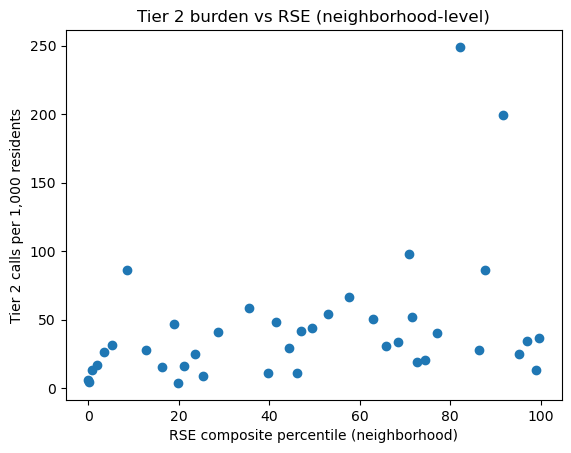

In [77]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(percapitaburden["rse_pct"], percapitaburden["tier2_rate_per_1000"])
plt.xlabel("RSE composite percentile (neighborhood)")
plt.ylabel("Tier 2 calls per 1,000 residents")
plt.title("Tier 2 burden vs RSE (neighborhood-level)")
plt.show()


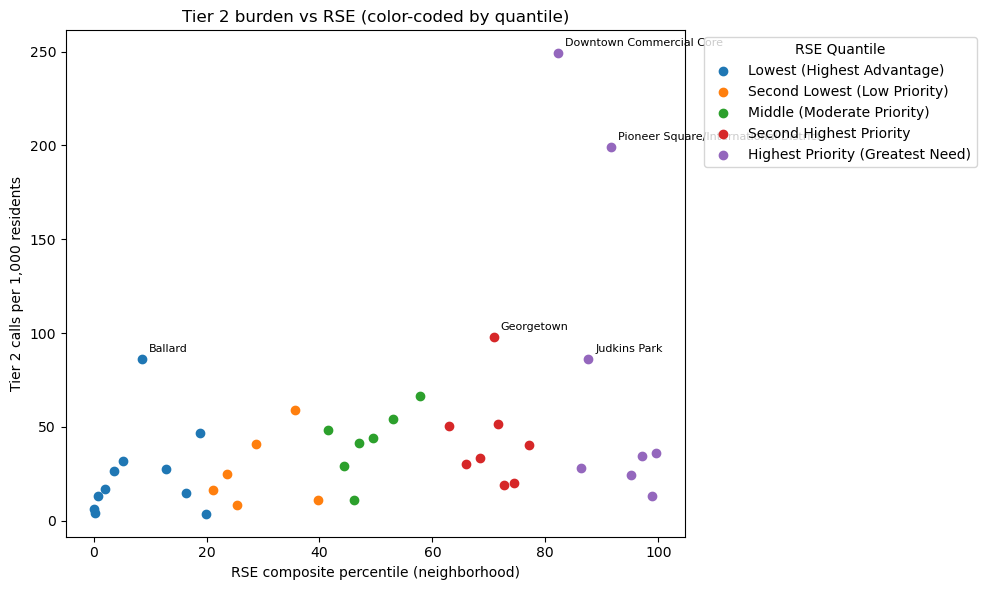

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

nbhd_col = "Community Reporting Area Name"
rse_pct_col = "rse_pct"                 # change if your column name differs
rate_col = "tier2_rate_per_1000"
q_col = "rse_q"                         # change if your column name differs

# --- 1) Define "outliers" to annotate (top N by rate, tweak as you like) ---
top_n = 5
outliers = percapitaburden.nlargest(top_n, rate_col)[[nbhd_col, rse_pct_col, rate_col]]

# --- 2) Plot: color-coded by quantile label ---
plt.figure(figsize=(10, 6))

# Consistent order if your labels match these; otherwise it will plot whatever exists
order = ["Lowest (Highest Advantage)", "Second Lowest (Low Priority)", "Middle (Moderate Priority)", "Second Highest Priority", "Highest Priority (Greatest Need)"]

cats = [c for c in order if c in percapitaburden[q_col].astype(str).unique()] + \
       [c for c in percapitaburden[q_col].astype(str).unique() if c not in order]

for cat in cats:
    sub = percapitaburden[percapitaburden[q_col].astype(str) == cat]
    plt.scatter(sub[rse_pct_col], sub[rate_col], label=cat)

plt.xlabel("RSE composite percentile (neighborhood)")
plt.ylabel("Tier 2 calls per 1,000 residents")
plt.title("Tier 2 burden vs RSE (color-coded by quantile)")

# --- 3) Annotate outliers with neighborhood name ---
for _, row in outliers.iterrows():
    plt.annotate(
        str(row[nbhd_col]),
        (row[rse_pct_col], row[rate_col]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

plt.legend(title="RSE Quantile", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


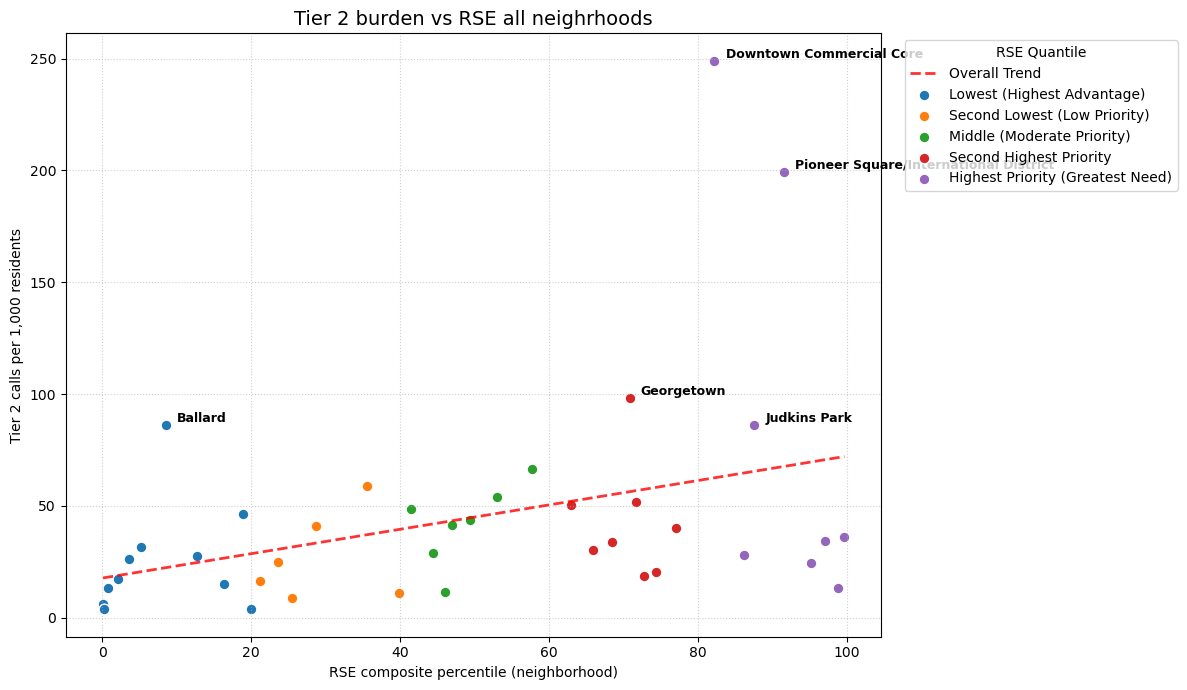

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Setup and Outliers ---
top_n = 5
outliers = percapitaburden.nlargest(top_n, rate_col)[[nbhd_col, rse_pct_col, rate_col]]

plt.figure(figsize=(12, 7)) # Slightly wider for the legend

# --- 2) Calculate Global Trend Line (New) ---
# We use all data points regardless of category for the "Overall" trend
x = percapitaburden[rse_pct_col]
y = percapitaburden[rate_col]

# Calculate linear regression coefficients (slope and intercept)
z = np.polyfit(x, y, 1) 
p = np.poly1d(z)

# Plot the trend line
plt.plot(x.sort_values(), p(x.sort_values()), "r--", alpha=0.8, label="Overall Trend", linewidth=2)

# --- 3) Plot: color-coded by quantile label ---
order = ["Lowest (Highest Advantage)", "Second Lowest (Low Priority)", "Middle (Moderate Priority)", "Second Highest Priority", "Highest Priority (Greatest Need)"]
cats = [c for c in order if c in percapitaburden[q_col].astype(str).unique()] + \
       [c for c in percapitaburden[q_col].astype(str).unique() if c not in order]

for cat in cats:
    sub = percapitaburden[percapitaburden[q_col].astype(str) == cat]
    plt.scatter(sub[rse_pct_col], sub[rate_col], label=cat, edgecolors='white', s=60)

# --- 4) Annotate outliers with neighborhood name ---
for _, row in outliers.iterrows():
    plt.annotate(
        str(row[nbhd_col]),
        (row[rse_pct_col], row[rate_col]),
        textcoords="offset points",
        xytext=(8, 2),
        fontsize=9,
        fontweight='bold'
    )

# Formatting
plt.xlabel("RSE composite percentile (neighborhood)")
plt.ylabel("Tier 2 calls per 1,000 residents")
plt.title(f"Tier 2 burden vs RSE all neighrhoods", fontsize=14)
plt.legend(title="RSE Quantile", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [83]:
import pandas as pd

df = df_call_rse_joined_tier2.copy()

nbhd_col = "Community Reporting Area Name"
pop_col  = "pop_total"
rse_q_col = "Composite score Quantile Label"
rse_pct_col = "composite_score_percentile_nbhd"

# neighborhood-level Tier2 burden table
g = (df.groupby(nbhd_col, dropna=False)
       .agg(
           tier2_events=("cad_event_number", "count"),
           pop_total=(pop_col, "first"),
           rse_q=(rse_q_col, "first"),
           rse_pct=(rse_pct_col, "first"),
           n_geoids=("n_geoids", "first"),
       )
       .reset_index())

g["tier2_rate_per_1000"] = 1000 * g["tier2_events"] / g["pop_total"]

outliers = ["Downtown Commercial Core", "Pioneer Square", "Judkins Park", "Georgetown", "Ballard"]
print(g[g[nbhd_col].isin(outliers)].sort_values("tier2_rate_per_1000", ascending=False))


   Community Reporting Area Name  tier2_events  pop_total  \
9       Downtown Commercial Core          1448     5813.0   
14                    Georgetown           143     1457.0   
18                  Judkins Park           369     4284.0   
1                        Ballard           963    11191.0   

                               rse_q    rse_pct  n_geoids  tier2_rate_per_1000  
9   Highest Priority (Greatest Need)  82.213312       2.0           249.096852  
14           Second Highest Priority  70.841738       1.0            98.146877  
18  Highest Priority (Greatest Need)  87.592857       1.0            86.134454  
1         Lowest (Highest Advantage)   8.540365       3.0            86.051291  


In [93]:
exclude = ["Downtown Commercial Core", "Pioneer Square/International District", "Georgetown"]  # start conservative; adjust if you want

percapitaburden2 = percapitaburden[~g[nbhd_col].isin(exclude)].copy()

q = (percapitaburden2.groupby("rse_q")
       .agg(
           pop_total=("pop_total", "sum"),
           tier2_events=("tier2_events", "sum"),
       ))

q["pop_weighted_rate_per_1000"] = 1000 * q["tier2_events"] / q["pop_total"]
print(q.sort_index())


                                  pop_total  tier2_events  \
rse_q                                                       
Lowest (Highest Advantage)         178557.0          4072   
Second Lowest (Low Priority)       136503.0          4077   
Middle (Moderate Priority)          95246.0          4125   
Second Highest Priority            106224.0          3570   
Highest Priority (Greatest Need)    53918.0          1634   

                                  pop_weighted_rate_per_1000  
rse_q                                                         
Lowest (Highest Advantage)                         22.805043  
Second Lowest (Low Priority)                       29.867475  
Middle (Moderate Priority)                         43.308905  
Second Highest Priority                            33.608224  
Highest Priority (Greatest Need)                   30.305278  


/var/folders/3_/1rhf9qv926gdc06htyqtwt580000gn/T/ipykernel_68531/1901905721.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  percapitaburden2 = percapitaburden[~g[nbhd_col].isin(exclude)].copy()
/var/folders/3_/1rhf9qv926gdc06htyqtwt580000gn/T/ipykernel_68531/1901905721.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q = (percapitaburden2.groupby("rse_q")


In [94]:
print(percapitaburden2)

         Community Reporting Area Name  tier2_events  population    rse_pct  \
0                         Alki/Admiral           373     11802.0   5.254096   
1                              Ballard           963     11191.0   8.540365   
2                             Belltown           580     11948.0  41.518670   
3                Broadview/Bitter Lake           689     15715.0  49.402273   
4                         Capitol Hill          1589     27064.0  35.602893   
5                     Cascade/Eastlake          1192     29182.0  28.762237   
6               Cedar Park/Meadowbrook           803     14861.0  53.072268   
7             Central Area/Squire Park           579     19945.0  44.369558   
8                        Columbia City           448     22074.0  74.401043   
10                       Duwamish/SODO           186      3611.0  71.651006   
11                  Fauntleroy/Seaview            55     14941.0  19.899641   
12                          First Hill          1020

In [96]:

rho, p = spearmanr(percapitaburden2["rse_pct"], percapitaburden2["tier2_rate_per_1000"])
print("Spearman rho (RSE percentile vs Tier2 rate):", rho)
print("p-value:", p)

Spearman rho (RSE percentile vs Tier2 rate): 0.3326220957799905
p-value: 0.04427264967317401


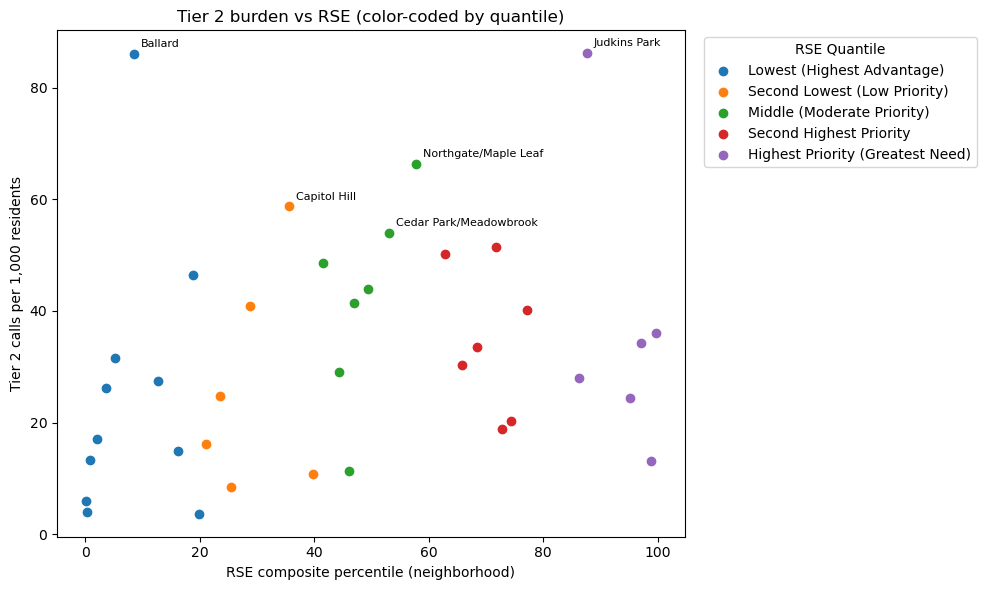

In [97]:

nbhd_col = "Community Reporting Area Name"
rse_pct_col = "rse_pct"                 # change if your column name differs
rate_col = "tier2_rate_per_1000"
q_col = "rse_q"                         # change if your column name differs

# --- 1) Define "outliers" to annotate (top N by rate, tweak as you like) ---
top_n = 5
outliers = percapitaburden2.nlargest(top_n, rate_col)[[nbhd_col, rse_pct_col, rate_col]]

# --- 2) Plot: color-coded by quantile label ---
plt.figure(figsize=(10, 6))

# Consistent order if your labels match these; otherwise it will plot whatever exists
order = ["Lowest (Highest Advantage)", "Second Lowest (Low Priority)", "Middle (Moderate Priority)", "Second Highest Priority", "Highest Priority (Greatest Need)"]

cats = [c for c in order if c in percapitaburden2[q_col].astype(str).unique()] + \
       [c for c in percapitaburden2[q_col].astype(str).unique() if c not in order]

for cat in cats:
    sub = percapitaburden2[percapitaburden2[q_col].astype(str) == cat]
    plt.scatter(sub[rse_pct_col], sub[rate_col], label=cat)

plt.xlabel("RSE composite percentile (neighborhood)")
plt.ylabel("Tier 2 calls per 1,000 residents")
plt.title("Tier 2 burden vs RSE (color-coded by quantile)")

# --- 3) Annotate outliers with neighborhood name ---
for _, row in outliers.iterrows():
    plt.annotate(
        str(row[nbhd_col]),
        (row[rse_pct_col], row[rate_col]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

plt.legend(title="RSE Quantile", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


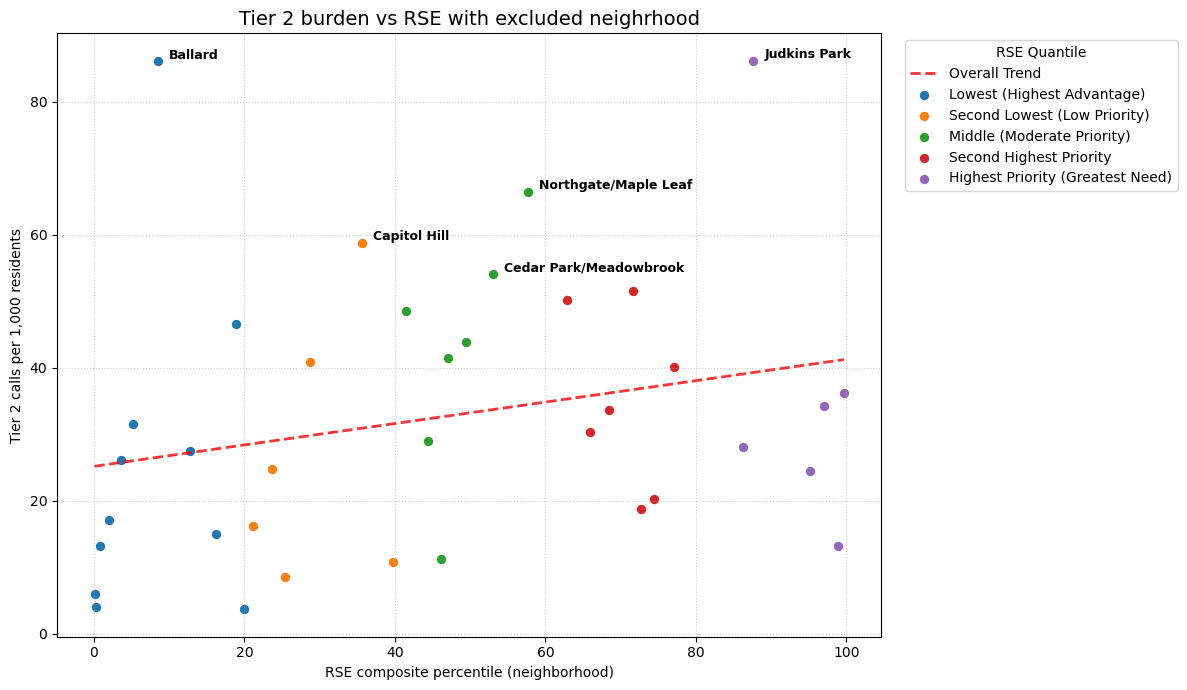

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Setup and Outliers ---
top_n = 5
outliers = percapitaburden2.nlargest(top_n, rate_col)[[nbhd_col, rse_pct_col, rate_col]]

plt.figure(figsize=(12, 7)) # Slightly wider for the legend

# --- 2) Calculate Global Trend Line (New) ---
# We use all data points regardless of category for the "Overall" trend
x = percapitaburden2[rse_pct_col]
y = percapitaburden2[rate_col]

# Calculate linear regression coefficients (slope and intercept)
z = np.polyfit(x, y, 1) 
p = np.poly1d(z)

# Plot the trend line
plt.plot(x.sort_values(), p(x.sort_values()), "r--", alpha=0.8, label="Overall Trend", linewidth=2)

# --- 3) Plot: color-coded by quantile label ---
order = ["Lowest (Highest Advantage)", "Second Lowest (Low Priority)", "Middle (Moderate Priority)", "Second Highest Priority", "Highest Priority (Greatest Need)"]
cats = [c for c in order if c in percapitaburden2[q_col].astype(str).unique()] + \
       [c for c in percapitaburden2[q_col].astype(str).unique() if c not in order]

for cat in cats:
    sub = percapitaburden2[percapitaburden2[q_col].astype(str) == cat]
    plt.scatter(sub[rse_pct_col], sub[rate_col], label=cat, edgecolors='white', s=60)

# --- 4) Annotate outliers with neighborhood name ---
for _, row in outliers.iterrows():
    plt.annotate(
        str(row[nbhd_col]),
        (row[rse_pct_col], row[rate_col]),
        textcoords="offset points",
        xytext=(8, 2),
        fontsize=9,
        fontweight='bold'
    )

# Formatting
plt.xlabel("RSE composite percentile (neighborhood)")
plt.ylabel("Tier 2 calls per 1,000 residents")
plt.title(f"Tier 2 burden vs RSE with excluded neighrhood", fontsize=14)
plt.legend(title="RSE Quantile", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Answer 2: Does Tier 2 concentration track more with the Race/ELL/Origins subindex, Socioeconomic disadvantage, or Health disadvantage?

In [103]:
print_schema(percapitaburden)

Schema for df  |  rows=40 cols=9
  - Community Reporting Area Name: object
  - tier2_events: int64
  - population: float64
  - rse_pct: float64
  - rse_q: category
  - n_geoids: float64
  - pop_total: float64
  - composite_score_percentile_nbhd: float64
  - tier2_rate_per_1000: float64


In [108]:
print_schema(df_call_rse_joined_tier2)

Schema for df  |  rows=20,867 cols=77
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [109]:
nbhd_key = "Community Reporting Area Name"

# These exist in your call-level df
subindex_cols = [
    "Race, ELL, and origins score",
    "Socioeconomic disadvantage score",
    "Health disadvantage score",
    "Composite score",
]

'''
def clean_key(s):
    # Standardize strings so joins don’t fail due to casing/whitespace
    return (s.astype(str)
              .str.strip()
              .str.replace(r"\s+", " ", regex=True)
              .str.upper())
'''
# Choose the call-level df that has the subindex columns
df_calllevel = df_call_rse_joined_tier2.copy()  # or df_call_rse_joined_tier2

# Clean the join key in the call-level df
# df_calllevel[nbhd_key] = clean_key(df_calllevel[nbhd_key])

# Diagnostic: confirm each subindex is constant within neighborhood
nunique = df_calllevel.groupby(nbhd_key)[subindex_cols].nunique(dropna=False)
violations = (nunique > 1).sum().sort_values(ascending=False)
print("Neighborhoods with >1 unique value per column (should ideally be 0):")
display(violations)

# Build a 1-row-per-neighborhood table.
# If values are constant, "first" is safe. If not, we can mean-aggregate.
df_nbhd_unique = (df_calllevel
    .groupby(nbhd_key, as_index=False)
    .agg({c: "first" for c in subindex_cols})
)

print("df_nbhd_unique rows:", len(df_nbhd_unique))


Neighborhoods with >1 unique value per column (should ideally be 0):


Race, ELL, and origins score        0
Socioeconomic disadvantage score    0
Health disadvantage score           0
Composite score                     0
dtype: int64

df_nbhd_unique rows: 40


In [111]:
percapitaburden2 = percapitaburden.copy()
#percapitaburden2[nbhd_key] = clean_key(percapitaburden2[nbhd_key])

plot_df = percapitaburden2.merge(
    df_nbhd_unique[[nbhd_key] + subindex_cols],
    on=nbhd_key,
    how="left",
    validate="one_to_one"  # should now succeed
)

print("Rows after merge:", len(plot_df))
print("Missing any subindex:",
      plot_df[subindex_cols].isna().any(axis=1).sum())

print_schema(plot_df)


Rows after merge: 40
Missing any subindex: 0
Schema for df  |  rows=40 cols=13
  - Community Reporting Area Name: object
  - tier2_events: int64
  - population: float64
  - rse_pct: float64
  - rse_q: category
  - n_geoids: float64
  - pop_total: float64
  - composite_score_percentile_nbhd: float64
  - tier2_rate_per_1000: float64
  - Race, ELL, and origins score: float64
  - Socioeconomic disadvantage score: float64
  - Health disadvantage score: float64
  - Composite score: float64


Race/ELL/Origins
Pearson r=0.322 | Spearman ρ=0.398 | R²=0.104 | N=40
Socioeconomic disadvantage
Pearson r=0.414 | Spearman ρ=0.442 | R²=0.172 | N=40
Health disadvantage
Pearson r=0.316 | Spearman ρ=0.317 | R²=0.100 | N=40


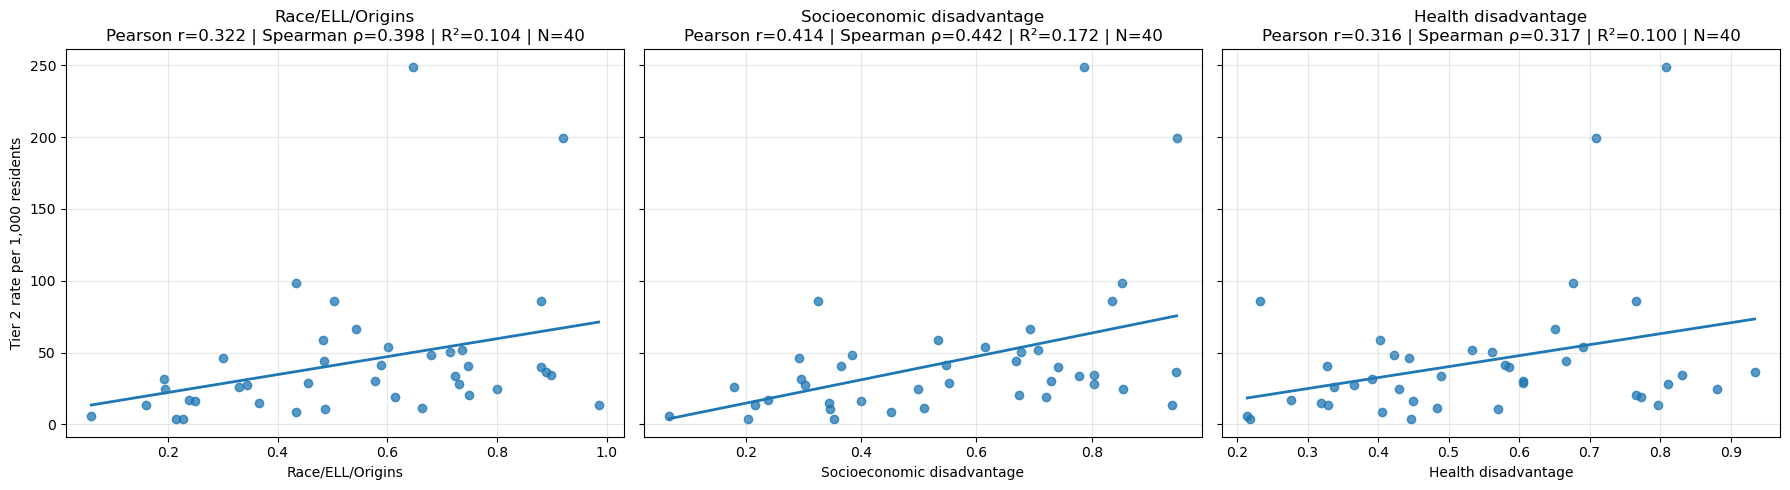

In [114]:

import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

y_col = "tier2_rate_per_1000"
x_map = {
    "Race/ELL/Origins": "Race, ELL, and origins score",
    "Socioeconomic disadvantage": "Socioeconomic disadvantage score",
    "Health disadvantage": "Health disadvantage score",
}

def linear_fit_r2(x, y):
    a, b = np.polyfit(x, y, 1)
    yhat = a*x + b
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return a, b, r2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, xcol) in zip(axes, x_map.items()):
    d = plot_df[[xcol, y_col]].dropna()
    x = d[xcol].to_numpy(float)
    y = d[y_col].to_numpy(float)

    ax.scatter(x, y, alpha=0.75)

    # Fit and overlay trend line
    a, b, r2 = linear_fit_r2(x, y)
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, a*xx + b, linewidth=2)

    # Correlations (helpful context for “tightest linear clustering”)
    pr, _ = pearsonr(x, y)
    sr, _ = spearmanr(x, y)

    ax.set_title(f"{label}\nPearson r={pr:.3f} | Spearman ρ={sr:.3f} | R²={r2:.3f} | N={len(d)}")
    print(f"{label}\nPearson r={pr:.3f} | Spearman ρ={sr:.3f} | R²={r2:.3f} | N={len(d)}")
    ax.set_xlabel(label)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Tier 2 rate per 1,000 residents")
plt.tight_layout()
plt.show()


Equity of access: Does the share of Tier 2 events with CARE involvement (CARE-only + co-response) vary by RSE quintile/decile?

In [138]:
import numpy as np
import pandas as pd

df = df_call_rse_joined_tier2.copy()


# Collapse to one row per CAD event (avoid double-counting)

eventtime_dfevents = (df
          .sort_values("cad_event_original_time_queued")
          .drop_duplicates(subset=["cad_event_number"])
          .copy())

print("Tier2 rows (call-level):", len(df))
print("Tier2 rows (event-level):", len(events))
#no change in length so good.


# Normalize response category text for robust matching

events["resp_cat"] = (events["cad_event_response_category"]
                      .astype(str)
                      .str.strip()
                      .str.upper())

# Quick sanity check: what categories do we actually have?
print("Top response categories:")
display(events["resp_cat"].value_counts(dropna=False).head(20))
display(events["cad_event_response_category"].value_counts(dropna=False).head(20))
# Drop one column
events = events.drop(columns=['resp_cat'])



Tier2 rows (call-level): 20867


NameError: name 'events' is not defined

In [124]:
nbhd_key = "Community Reporting Area Name"

# ============================================================
# Step 1) Define CARE involvement from cad_event_response_category
# CARE involvement = CARE-only OR SPD/CARE Co-Response
# ============================================================

resp = (events["cad_event_response_category"]
        .astype(str)
        .str.strip()
        .str.upper())

# IMPORTANT: adjust these strings if your value_counts show variants
CARE_ONLY = {"CARE"}
CO_RESP   = {"SPD/CARE CO-RESPONSE"}

events2 = events.copy()
events2["care_involved"] = resp.isin(CARE_ONLY | CO_RESP)

# Quick sanity check
print("Overall CARE-involved share among Tier2 events:", events2["care_involved"].mean())
print("Counts by CARE involved:")
display(events2["care_involved"].value_counts(dropna=False))

print_schema(events2)

Overall CARE-involved share among Tier2 events: 0.1958594910624431
Counts by CARE involved:


care_involved
False    16780
True      4087
Name: count, dtype: int64

Schema for df  |  rows=20,867 cols=78
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [245]:
print_schema(events2)
events2_sensitive = events2.copy()
# Your list of target strings
sensitive_tier2_list = ["CCR ONLY - COMMUNITY PRESENCE", "CCR ONLY - ASSIST THE PUBLIC", "SERVICE - WELFARE CHECK", "CCR ONLY - CARE CRISIS RESPONSE", "CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD", "DOWN - CHECK FOR DOWN PERSON", "CRISIS COMPLAINT - PICK-UP OR TRANSPORT", "OVERDOSE", "CHILD - CHILD ENDANGERMENT", "PERSON IN BEHAVIORAL/EMOTIONAL CRISIS", "SUICIDE - CRITICAL", "SUICIDE - SUICIDAL PERSON AND ATTEMPTS", "CCR ONLY - SUICIDAL PERSON", "CCR ONLY - NON-OD SUD CALL", "CCR ONLY - OVERDOSE", "DETOX - REQUEST FOR"]

# Filter the DataFrame
events2_sensitive = events2_sensitive[events2_sensitive['final_call_type'].isin(sensitive_tier2_list)]
print_schema(events2_sensitive)

Schema for df  |  rows=20,867 cols=78
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [164]:
nhbd_pop_df = events2[["Community Reporting Area Name","pop_total"]].drop_duplicates().sort_values("pop_total").reset_index(drop=True)
print(nhbd_pop_df)

            Community Reporting Area Name  pop_total
0                              Georgetown     1457.0
1                           Duwamish/SODO     3611.0
2                              South Park     3736.0
3                            Judkins Park     4284.0
4                            Madison Park     5530.0
5                Downtown Commercial Core     5813.0
6                          North Delridge     6257.0
7   Pioneer Square/International District     6309.0
8                           Highland Park     6600.0
9                 Mt. Baker/North Rainier     6747.0
10                            Miller Park     7764.0
11                             High Point     8657.0
12                            Seward Park     9687.0
13                   Montlake/Portage Bay     9742.0
14                         Madrona/Leschi    10910.0
15                                Ballard    11191.0
16                 Laurelhurst/Sand Point    11420.0
17                           Alki/Admiral    1

In [246]:
nhbd_pop_df_sens = events2_sensitive[["Community Reporting Area Name","pop_total"]].drop_duplicates().sort_values("pop_total").reset_index(drop=True)
print(nhbd_pop_df_sens)

            Community Reporting Area Name  pop_total
0                              Georgetown     1457.0
1                           Duwamish/SODO     3611.0
2                              South Park     3736.0
3                            Judkins Park     4284.0
4                            Madison Park     5530.0
5                Downtown Commercial Core     5813.0
6                          North Delridge     6257.0
7   Pioneer Square/International District     6309.0
8                           Highland Park     6600.0
9                 Mt. Baker/North Rainier     6747.0
10                            Miller Park     7764.0
11                             High Point     8657.0
12                            Seward Park     9687.0
13                   Montlake/Portage Bay     9742.0
14                         Madrona/Leschi    10910.0
15                                Ballard    11191.0
16                 Laurelhurst/Sand Point    11420.0
17                           Alki/Admiral    1

In [126]:
# ============================================================
# Per-neighborhood Tier2 denominator and CARE-involved numerator
# ============================================================

nbhd_share = (events2.groupby(nbhd_key, dropna=False)
              .agg(
                  n_tier2_events=("cad_event_number", "count"),
                  n_care_involved=("care_involved", "sum"),
              )
              .reset_index())

nbhd_share["share_care_involved"] = nbhd_share["n_care_involved"] / nbhd_share["n_tier2_events"]
print_schema(nbhd_share)
# Optional quick look at extremes
display(nbhd_share.sort_values("share_care_involved", ascending=False).head(10))

Schema for df  |  rows=41 cols=4
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64


,Community Reporting Area Name,n_tier2_events,n_care_involved,share_care_involved
34,Seward Park,109,47,0.431193
37,University District,844,337,0.399289
0,Alki/Admiral,373,148,0.396783
1,Ballard,963,310,0.321911
9,Downtown Commercial Core,1448,447,0.308702
20,Madison Park,33,10,0.303030
4,Capitol Hill,1589,468,0.294525
10,Duwamish/SODO,186,54,0.290323
13,Fremont,328,91,0.277439
40,NaN,540,142,0.262963


In [247]:

nbhd_share_sens = (events2_sensitive.groupby(nbhd_key, dropna=False)
              .agg(
                  n_tier2_events=("cad_event_number", "count"),
                  n_care_involved=("care_involved", "sum"),
              )
              .reset_index())

nbhd_share_sens["share_care_involved"] = nbhd_share_sens["n_care_involved"] / nbhd_share_sens["n_tier2_events"]
print_schema(nbhd_share_sens)
# Optional quick look at extremes
display(nbhd_share_sens.sort_values("share_care_involved", ascending=False).head(10))

Schema for df  |  rows=41 cols=4
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64


,Community Reporting Area Name,n_tier2_events,n_care_involved,share_care_involved
8,Columbia City,114,107,0.938596
34,Seward Park,48,45,0.937500
37,University District,360,327,0.908333
1,Ballard,327,295,0.902141
20,Madison Park,10,9,0.900000
0,Alki/Admiral,161,144,0.894410
4,Capitol Hill,488,434,0.889344
13,Fremont,98,87,0.887755
38,Wallingford,28,24,0.857143
6,Cedar Park/Meadowbrook,121,102,0.842975


In [127]:
print_schema(percapitaburden)

Schema for df  |  rows=40 cols=9
  - Community Reporting Area Name: object
  - tier2_events: int64
  - population: float64
  - rse_pct: float64
  - rse_q: category
  - n_geoids: float64
  - pop_total: float64
  - composite_score_percentile_nbhd: float64
  - tier2_rate_per_1000: float64


In [128]:

# ============================================================
# Step 3) Attach neighborhood RSE bins (quintile + decile)
# Use composite_score_percentile_nbhd if you have it; else fallback to rse_pct.
# IMPORTANT: define bins on NEIGHBORHOODS, not events.
# ============================================================

# Choose the composite column for binning
if "composite_score_percentile_nbhd" in percapitaburden.columns:
    score_col = "composite_score_percentile_nbhd"
else:
    score_col = "rse_pct"  # fallback if percentile isn't available

nbhd_bins = percapitaburden[[nbhd_key, score_col]].dropna().copy()
print_schema(nbhd_bins)

# Clean keys lightly (avoid whitespace mismatch)
def clean_key(s):
    return (s.astype(str)
              .str.strip()
              .str.replace(r"\s+", " ", regex=True)
              .str.upper())

nbhd_bins[nbhd_key] = clean_key(nbhd_bins[nbhd_key])
nbhd_share[nbhd_key] = clean_key(nbhd_share[nbhd_key])
print_len(nbhd_bins)
print_len(nbhd_bins)

Schema for df  |  rows=40 cols=2
  - Community Reporting Area Name: object
  - composite_score_percentile_nbhd: float64
Schema for df  |  rows=40 cols=2
Schema for df  |  rows=40 cols=2


In [ ]:
# Create bins on neighborhoods
# split the neighborhoods into 5 groups with (roughly) the same number of neighborhoods in each group → quintiles.
# ensures each bin has a similar count of neighborhoods, which is helpful when you want to compare groups fairly.
#score col = composite_score_percentile_nbhd in this case.

nbhd_bins["rse_quintile_nbhd"] = pd.qcut(nbhd_bins[score_col], q=5, labels=False, duplicates="drop") + 1
nbhd_bins["rse_decile_nbhd"]   = pd.qcut(nbhd_bins[score_col], q=10, labels=False, duplicates="drop") + 1

# Merge bins into neighborhood share table
nbhd_share2 = nbhd_share.merge(
    nbhd_bins[[nbhd_key, "rse_quintile_nbhd", "rse_decile_nbhd"]],
    on=nbhd_key,
    how="inner",
    validate="one_to_one"
)

print("Neighborhoods in nbhd_share2:", len(nbhd_share2))
print_schema(nbhd_share2)
# display(nbhd_share2.head())

Neighborhoods in nbhd_share2: 40
Schema for df  |  rows=40 cols=6
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - rse_quintile_nbhd: int64
  - rse_decile_nbhd: int64


In [144]:
# Quintiles
q_codes = pd.qcut(nbhd_bins[score_col], q=5, labels=False, duplicates="drop")  # 0..4
q_labels = [
    "Q1 (Lowest RSE)",
    "Q2",
    "Q3",
    "Q4",
    "Q5 (Highest RSE)",
]
nbhd_bins["rse_quintile_nhbd_score_label"] = q_codes.map(lambda i: q_labels[int(i)] if pd.notna(i) else np.nan)

# Deciles
d_codes = pd.qcut(nbhd_bins[score_col], q=10, labels=False, duplicates="drop")  # 0..9 (maybe fewer if duplicates dropped)
nbhd_bins["rse_decile_nhbd_score_label"] = d_codes.map(lambda i: f"D{int(i)+1} (Lowest RSE)" if int(i)==0
                                            else (f"D{int(i)+1} (Highest RSE)" if int(i)==9 else f"D{int(i)+1}"))
print(nbhd_bins)

            Community Reporting Area Name  composite_score_percentile_nbhd  \
0                            ALKI/ADMIRAL                         5.254096   
1                                 BALLARD                         8.540365   
2                                BELLTOWN                        41.518670   
3                   BROADVIEW/BITTER LAKE                        49.402273   
4                            CAPITOL HILL                        35.602893   
5                        CASCADE/EASTLAKE                        28.762237   
6                  CEDAR PARK/MEADOWBROOK                        53.072268   
7                CENTRAL AREA/SQUIRE PARK                        44.369558   
8                           COLUMBIA CITY                        74.401043   
9                DOWNTOWN COMMERCIAL CORE                        82.213312   
10                          DUWAMISH/SODO                        71.651006   
11                     FAUNTLEROY/SEAVIEW                       

In [145]:
print_schema(nbhd_share2)
mapping_quantile_nhbd_label_df = nbhd_bins[["rse_quintile_nbhd", "rse_quintile_nhbd_score_label"]].drop_duplicates().reset_index(drop=True)
print(mapping_quantile_nhbd_label_df)
mapping_decile_nhbd_label_df = nbhd_bins[["rse_decile_nbhd", "rse_decile_nhbd_score_label"]].drop_duplicates().reset_index(drop=True)
print(mapping_decile_nhbd_label_df)

nbhd_share2 = nbhd_share2.merge(
    mapping_quantile_nhbd_label_df[["rse_quintile_nbhd", "rse_quintile_nhbd_score_label"]],
    on="rse_quintile_nbhd",
    how="left"
)
nbhd_share2 = nbhd_share2.merge(
    mapping_decile_nhbd_label_df[["rse_decile_nbhd", "rse_decile_nhbd_score_label"]],
    on="rse_decile_nbhd",
    how="left"
)
print("after merge")
print(nbhd_share2)



Schema for df  |  rows=40 cols=9
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - rse_quintile_nbhd: int64
  - rse_decile_nbhd: int64
  - rse_quintile_label_x: object
  - rse_quintile_label_y: object
  - rse_decile_label: object
   rse_quintile_nbhd rse_quintile_nhbd_score_label
0                  1               Q1 (Lowest RSE)
1                  3                            Q3
2                  2                            Q2
3                  4                            Q4
4                  5              Q5 (Highest RSE)
   rse_decile_nbhd rse_decile_nhbd_score_label
0                2                          D2
1                5                          D5
2                6                          D6
3                4                          D4
4                8                          D8
5                9                          D9
6                3                          D3
7     

In [147]:


# ============================================================
# Step 4) Summarize by bin: (1) median (unweighted), (2) mean (unweighted), (3) event-weighted share
# ============================================================

def summarize_equity_123(df, bin_col):
    g = (df.groupby(bin_col)
         .agg(
             n_neighborhoods=(nbhd_key, "count"),
             total_tier2_events=("n_tier2_events", "sum"),
             total_care_involved=("n_care_involved", "sum"),

             mean_share_unweighted=("share_care_involved", "mean"),
             median_share_unweighted=("share_care_involved", "median"),

             # denominator context for stability
             min_tier2_events_in_nbhd=("n_tier2_events", "min"),
             median_tier2_events_in_nbhd=("n_tier2_events", "median"),
             max_tier2_events_in_nbhd=("n_tier2_events", "max"),
         )
         .reset_index()
         .sort_values(bin_col))

    g["share_event_weighted"] = g["total_care_involved"] / g["total_tier2_events"]

    # Format shares as percentages for readability
    for c in ["mean_share_unweighted", "median_share_unweighted", "share_event_weighted"]:
        g[c] = 100 * g[c]

    return g

q_equity = summarize_equity_123(nbhd_share2, "rse_quintile_nhbd_score_label")
d_equity = summarize_equity_123(nbhd_share2, "rse_decile_nhbd_score_label")

print("By quintile:")
display(q_equity)

print("By decile:")
display(d_equity)



By quintile:


,rse_quintile_nhbd_score_label,n_neighborhoods,total_tier2_events,total_care_involved,mean_share_unweighted,median_share_unweighted,min_tier2_events_in_nbhd,median_tier2_events_in_nbhd,max_tier2_events_in_nbhd,share_event_weighted
0,Q1 (Lowest RSE),8,2967,696,20.463409,19.738618,33,313.5,963,23.458038
1,Q2,8,5064,972,16.853058,15.928157,55,508.0,1589,19.194313
2,Q3,8,4243,513,14.902102,11.025346,109,579.5,1085,12.090502
3,Q4,8,3713,835,23.086962,25.119909,143,345.0,1020,22.488554
4,Q5 (Highest RSE),8,4340,929,13.929206,10.673927,135,290.5,1448,21.405530


By decile:


,rse_decile_nhbd_score_label,n_neighborhoods,total_tier2_events,total_care_involved,mean_share_unweighted,median_share_unweighted,min_tier2_events_in_nbhd,median_tier2_events_in_nbhd,max_tier2_events_in_nbhd,share_event_weighted
0,D1 (Lowest RSE),4,582,118,17.350561,18.267556,33,110.5,328,20.274914
1,D10 (Highest RSE),4,1080,127,10.161917,9.700781,135,205.0,535,11.759259
2,D2,4,2385,578,23.576257,21.962201,299,561.5,963,24.234801
3,D3,4,1543,163,11.560152,11.813329,55,399.5,689,10.563837
4,D4,4,3521,809,22.145965,22.728438,162,885.0,1589,22.976427
5,D5,4,1386,157,17.549082,10.343366,109,348.5,580,11.327561
6,D6,4,2857,356,12.255123,11.618856,280,746.0,1085,12.460623
7,D7,4,2197,488,21.707467,18.989695,143,517.0,1020,22.212107
8,D8,4,1516,347,24.466456,25.119909,186,345.0,640,22.889182
9,D9,4,3260,802,17.696495,17.255204,185,813.5,1448,24.601227


In [154]:
pip install tabulate


Note: you may need to restart the kernel to use updated packages.


In [ ]:
print_schema(nbhd_bins)
nhbd_quantile_label_map = nbhd_bins[["Community Reporting Area Name","rse_quintile_nhbd_score_label"]].drop_duplicates().sort_values("rse_quintile_nhbd_score_label").reset_index(drop=True)
# Fixed: Added double brackets for multiple columns

print_schema(nhbd_quantile_label_map)

# 1. Ensure the mapping is clean
nhbd_quantile_label_map = (
    nbhd_bins[["rse_quintile_nhbd_score_label", "Community Reporting Area Name"]]
    .drop_duplicates()
    .sort_values("rse_quintile_nhbd_score_label")
)

# 2. Group them so you see all neighborhoods per label in one row
neighborhood_list_by_label = (
    nhbd_quantile_label_map.groupby("rse_quintile_nhbd_score_label")["Community Reporting Area Name"]
    .apply(lambda x: ", ".join(x))
    .reset_index()
)

# Print in Tab-Separated format
print(neighborhood_list_by_label.to_csv(sep='\t', index=False))

Schema for df  |  rows=40 cols=8
  - Community Reporting Area Name: object
  - composite_score_percentile_nbhd: float64
  - rse_quintile_nbhd: int64
  - rse_decile_nbhd: int64
  - rse_quintile_label: object
  - rse_decile_label: object
  - rse_quintile_nhbd_score_label: object
  - rse_decile_nhbd_score_label: object
Schema for df  |  rows=40 cols=2
  - Community Reporting Area Name: object
  - rse_quintile_nhbd_score_label: object
rse_quintile_nhbd_score_label	Community Reporting Area Name
Q1 (Lowest RSE)	ALKI/ADMIRAL, RAVENNA/BRYANT, MONTLAKE/PORTAGE BAY, MAGNOLIA, MADISON PARK, FREMONT, LAURELHURST/SAND POINT, BALLARD
Q2	MILLER PARK, QUEEN ANNE, CAPITOL HILL, WALLINGFORD, GREENWOOD/PHINNEY RIDGE, WEST SEATTLE JUNCTION/GENESEE HILL, FAUNTLEROY/SEAVIEW, CASCADE/EASTLAKE
Q3	CENTRAL AREA/SQUIRE PARK, SEWARD PARK, NORTHGATE/MAPLE LEAF, MADRONA/LESCHI, BROADVIEW/BITTER LAKE, CEDAR PARK/MEADOWBROOK, BELLTOWN, MT. BAKER/NORTH RAINIER
Q4	UNIVERSITY DISTRICT, ROXHILL/WESTWOOD, COLUMBIA CITY, G

In [162]:
print_schema(nbhd_share2)
nhbd_careshare = nbhd_share2[["Community Reporting Area Name","n_tier2_events","n_care_involved","share_care_involved"]].drop_duplicates().sort_values("n_tier2_events").reset_index(drop=True)
print(nhbd_careshare.to_csv(sep='\t', index=False))


Schema for df  |  rows=40 cols=11
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - rse_quintile_nbhd: int64
  - rse_decile_nbhd: int64
  - rse_quintile_label_x: object
  - rse_quintile_label_y: object
  - rse_decile_label: object
  - rse_quintile_nhbd_score_label: object
  - rse_decile_nhbd_score_label: object
Community Reporting Area Name	n_tier2_events	n_care_involved	share_care_involved
MADISON PARK	33	10	0.30303030303030304
MONTLAKE/PORTAGE BAY	39	1	0.02564102564102564
FAUNTLEROY/SEAVIEW	55	10	0.18181818181818182
SEWARD PARK	109	47	0.43119266055045874
MADRONA/LESCHI	118	12	0.1016949152542373
SOUTH PARK	135	9	0.06666666666666667
GEORGETOWN	143	37	0.25874125874125875
WALLINGFORD	162	33	0.2037037037037037
MAGNOLIA	182	16	0.08791208791208792
HIGHLAND PARK	185	10	0.05405405405405406
DUWAMISH/SODO	186	54	0.2903225806451613
NORTH DELRIDGE	190	23	0.12105263157894737
SOUTH BEACON HILL/NEWHOLLY	198	16	0.080808

In [ ]:
print_schema(nhbd_careshare)
nhbd_pop_df["Community Reporting Area Name"] = clean_key(nhbd_pop_df["Community Reporting Area Name"])
nhbd_careshare = nhbd_careshare.merge(
    nhbd_pop_df[["Community Reporting Area Name", "pop_total"]],
    on="Community Reporting Area Name",
    how="left"
)
print(nhbd_careshare)

Schema for df  |  rows=40 cols=5
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - pop_total: float64
            Community Reporting Area Name  n_tier2_events  n_care_involved  \
0                            MADISON PARK              33               10   
1                    MONTLAKE/PORTAGE BAY              39                1   
2                      FAUNTLEROY/SEAVIEW              55               10   
3                             SEWARD PARK             109               47   
4                          MADRONA/LESCHI             118               12   
5                              SOUTH PARK             135                9   
6                              GEORGETOWN             143               37   
7                             WALLINGFORD             162               33   
8                                MAGNOLIA             182               16   
9                           HIGHLAND

In [179]:
# Drop the specific redundant columns
nhbd_careshare = nhbd_careshare.drop(columns=['pop_total_x', 'pop_total_y'])

# To verify the change
print(nhbd_careshare.columns)

Index(['Community Reporting Area Name', 'n_tier2_events', 'n_care_involved',
       'share_care_involved'],
      dtype='object')


In [183]:
print_schema(nhbd_careshare)
print_schema(nhbd_pop_df)
nhbd_careshare = nhbd_careshare.merge(
    nhbd_pop_df[["Community Reporting Area Name", "pop_total"]],
    on="Community Reporting Area Name",
    how="left"
)
print_schema(nhbd_careshare)

Schema for df  |  rows=40 cols=4
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
Schema for df  |  rows=41 cols=2
  - Community Reporting Area Name: object
  - pop_total: float64
Schema for df  |  rows=40 cols=5
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - pop_total: float64


In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Expects a dataframe like your last table, with columns:
#   - "Community Reporting Area Name"
#   - "n_tier2_events"
#   - "share_care_involved"   (0..1)
#   - "Population"
# If your df is named differently, set DF below.
# ------------------------------------------------------------

DF = nhbd_careshare  # <-- change if your dataframe has a different name

name_col = "Community Reporting Area Name"
x_col = "n_tier2_events"
y_col = "share_care_involved"
pop_col = "pop_total"

dfp = DF[[name_col, x_col, y_col, pop_col]].dropna().copy()

# ------------------------------------------------------------
# Choose thresholds for "high vs low"
#   - x_split: Tier2 event count threshold
#   - y_split: CARE-share threshold (0..1)
# Defaults:
#   x_split = median Tier2 events
#   y_split = median CARE share
# You can override manually if you want (e.g., x_split=600, y_split=0.15)
# ------------------------------------------------------------
x_split = dfp[x_col].median()
y_split = dfp[y_col].median()

# ------------------------------------------------------------
# Bubble sizes based on population
# - Use sqrt(pop) so huge populations don't completely dominate the plot
# - Scale to a reasonable point area range
# ------------------------------------------------------------
pop = dfp[pop_col].to_numpy(float)
size = np.sqrt(pop)
# scale sizes into roughly [40, 1200] (tweak if you want)
size = 40 + (size - size.min()) / (size.max() - size.min()) * (1200 - 40)

# ------------------------------------------------------------
# Plot quadrant scatter (bubble plot)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(dfp[x_col], dfp[y_col], s=size, alpha=0.6)

# Quadrant lines
ax.axvline(x_split, linewidth=2)
ax.axhline(y_split, linewidth=2)

# Axes labels
ax.set_xlabel("Tier 2 events (count)")
ax.set_ylabel("CARE involvement share (CARE-only + co-response)")
ax.set_title("Neighborhood quadrant: Tier 2 volume vs CARE involvement share\n(bubble size ~ population)")

ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Optional: annotate ONLY the "high Tier2 + low CARE share" quadrant
# (this is the quadrant you specifically care about)
# ------------------------------------------------------------
high_x_low_y = (dfp[x_col] >= x_split) & (dfp[y_col] < y_split)
for _, r in dfp.loc[high_x_low_y].iterrows():
    ax.annotate(
        r[name_col],
        (r[x_col], r[y_col]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9
    )

# Optional: show threshold values in the corner
ax.text(
    0.01, 0.99,
    f"x_split (median Tier2) = {x_split:.0f}\n"
    f"y_split (median share) = {y_split*100:.1f}%",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()


NameError: name 'nhbd_careshare' is not defined

In [194]:
print_schema(nhbd_careshare)
print_schema(nbhd_share2)

Schema for df  |  rows=40 cols=5
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - pop_total: float64
Schema for df  |  rows=40 cols=11
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - rse_quintile_nbhd: int64
  - rse_decile_nbhd: int64
  - rse_quintile_label_x: object
  - rse_quintile_label_y: object
  - rse_decile_label: object
  - rse_quintile_nhbd_score_label: object
  - rse_decile_nhbd_score_label: object


In [237]:
nbhd_qrse_label_map = nbhd_share2[["Community Reporting Area Name","rse_quintile_nhbd_score_label"]].drop_duplicates().reset_index(drop=True)
print_schema(nbhd_qrse_label_map)

nhbd_careshare = nhbd_careshare.merge(
    nbhd_qrse_label_map[["Community Reporting Area Name", "rse_quintile_nhbd_score_label"]],
    on="Community Reporting Area Name",
    how="left"
)
print_schema(nhbd_careshare)


NameError: name 'nbhd_share2' is not defined

In [201]:
print(nhbd_careshare)

            Community Reporting Area Name  n_tier2_events  n_care_involved  \
0                            MADISON PARK              33               10   
1                    MONTLAKE/PORTAGE BAY              39                1   
2                      FAUNTLEROY/SEAVIEW              55               10   
3                             SEWARD PARK             109               47   
4                          MADRONA/LESCHI             118               12   
5                              SOUTH PARK             135                9   
6                              GEORGETOWN             143               37   
7                             WALLINGFORD             162               33   
8                                MAGNOLIA             182               16   
9                           HIGHLAND PARK             185               10   
10                          DUWAMISH/SODO             186               54   
11                         NORTH DELRIDGE             190       

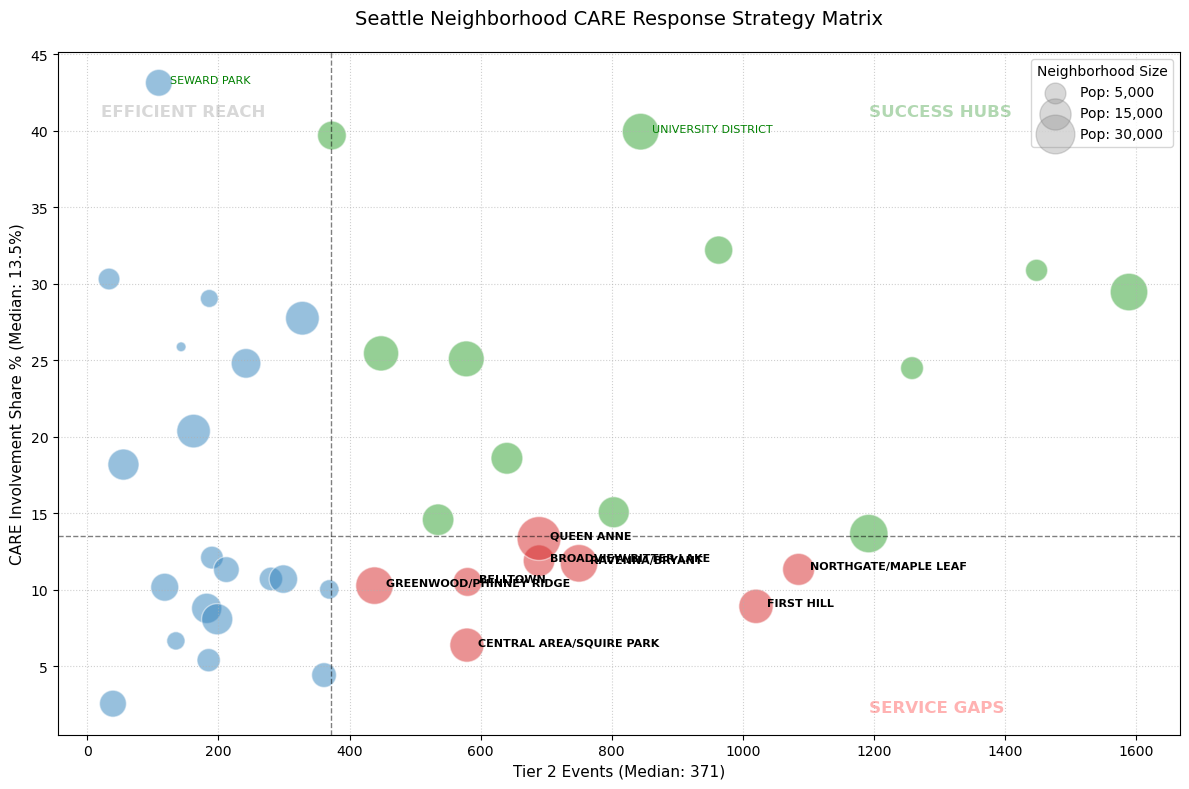

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Data Setup
# ------------------------------------------------------------
DF = nhbd_careshare  # Your existing dataframe

# Column mapping
name_col = "Community Reporting Area Name"
x_col    = "n_tier2_events"
y_col    = "share_care_involved"
pop_col  = "pop_total"

# Clean and prepare
dfp = DF[[name_col, x_col, y_col, pop_col]].dropna().copy()

# Auto-detect if y_col is 0-1 or 0-100 and normalize to 0-100 for plotting
if dfp[y_col].max() <= 1.0:
    dfp[y_col] = dfp[y_col] * 100

# ------------------------------------------------------------
# Thresholds and Calculations
# ------------------------------------------------------------
x_split = dfp[x_col].median()
y_split = dfp[y_col].median()

# Bubble size scaling
pop = dfp[pop_col].to_numpy(float)
size = np.sqrt(pop)
size = 50 + (size - size.min()) / (size.max() - size.min()) * (1000 - 50)

# Color coding based on quadrant
colors = []
for idx, r in dfp.iterrows():
    if r[x_col] >= x_split and r[y_col] < y_split:
        colors.append("#d62728") # Red - Service Gaps
    elif r[x_col] >= x_split and r[y_col] >= y_split:
        colors.append("#2ca02c") # Green - High Integration
    else:
        colors.append("#3182bd") # Blue - Standard/Low Vol

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(dfp[x_col], dfp[y_col], s=size, c=colors, alpha=0.5, edgecolors='w')

# Quadrant lines
ax.axvline(x_split, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y_split, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Quadrant Annotations (Background Labels)
ax.text(dfp[x_col].max()*0.75, dfp[y_col].max()*0.95, 'SUCCESS HUBS', fontsize=12, fontweight='bold', color='green', alpha=0.3)
ax.text(dfp[x_col].max()*0.75, 2, 'SERVICE GAPS', fontsize=12, fontweight='bold', color='red', alpha=0.3)
ax.text(20, dfp[y_col].max()*0.95, 'EFFICIENT REACH', fontsize=12, fontweight='bold', color='gray', alpha=0.3)

# Label the "Service Gap" neighborhoods
high_x_low_y = (dfp[x_col] >= x_split) & (dfp[y_col] < y_split)
for _, r in dfp.loc[high_x_low_y].iterrows():
    ax.annotate(r[name_col], (r[x_col], r[y_col]), xytext=(8, 0), textcoords="offset points", fontsize=8, fontweight='semibold')

# Also label the top 2 highest performers for context
top_performers = dfp.nlargest(2, y_col)
for _, r in top_performers.iterrows():
    ax.annotate(r[name_col], (r[x_col], r[y_col]), xytext=(8, 0), textcoords="offset points", fontsize=8, color='green')

# Formatting
ax.set_xlabel(f"Tier 2 Events (Median: {x_split:.0f})", fontsize=11)
ax.set_ylabel(f"CARE Involvement Share % (Median: {y_split:.1f}%)", fontsize=11)
ax.set_title("Seattle Neighborhood CARE Response Strategy Matrix", fontsize=14, pad=20)

# Custom Legend for Bubble Size (Optional but helpful)
for p in [5000, 15000, 30000]:
    s = 50 + (np.sqrt(p) - np.sqrt(pop.min())) / (np.sqrt(pop.max()) - np.sqrt(pop.min())) * (1000 - 50)
    ax.scatter([], [], c='gray', alpha=0.3, s=s, label=f'Pop: {p:,}')
ax.legend(title="Neighborhood Size", loc='upper right', scatterpoints=1)

ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Q2
GREENWOOD/PHINNEY RIDGE (Q2)
Q3
CENTRAL AREA/SQUIRE PARK (Q3)
Q3
BELLTOWN (Q3)
Q3
BROADVIEW/BITTER LAKE (Q3)
Q2
QUEEN ANNE (Q2)
Q1 (Lowest RSE)
RAVENNA/BRYANT (Q1 (Lowest RSE))
Q4
FIRST HILL (Q4)
Q3
NORTHGATE/MAPLE LEAF (Q3)


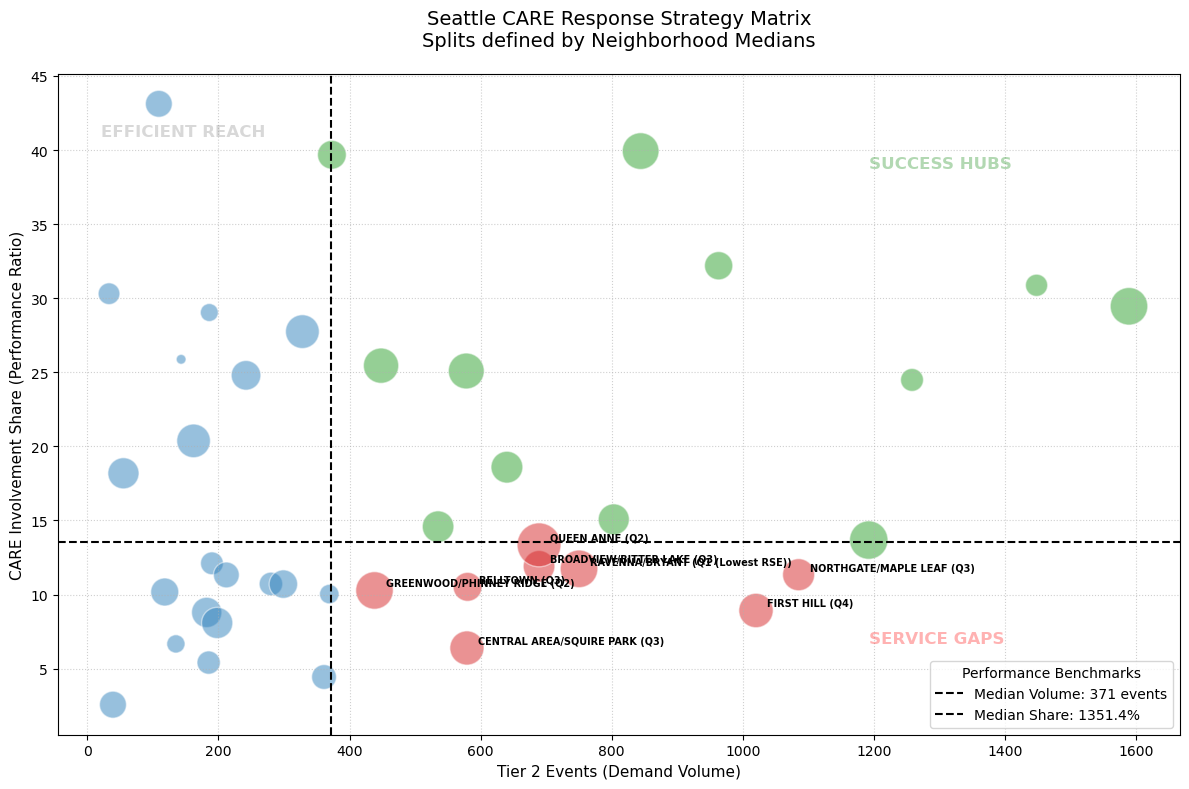

In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Data Setup
# ------------------------------------------------------------
DF = nhbd_careshare  # Your existing dataframe

# Column mapping
name_col = "Community Reporting Area Name"
x_col    = "n_tier2_events"
y_col    = "share_care_involved"
pop_col  = "pop_total"
rse_col  = "rse_quintile_nhbd_score_label"
# Clean and prepare
dfp = DF[[name_col, x_col, y_col, pop_col, rse_col]].dropna().copy()

# Auto-detect if y_col is 0-1 or 0-100 and normalize to 0-100 for plotting
if dfp[y_col].max() <= 1.0:
    dfp[y_col] = dfp[y_col] * 100

# ------------------------------------------------------------
# 1. Calculation of Medians for Splits
# ------------------------------------------------------------
# Ensuring x_split and y_split are explicitly set to the medians
x_split = dfp[x_col].median()
y_split = dfp[y_col].median()

# ------------------------------------------------------------
# 2. Bubble size scaling (Population)
# ------------------------------------------------------------
pop = dfp[pop_col].to_numpy(float)
size = np.sqrt(pop)
size = 50 + (size - size.min()) / (size.max() - size.min()) * (1000 - 50)

# ------------------------------------------------------------
# 3. Plotting with Median Labels
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors based on quadrant relative to median
colors = []
for idx, r in dfp.iterrows():
    if r[x_col] >= x_split and r[y_col] < y_split:
        colors.append("#d62728") # Red - Service Gaps
    elif r[x_col] >= x_split and r[y_col] >= y_split:
        colors.append("#2ca02c") # Green - Successes
    else:
        colors.append("#3182bd") # Blue - Low Volume

ax.scatter(dfp[x_col], dfp[y_col], s=size, c=colors, alpha=0.5, edgecolors='w')

# Median Split Lines with labels in the legend
ax.axvline(x_split, color='black', linestyle='--', linewidth=1.5, 
           label=f'Median Volume: {int(x_split)} events')
ax.axhline(y_split, color='black', linestyle='--', linewidth=1.5, 
           label=f'Median Share: {y_split*100:.1f}%')

# Add Quadrant Background Text
ax.text(dfp[x_col].max()*0.75, dfp[y_col].max()*0.9, 'SUCCESS HUBS', 
        fontsize=12, fontweight='bold', color='green', alpha=0.3)
ax.text(dfp[x_col].max()*0.75, y_split/2, 'SERVICE GAPS', 
        fontsize=12, fontweight='bold', color='red', alpha=0.3)
ax.text(20, dfp[y_col].max()*0.95, 'EFFICIENT REACH', fontsize=12, fontweight='bold', color='gray', alpha=0.3)

# Label the Service Gap Neighborhoods
high_x_low_y = (dfp[x_col] >= x_split) & (dfp[y_col] < y_split)



for _, r in dfp.loc[high_x_low_y].iterrows():
    label = r[name_col]
    rse_lab = r[rse_col]

    # Append label only if present
    if pd.notna(rse_lab):
        label = f"{label} ({rse_lab})"   # e.g., "FIRST HILL (Q5 (Highest RSE))"
    print(rse_lab)
    print(label)
    ax.annotate(label, (r[x_col], r[y_col]), xytext=(8, 3),
                textcoords="offset points", fontsize=7, fontweight='semibold')


# Final Touches
ax.set_xlabel("Tier 2 Events (Demand Volume)", fontsize=11)
ax.set_ylabel("CARE Involvement Share (Performance Ratio)", fontsize=11)
ax.set_title("Seattle CARE Response Strategy Matrix\nSplits defined by Neighborhood Medians", fontsize=14, pad=20)
ax.legend(loc='lower right', title="Performance Benchmarks")
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Data Setup
# ------------------------------------------------------------
DF = nhbd_careshare  # Your existing dataframe

# Column mapping
name_col = "Community Reporting Area Name"
x_col    = "n_tier2_events"
y_col    = "share_care_involved"
pop_col  = "pop_total"
rse_col  = "rse_quintile_nhbd_score_label"
# Clean and prepare
dfp = DF[[name_col, x_col, y_col, pop_col, rse_col]].dropna().copy()

# Auto-detect if y_col is 0-1 or 0-100 and normalize to 0-100 for plotting
if dfp[y_col].max() <= 1.0:
    dfp[y_col] = dfp[y_col] * 100

# ------------------------------------------------------------
# 1. Calculation of Medians for Splits
# ------------------------------------------------------------
# Ensuring x_split and y_split are explicitly set to the medians
x_split = dfp[x_col].median()
y_split = dfp[y_col].median()

# ------------------------------------------------------------
# 2. Bubble size scaling (Population)
# ------------------------------------------------------------
pop = dfp[pop_col].to_numpy(float)
size = np.sqrt(pop)
size = 50 + (size - size.min()) / (size.max() - size.min()) * (1000 - 50)

# ------------------------------------------------------------
# 3. Plotting with Median Labels
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors based on quadrant relative to median
colors = []
for idx, r in dfp.iterrows():
    if r[x_col] >= x_split and r[y_col] < y_split:
        colors.append("#d62728") # Red - Service Gaps
    elif r[x_col] >= x_split and r[y_col] >= y_split:
        colors.append("#2ca02c") # Green - Successes
    else:
        colors.append("#3182bd") # Blue - Low Volume

ax.scatter(dfp[x_col], dfp[y_col], s=size, c=colors, alpha=0.5, edgecolors='w')

# Median Split Lines with labels in the legend
ax.axvline(x_split, color='black', linestyle='--', linewidth=1.5, 
           label=f'Median Volume: {int(x_split)} events')
ax.axhline(y_split, color='black', linestyle='--', linewidth=1.5, 
           label=f'Median Share: {y_split*100:.1f}%')

# Add Quadrant Background Text
ax.text(dfp[x_col].max()*0.75, dfp[y_col].max()*0.9, 'SUCCESS HUBS', 
        fontsize=12, fontweight='bold', color='green', alpha=0.3)
ax.text(dfp[x_col].max()*0.75, y_split/2, 'SERVICE GAPS', 
        fontsize=12, fontweight='bold', color='red', alpha=0.3)
ax.text(20, dfp[y_col].max()*0.95, 'EFFICIENT REACH', fontsize=12, fontweight='bold', color='gray', alpha=0.3)

# Label the Service Gap Neighborhoods
high_x_low_y = (dfp[x_col] >= x_split) & (dfp[y_col] < y_split)



for _, r in dfp.loc[high_x_low_y].iterrows():
    label = r[name_col]
    rse_lab = r[rse_col]

    # Append label only if present
    if pd.notna(rse_lab):
        label = f"{label} ({rse_lab})"   # e.g., "FIRST HILL (Q5 (Highest RSE))"
    print(rse_lab)
    print(label)
    ax.annotate(label, (r[x_col], r[y_col]), xytext=(8, 3),
                textcoords="offset points", fontsize=7, fontweight='semibold')


# Final Touches
ax.set_xlabel("Tier 2 Events (Demand Volume)", fontsize=11)
ax.set_ylabel("CARE Involvement Share (Performance Ratio)", fontsize=11)
ax.set_title("Seattle CARE Response Strategy Matrix\nSplits defined by Neighborhood Medians", fontsize=14, pad=20)
ax.legend(loc='lower right', title="Performance Benchmarks")
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

NameError: name 'nhbd_careshare' is not defined

In [209]:
name_col = "Community Reporting Area Name"
x_col = "n_tier2_events"
y_col = "share_care_involved"

x_split = dfp[x_col].median()
y_split = dfp[y_col].median()

service_gap_nbhds = dfp.loc[(dfp[x_col] >= x_split) & (dfp[y_col] < y_split), name_col].tolist()
success_hubs_nbhds = dfp.loc[(dfp[x_col] >= x_split) & (dfp[y_col] >= y_split), name_col].tolist()

print("Service gap neighborhoods:", len(service_gap_nbhds))
print(service_gap_nbhds)


Service gap neighborhoods: 8
['GREENWOOD/PHINNEY RIDGE', 'CENTRAL AREA/SQUIRE PARK', 'BELLTOWN', 'BROADVIEW/BITTER LAKE', 'QUEEN ANNE', 'RAVENNA/BRYANT', 'FIRST HILL', 'NORTHGATE/MAPLE LEAF']


In [210]:
print_schema(df_call_rse_joined_tier2)

Schema for df  |  rows=20,867 cols=77
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [219]:
df = df_call_rse_joined_tier2.copy()

eventtime_df = (df.sort_values("cad_event_original_time_queued")
            .drop_duplicates("cad_event_number")
            .copy())
print_schema(eventtime_df)

Schema for df  |  rows=20,867 cols=77
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [220]:

# Normalize response category
eventtime_df["resp_cat"] = (eventtime_df["cad_event_response_category"]
                      .astype(str).str.strip().str.upper())

eventtime_df["care_involved"] = eventtime_df["resp_cat"].isin(["CARE", "SPD/CARE CO-RESPONSE"])
eventtime_df["spd_only"] = eventtime_df["resp_cat"].eq("SPD")

# Hour of day (0-23)
eventtime_df["hour"] = eventtime_df["cad_event_original_time_queued"].dt.hour

# Keep only relevant columns (speeds things up)
keep_cols = [
    "cad_event_number", "Community Reporting Area Name",
    "final_call_type", "cad_event_clearance_description",
    "resp_cat", "care_involved", "spd_only",
    "cad_event_original_time_queued", "hour", "cad_event_response_category"
]
eventtime_df = eventtime_df[keep_cols].copy()

print_schema(eventtime_df)


Schema for df  |  rows=20,867 cols=10
  - cad_event_number: int64
  - Community Reporting Area Name: object
  - final_call_type: object
  - cad_event_clearance_description: object
  - resp_cat: object
  - care_involved: bool
  - spd_only: bool
  - cad_event_original_time_queued: datetime64[us]
  - hour: int32
  - cad_event_response_category: object


In [237]:
from collections import defaultdict

def top_k(series, k=10):
    return (series.value_counts(dropna=False)
            .head(k)
            .rename_axis("category")
            .reset_index(name="count"))

# Overall Tier2 mix (baseline)
overall_top = top_k(events["final_call_type"], k=15)
display(overall_top)




,category,count
0,CRISIS COMPLAINT - GENERAL,12851
1,CCR ONLY - COMMUNITY PRESENCE,2112
2,PERSON - MISSING PERSON,1028
3,CCR ONLY - ASSIST THE PUBLIC,977
4,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",968
5,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),453
6,SERVICE - WELFARE CHECK,333
7,"CHILD - ABANDONED, ABUSED AND NEGLECTED",298
8,CCR ONLY - CARE CRISIS RESPONSE,243
9,"CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD",224


In [226]:
# Service-gap combined mix
eventtime_df["Community Reporting Area Name"] = clean_key(eventtime_df["Community Reporting Area Name"])

sg = eventtime_df[eventtime_df["Community Reporting Area Name"].isin(service_gap_nbhds)].copy()
print_schema(sg)
sg_top = top_k(sg["final_call_type"], k=15)
display(sg_top)

Schema for df  |  rows=5,830 cols=10
  - cad_event_number: int64
  - Community Reporting Area Name: object
  - final_call_type: object
  - cad_event_clearance_description: object
  - resp_cat: object
  - care_involved: bool
  - spd_only: bool
  - cad_event_original_time_queued: datetime64[us]
  - hour: int32
  - cad_event_response_category: object


,category,count
0,CRISIS COMPLAINT - GENERAL,4056
1,PERSON - MISSING PERSON,346
2,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",306
3,CCR ONLY - COMMUNITY PRESENCE,199
4,CCR ONLY - ASSIST THE PUBLIC,145
5,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),142
6,SERVICE - WELFARE CHECK,104
7,"CHILD - ABANDONED, ABUSED AND NEGLECTED",82
8,CCR ONLY - CARE CRISIS RESPONSE,67
9,PERSON - FOUND PERSON,63


In [227]:
# Hourly CARE involvement share (performance by hour)
sg_hour_perf = (sg.groupby("hour")
                .agg(n_events=("cad_event_number","count"),
                     care_share=("care_involved","mean"),
                     spd_only_share=("spd_only","mean"))
                .reset_index()
                .sort_values("hour"))
display(sg_hour_perf)

,hour,n_events,care_share,spd_only_share
0,0,205,0.000000,1.000000
1,1,172,0.000000,1.000000
2,2,154,0.000000,1.000000
3,3,106,0.009434,0.990566
4,4,142,0.000000,1.000000
5,5,111,0.000000,1.000000
6,6,138,0.000000,1.000000
7,7,170,0.023529,0.976471
8,8,199,0.035176,0.964824
9,9,214,0.037383,0.962617


In [228]:
# Raw hourly volume (counts)
sg_hour_counts = (sg.groupby("hour")
                  .size()
                  .reset_index(name="n_events")
                  .sort_values("hour"))
display(sg_hour_counts)

,hour,n_events
0,0,205
1,1,172
2,2,154
3,3,106
4,4,142
5,5,111
6,6,138
7,7,170
8,8,199
9,9,214


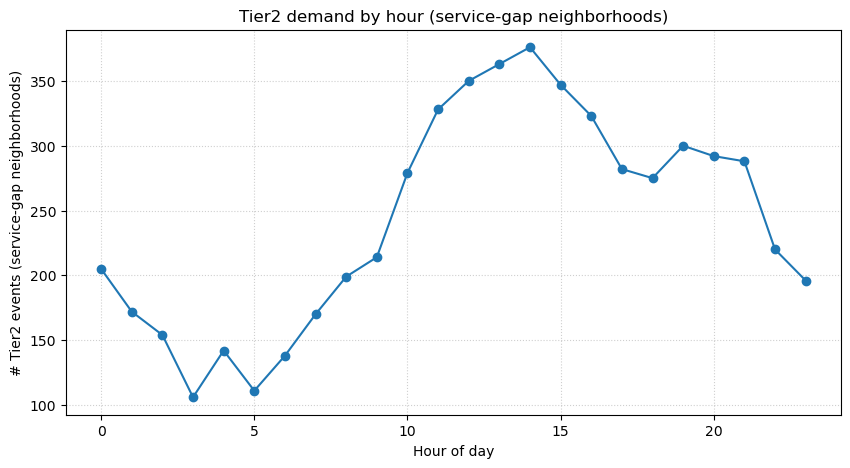

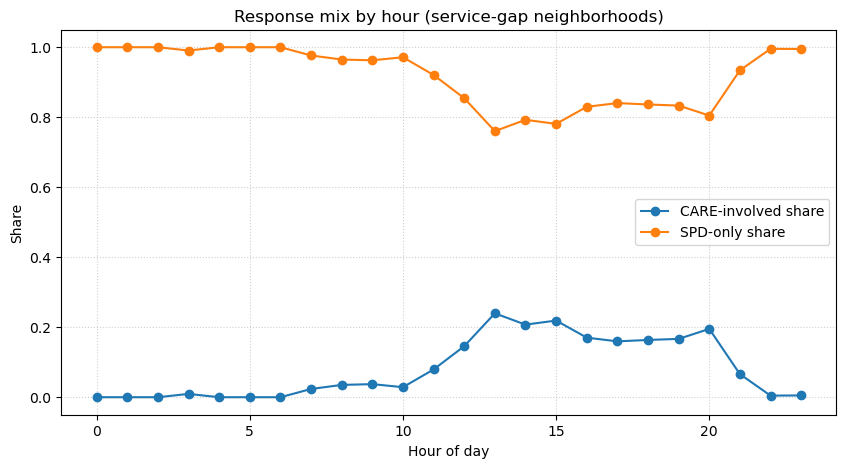

In [229]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sg_hour_counts["hour"], sg_hour_counts["n_events"], marker="o")
ax.set_xlabel("Hour of day")
ax.set_ylabel("# Tier2 events (service-gap neighborhoods)")
ax.set_title("Tier2 demand by hour (service-gap neighborhoods)")
ax.grid(True, linestyle=":", alpha=0.6)
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sg_hour_perf["hour"], sg_hour_perf["care_share"], marker="o", label="CARE-involved share")
ax.plot(sg_hour_perf["hour"], sg_hour_perf["spd_only_share"], marker="o", label="SPD-only share")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share")
ax.set_title("Response mix by hour (service-gap neighborhoods)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.show()


In [242]:
successg = eventtime_df[eventtime_df["Community Reporting Area Name"].isin(success_hubs_nbhds)].copy()
print_schema(successg)
successg_top = top_k(successg["final_call_type"], k=15)
display(successg_top)

Schema for df  |  rows=10,671 cols=10
  - cad_event_number: int64
  - Community Reporting Area Name: object
  - final_call_type: object
  - cad_event_clearance_description: object
  - resp_cat: object
  - care_involved: bool
  - spd_only: bool
  - cad_event_original_time_queued: datetime64[us]
  - hour: int32
  - cad_event_response_category: object


,category,count
0,CRISIS COMPLAINT - GENERAL,6141
1,CCR ONLY - COMMUNITY PRESENCE,1524
2,CCR ONLY - ASSIST THE PUBLIC,711
3,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",428
4,PERSON - MISSING PERSON,391
5,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),253
6,SERVICE - WELFARE CHECK,150
7,CCR ONLY - CARE CRISIS RESPONSE,147
8,"CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD",121
9,"CHILD - ABANDONED, ABUSED AND NEGLECTED",107


In [243]:
successg_hour_perf = (successg.groupby("hour")
                .agg(n_events=("cad_event_number","count"),
                     care_share=("care_involved","mean"),
                     spd_only_share=("spd_only","mean"))
                .reset_index()
                .sort_values("hour"))
display(successg_hour_perf)

,hour,n_events,care_share,spd_only_share
0,0,279,0.000000,1.000000
1,1,251,0.003984,0.996016
2,2,227,0.008811,0.991189
3,3,174,0.000000,1.000000
4,4,170,0.000000,1.000000
5,5,165,0.000000,1.000000
6,6,208,0.004808,0.995192
7,7,235,0.021277,0.978723
8,8,281,0.003559,0.996441
9,9,401,0.019950,0.980050


In [233]:
print_schema(eventtime_df)

Schema for df  |  rows=20,867 cols=10
  - cad_event_number: int64
  - Community Reporting Area Name: object
  - final_call_type: object
  - cad_event_clearance_description: object
  - resp_cat: object
  - care_involved: bool
  - spd_only: bool
  - cad_event_original_time_queued: datetime64[us]
  - hour: int32
  - cad_event_response_category: object


In [235]:
print_schema(sg)


Schema for df  |  rows=5,830 cols=10
  - cad_event_number: int64
  - Community Reporting Area Name: object
  - final_call_type: object
  - cad_event_clearance_description: object
  - resp_cat: object
  - care_involved: bool
  - spd_only: bool
  - cad_event_original_time_queued: datetime64[us]
  - hour: int32
  - cad_event_response_category: object


In [236]:
top_types = eventtime_df["final_call_type"].value_counts().head(10).index.tolist()

def care_share_by_type(d):
    return (d[d["final_call_type"].isin(top_types)]
            .groupby("final_call_type")
            .agg(n=("cad_event_number","count"), care_share=("care_involved","mean"))
            .reset_index()
            .sort_values("n", ascending=False))

sg_type = care_share_by_type(sg)
hub_type = care_share_by_type(eventtime_df[eventtime_df[name_col].isin(success_hubs_nbhds)])

display(sg_type)
display(hub_type)


,final_call_type,n,care_share
7,CRISIS COMPLAINT - GENERAL,4056,0.021943
8,PERSON - MISSING PERSON,346,0.060694
1,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",306,0.026144
4,CCR ONLY - COMMUNITY PRESENCE,199,1.000000
2,CCR ONLY - ASSIST THE PUBLIC,145,0.972414
0,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),142,0.014085
9,SERVICE - WELFARE CHECK,104,0.144231
6,"CHILD - ABANDONED, ABUSED AND NEGLECTED",82,0.036585
3,CCR ONLY - CARE CRISIS RESPONSE,67,1.000000
5,"CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD",48,0.854167


,final_call_type,n,care_share
7,CRISIS COMPLAINT - GENERAL,6141,0.027683
4,CCR ONLY - COMMUNITY PRESENCE,1524,0.999344
2,CCR ONLY - ASSIST THE PUBLIC,711,0.997187
1,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",428,0.011682
8,PERSON - MISSING PERSON,391,0.046036
0,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),253,0.019763
9,SERVICE - WELFARE CHECK,150,0.160000
3,CCR ONLY - CARE CRISIS RESPONSE,147,0.986395
5,"CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD",121,0.785124
6,"CHILD - ABANDONED, ABUSED AND NEGLECTED",107,0.028037


In [238]:
print(top_types)
print(overall_top)
print(sg_top)

['CRISIS COMPLAINT - GENERAL', 'CCR ONLY - COMMUNITY PRESENCE', 'PERSON - MISSING PERSON', 'CCR ONLY - ASSIST THE PUBLIC', 'CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED', 'CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD)', 'SERVICE - WELFARE CHECK', 'CHILD - ABANDONED, ABUSED AND NEGLECTED', 'CCR ONLY - CARE CRISIS RESPONSE', 'CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD']
                                          category  count
0                       CRISIS COMPLAINT - GENERAL  12851
1                    CCR ONLY - COMMUNITY PRESENCE   2112
2                          PERSON - MISSING PERSON   1028
3                     CCR ONLY - ASSIST THE PUBLIC    977
4    CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED    968
5   CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD)    453
6                          SERVICE - WELFARE CHECK    333
7          CHILD - ABANDONED, ABUSED AND NEGLECTED    298
8                  CCR ONLY - CARE CRISIS RESPONSE    243
9     CCR ONLY - WELFARE CHK, DOWN PERSON, EX

In [240]:
# % of all Tier2 events for the 3 “suspect” call types
# Assumes you already have:
#   - events = event-level Tier2 df (deduped by cad_event_number)
#   - events["care_involved"] and events["spd_only"] (optional, but nice)
#   - final_call_type column exists

import pandas as pd

type_col = "final_call_type"

suspect = [
    "CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD)",
    "CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",
    "CHILD - ABANDONED, ABUSED AND NEGLECTED",
]

# Total Tier2 events (event-level)
total_tier2 = len(eventtime_df)

# Compute counts + % of all Tier2
suspect_stats = (eventtime_df[eventtime_df[type_col].isin(suspect)]
                 .groupby(type_col)
                 .agg(
                     n=("cad_event_number", "count"),
                     care_share=("care_involved", "mean") if "care_involved" in eventtime_df.columns else (type_col, "size"),
                     spd_only_share=("spd_only", "mean") if "spd_only" in eventtime_df.columns else (type_col, "size"),
                 )
                 .reset_index())

# If care_involved/spd_only were missing, the above agg placeholders aren't meaningful;
# replace them with NaN so you don't accidentally interpret them.
if "care_involved" not in eventtime_df.columns:
    suspect_stats["care_share"] = pd.NA
if "spd_only" not in eventtime_df.columns:
    suspect_stats["spd_only_share"] = pd.NA

suspect_stats["pct_of_all_tier2"] = 100 * suspect_stats["n"] / total_tier2

# Order nicely
suspect_stats = suspect_stats.sort_values("n", ascending=False)

print(f"Total Tier2 events (event-level): {total_tier2}")
display(suspect_stats)


Total Tier2 events (event-level): 20867


,final_call_type,n,care_share,spd_only_share,pct_of_all_tier2
1,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",968,0.019628,0.980372,4.638904
0,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),453,0.017660,0.982340,2.170892
2,"CHILD - ABANDONED, ABUSED AND NEGLECTED",298,0.026846,0.973154,1.428092


In [241]:
tier2_calltype_stats = (eventtime_df
                 .groupby(type_col)
                 .agg(
                     n=("cad_event_number", "count"),
                     care_share=("care_involved", "mean") if "care_involved" in eventtime_df.columns else (type_col, "size"),
                     spd_only_share=("spd_only", "mean") if "spd_only" in eventtime_df.columns else (type_col, "size"),
                 )
                 .reset_index())


if "care_involved" not in eventtime_df.columns:
    tier2_calltype_stats["care_share"] = pd.NA
if "spd_only" not in eventtime_df.columns:
    tier2_calltype_stats["spd_only_share"] = pd.NA

tier2_calltype_stats["pct_of_all_tier2"] = 100 * tier2_calltype_stats["n"] / total_tier2

# Order nicely
tier2_calltype_stats = tier2_calltype_stats.sort_values("n", ascending=False)

print(f"Total Tier2 events (event-level): {total_tier2}")
display(tier2_calltype_stats)

Total Tier2 events (event-level): 20867


,final_call_type,n,care_share,spd_only_share,pct_of_all_tier2
14,CRISIS COMPLAINT - GENERAL,12851,0.025290,0.974710,61.585278
4,CCR ONLY - COMMUNITY PRESENCE,2112,0.999053,0.000947,10.121244
25,PERSON - MISSING PERSON,1028,0.053502,0.946498,4.926439
2,CCR ONLY - ASSIST THE PUBLIC,977,0.991812,0.008188,4.682034
1,"CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED",968,0.019628,0.980372,4.638904
0,CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD),453,0.017660,0.982340,2.170892
29,SERVICE - WELFARE CHECK,333,0.165165,0.834835,1.595821
11,"CHILD - ABANDONED, ABUSED AND NEGLECTED",298,0.026846,0.973154,1.428092
3,CCR ONLY - CARE CRISIS RESPONSE,243,0.987654,0.012346,1.164518
8,"CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD",224,0.790179,0.209821,1.073465


Doing similar analysis but for reduced/more sensitive tier 2 event list:

In [244]:
DF2 = nhbd_careshare  # Your existing dataframe
print_schema(DF2)
sensitivelist = ["CCR ONLY - COMMUNITY PRESENCE", "CCR ONLY - ASSIST THE PUBLIC", "SERVICE - WELFARE CHECK", "CCR ONLY - CARE CRISIS RESPONSE", "CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD", "DOWN - CHECK FOR DOWN PERSON", "CRISIS COMPLAINT - PICK-UP OR TRANSPORT", "OVERDOSE", "CHILD - CHILD ENDANGERMENT", "PERSON IN BEHAVIORAL/EMOTIONAL CRISIS", "SUICIDE - CRITICAL", "SUICIDE - SUICIDAL PERSON AND ATTEMPTS", "CCR ONLY - SUICIDAL PERSON", "CCR ONLY - NON-OD SUD CALL", "CCR ONLY - OVERDOSE", "DETOX - REQUEST FOR"]
DF2 = (DF2[DF2["Community Reporting Area Name"].isin(suspect)])
print_schema(DF2)

Schema for df  |  rows=40 cols=6
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - pop_total: float64
  - rse_quintile_nhbd_score_label: object
Schema for df  |  rows=0 cols=6
  - Community Reporting Area Name: object
  - n_tier2_events: int64
  - n_care_involved: int64
  - share_care_involved: float64
  - pop_total: float64
  - rse_quintile_nhbd_score_label: object


In [248]:
print_schema(events2_sensitive)

Schema for df  |  rows=4,595 cols=78
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]


In [22]:
df_call_map_joined_copy = df_call_map_joined.copy()
print_schema(df_call_map_joined)


Schema for df  |  rows=324,386 cols=49
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us

In [25]:
import pandas as pd

# 1. Create a cross-tabulation of final_call_type and response_category
# normalize='index' ensures the percentages sum to 100% for each call type
response_distribution = pd.crosstab(
    df_call_map_joined_copy['final_call_type'], 
    df_call_map_joined_copy['cad_event_response_category'], 
    normalize='index'
) * 100


# 3. Format for readability (rounding to 2 decimal places)
print(response_distribution.round(2))

# Optional: Save to CSV for the Notion report
response_distribution.to_csv("call_type_response_distribution.csv")

cad_event_response_category                    CARE     SPD  \
final_call_type                                               
ABANDONED VEHICLE                               0.0  100.00   
ABDUCTION - NO KNOWN KIDNAPPING                 0.0  100.00   
ALARM - ATM MACHINE, FREE STANDING              0.0  100.00   
ALARM - AUDIBLE AUTOMOBILE (UNOCC/ANTI-THEFT)   0.0  100.00   
ALARM - BANK (HOLD-UP)                          0.0  100.00   
...                                             ...     ...   
WATER FLOODS (BROKEN MAINS/HYDRANTS, NO HAZ)    0.0  100.00   
WEAPN - GUN,DEADLY WPN (NO THRTS/ASLT/DIST)     0.0  100.00   
WEAPON, PERSON WITH - GUN                       0.0  100.00   
WEAPON,PERSON WITH - OTHER WEAPON               0.0   99.73   
WIRES DOWN (PHONE, ELECTRICAL,ETC.)             0.0  100.00   

cad_event_response_category                    SPD/CARE Co-Response  
final_call_type                                                      
ABANDONED VEHICLE                       

In [23]:
print_schema(df_call_rse_joined, "df_call_rse_joined")

Schema for df_call_rse_joined  |  rows=324,386 cols=75
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_tim

In [27]:
# CARE-only response given to Tier 0 (SPD) calls
df_care_only_on_tier0 = (
    df_call_rse_joined[
        (df_call_rse_joined["care_tier"] == "Tier 0 - Traditional SPD") &
        (df_call_rse_joined["cad_event_response_category"] == "CARE")
    ]
    .copy()
)

print("rows:", len(df_care_only_on_tier0))
print("unique cad_event_number:", df_care_only_on_tier0["cad_event_number"].nunique())


rows: 709
unique cad_event_number: 709


In [30]:
print("\ncare_tier value_counts (top 15):")
print(df_call_rse_joined["care_tier"].value_counts(dropna=False).head(15))
print("\ncad_event_response_category (top 15):")
print(df_call_rse_joined["cad_event_response_category"].value_counts(dropna=False).head(15))
print("\ncall_type (top 15):")
print(df_call_rse_joined["call_type"].value_counts(dropna=False).head(15))


care_tier value_counts (top 15):
care_tier
Tier 0 - Traditional SPD    177837
Tier 1 - Potential CARE     125682
Tier 2 - Clearly CARE        20867
Name: count, dtype: int64

cad_event_response_category (top 15):
cad_event_response_category
SPD                     317556
CARE                      3847
SPD/CARE Co-Response      2983
Name: count, dtype: int64

call_type (top 15):
call_type
911                              146112
ONVIEW                            93770
TELEPHONE OTHER, NOT 911          82396
ALARM CALL (NOT POLICE ALARM)      1907
TEXT MESSAGE                        132
PROACTIVE (OFFICER INITIATED)        61
SCHEDULED EVENT (RECURRING)           6
IN PERSON COMPLAINT                   1
HISTORY CALL (RETRO)                  1
Name: count, dtype: int64


In [29]:
# Top Tier 0 call types that still got CARE-only response
print("by call type:")
print(df_care_only_on_tier0["call_type"]
    .value_counts()
    .head(50))

# By neighborhood
print("by neighbourhood:")
print(
    df_care_only_on_tier0["dispatch_neighborhood"]
    .value_counts()
    .head(50)
)

# Hour-of-day (using original queued time)
df_care_only_on_tier0["hour"] = df_care_only_on_tier0["cad_event_original_time_queued"].dt.hour
df_care_only_on_tier0["hour"].value_counts().sort_index()


by call type:
call_type
ONVIEW                      672
TELEPHONE OTHER, NOT 911     19
911                          18
Name: count, dtype: int64
by neighbourhood:
dispatch_neighborhood
UNIVERSITY                          84
DOWNTOWN COMMERCIAL                 78
CAPITOL HILL                        69
BALLARD SOUTH                       56
UNKNOWN                             46
COLUMBIA CITY                       46
PIONEER SQUARE                      37
ALASKA JUNCTION                     32
ROOSEVELT/RAVENNA                   24
LAKECITY                            19
NORTH BEACON HILL                   19
CHINATOWN/INTERNATIONAL DISTRICT    18
NORTHGATE                           16
-                                   14
ALKI                                14
LAKEWOOD/SEWARD PARK                14
FREMONT                             13
SLU/CASCADE                         10
ROXHILL/WESTWOOD/ARBOR HEIGHTS      10
BITTERLAKE                           9
QUEEN ANNE                        

hour
7       1
10      1
11      3
12     30
13    136
14    147
15     76
16     66
17     49
18     63
19     74
20     51
21     12
Name: count, dtype: int64

In [31]:
summary = (
    df_care_only_on_tier0
    .groupby("call_type")  # or original_call_type / priority / problem
    .size()
    .sort_values(ascending=False)
)

summary.head(10)


call_type
ONVIEW                      672
TELEPHONE OTHER, NOT 911     19
911                          18
dtype: int64

In [33]:
# Top Tier 0 call types that still got CARE-only response
print("by final_call_type:")
print(df_care_only_on_tier0["final_call_type"]
    .value_counts()
    .head(50))

by final_call_type:
final_call_type
PREMISE CHECK, OFFICER INITIATED ONVIEW ONLY          420
ASSIST PUBLIC - NO WELFARE CHK OR DV ORDER SERVICE    130
DIRECTED PATROL ACTIVITY                               93
PREMISE CHECKS - CRIME PREVENTION                      30
ASSIST OTHER AGENCY - ROUTINE SERVICE                   9
TEST CALL ONLY                                          7
FOLLOW UP                                               6
ASSIST OTHER AGENCY - CITY AGENCY                       3
ASSIGNED DUTY - COMMUNITY,SCHOOL,SPECIAL EVENT          2
MVC - COLLISION (ALL)                                   2
PREMISE CHECKS - LICENSE INSPECTIONS                    1
BROADCAST AND CLEAR BY RADIO                            1
ASSIGNED DUTY - MEET W/ SUPERVISOR (OUT OF SVC)         1
ASSIGNED DUTY - DETAIL BY SUPERVISOR                    1
ASSIGNED DUTY - OTHER ESCORT                            1
PREMISE CHECKS - BUSINESS CHECK                         1
GAS/MAINTENANCE/WASH/GARAGE         

In [34]:
df_non_onview = df_care_only_on_tier0[
    df_care_only_on_tier0["call_type"] != "ONVIEW"
]
df_non_onview["final_call_type"].value_counts()


final_call_type
ASSIST PUBLIC - NO WELFARE CHK OR DV ORDER SERVICE    23
TEST CALL ONLY                                         6
ASSIST OTHER AGENCY - ROUTINE SERVICE                  5
ASSIST OTHER AGENCY - CITY AGENCY                      1
FOLLOW UP                                              1
BROADCAST AND CLEAR BY RADIO                           1
Name: count, dtype: int64

In [140]:
df = df_call_rse_joined_tier2.copy()

# CARE involvement = CARE-only OR Co-response
df["has_care"] = df["cad_event_response_category"].isin(
    ["CARE", "SPD/CARE Co-Response"]
)


In [141]:
nbhd_summary = (
    df
    .groupby("dispatch_neighborhood")
    .agg(
        tier2_volume=("cad_event_number", "nunique"),
        care_involved=("has_care", "sum"),
        care_share=("has_care", "mean"),  # mean of boolean = share
        composite_score_pct=("composite_score_percentile_nbhd", "mean")
    )
    .reset_index()
)


In [142]:
nbhd_summary["unmet_tier2_volume"] = (
    nbhd_summary["tier2_volume"] * (1 - nbhd_summary["care_share"])
)


In [143]:
nbhd_ranked = (
    nbhd_summary
    .sort_values("unmet_tier2_volume", ascending=False)
)


In [144]:
nbhd_ranked[
    [
        "dispatch_neighborhood",
        "tier2_volume",
        "care_share",
        "unmet_tier2_volume",
        "composite_score_pct"
    ]
].head(10)


,dispatch_neighborhood,tier2_volume,care_share,unmet_tier2_volume,composite_score_pct
8,CAPITOL HILL,1589,0.294525,1121.0,35.602893
14,DOWNTOWN COMMERCIAL,1448,0.308702,1001.0,82.213312
51,SLU/CASCADE,1133,0.139453,975.0,28.762237
41,NORTHGATE,1085,0.113364,962.0,57.716338
18,FIRST HILL,1020,0.089216,929.0,62.894180
27,LAKECITY,803,0.150685,682.0,53.072268
48,ROOSEVELT/RAVENNA,750,0.117333,662.0,12.753973
10,CHINATOWN/INTERNATIONAL DISTRICT,769,0.205462,611.0,91.594923
6,BITTERLAKE,689,0.119013,607.0,49.402273
45,QUEEN ANNE,689,0.133527,597.0,16.293600


“Officer discovery burden” (field reality lens)

In [71]:
df = df_call_rse_joined_tier2.copy()

# Officer-initiated discovery
df["is_onview"] = df["call_type"] == "ONVIEW"


In [ ]:
overall_onview_rate = df["is_onview"].mean()
overall_onview_rate


np.float64(0.20908611683519432)

In [73]:
nbhd_onview = (
    df
    .groupby("dispatch_neighborhood")
    .agg(
        tier2_volume=("cad_event_number", "nunique"),
        onview_count=("is_onview", "sum"),
        onview_share=("is_onview", "mean")
    )
    .reset_index()
)


In [74]:
print_schema(df_call_rse_joined_tier2)

Schema for df  |  rows=20,867 cols=76
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [76]:
nbhd_onview.sort_values("onview_count", ascending=False).head(50)


,dispatch_neighborhood,tier2_volume,onview_count,onview_share
8,CAPITOL HILL,1589,712,0.448081
14,DOWNTOWN COMMERCIAL,1448,505,0.348757
56,UNIVERSITY,844,295,0.349526
4,BALLARD SOUTH,689,265,0.384615
51,SLU/CASCADE,1133,240,0.211827
57,UNKNOWN,534,234,0.438202
10,CHINATOWN/INTERNATIONAL DISTRICT,769,188,0.244473
44,PIONEER SQUARE,489,146,0.298569
41,NORTHGATE,1085,131,0.120737
1,ALASKA JUNCTION,334,120,0.359281


In [77]:
nbhd_onview.sort_values("onview_share", ascending=False).head(50)


,dispatch_neighborhood,tier2_volume,onview_count,onview_share
0,-,6,6,1.000000
2,ALKI,208,117,0.562500
8,CAPITOL HILL,1589,712,0.448081
28,LAKEWOOD/SEWARD PARK,109,48,0.440367
57,UNKNOWN,534,234,0.438202
12,COLUMBIA CITY,233,99,0.424893
4,BALLARD SOUTH,689,265,0.384615
1,ALASKA JUNCTION,334,120,0.359281
56,UNIVERSITY,844,295,0.349526
14,DOWNTOWN COMMERCIAL,1448,505,0.348757


In [92]:
nbhd_onview = nbhd_onview[nbhd_onview["tier2_volume"] >= 100]


In [93]:
nbhd_onview.sort_values("onview_count", ascending=False).head(50)


,dispatch_neighborhood,tier2_volume,onview_count,onview_share
8,CAPITOL HILL,1589,712,0.448081
14,DOWNTOWN COMMERCIAL,1448,505,0.348757
56,UNIVERSITY,844,295,0.349526
4,BALLARD SOUTH,689,265,0.384615
51,SLU/CASCADE,1133,240,0.211827
57,UNKNOWN,534,234,0.438202
10,CHINATOWN/INTERNATIONAL DISTRICT,769,188,0.244473
44,PIONEER SQUARE,489,146,0.298569
41,NORTHGATE,1085,131,0.120737
1,ALASKA JUNCTION,334,120,0.359281


In [94]:
nbhd_onview.sort_values("onview_share", ascending=False).head(50)


,dispatch_neighborhood,tier2_volume,onview_count,onview_share
2,ALKI,208,117,0.562500
8,CAPITOL HILL,1589,712,0.448081
28,LAKEWOOD/SEWARD PARK,109,48,0.440367
57,UNKNOWN,534,234,0.438202
12,COLUMBIA CITY,233,99,0.424893
4,BALLARD SOUTH,689,265,0.384615
1,ALASKA JUNCTION,334,120,0.359281
56,UNIVERSITY,844,295,0.349526
14,DOWNTOWN COMMERCIAL,1448,505,0.348757
52,SODO,177,54,0.305085


In [95]:
df["has_care"] = df["cad_event_response_category"].isin(["CARE", "Co-response"])

nbhd_onview_care = (
    df
    .groupby("dispatch_neighborhood")
    .agg(
        tier2_volume=("cad_event_number", "nunique"),
        onview_share=("is_onview", "mean"),
        care_share=("has_care", "mean")
    )
    .reset_index()
)


KeyError: "Column(s) ['is_onview'] do not exist"

In [82]:
nbhd_onview_care.sort_values("onview_share", ascending=False).head(50)

,dispatch_neighborhood,tier2_volume,onview_share,care_share
0,-,6,1.000000,0.333333
2,ALKI,208,0.562500,0.524038
8,CAPITOL HILL,1589,0.448081,0.236627
28,LAKEWOOD/SEWARD PARK,109,0.440367,0.412844
57,UNKNOWN,534,0.438202,0.250936
12,COLUMBIA CITY,233,0.424893,0.416309
4,BALLARD SOUTH,689,0.384615,0.384615
1,ALASKA JUNCTION,334,0.359281,0.341317
56,UNIVERSITY,844,0.349526,0.366114
14,DOWNTOWN COMMERCIAL,1448,0.348757,0.263812


 check the tier 2 care eligible call types has at least one care response so that we know that the tiers are good

In [88]:
df = df_call_rse_joined.copy()


df["cad_event_response_category"].value_counts()


cad_event_response_category
SPD                     317556
CARE                      3847
SPD/CARE Co-Response      2983
Name: count, dtype: int64

In [ ]:
df["has_care"] = df["cad_event_response_category"].isin(
    ["CARE", "SPD/CARE Co-Response"]
)

Schema for df_call_rse_joined  |  rows=324,386 cols=75
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_tim

In [89]:
df["care_tier"].value_counts()

care_tier
Tier 0 - Traditional SPD    177837
Tier 1 - Potential CARE     125682
Tier 2 - Clearly CARE        20867
Name: count, dtype: int64

In [104]:
df_tier2 = df[
    df["care_tier"] == "Tier 2 - Clearly CARE"
]
print_schema(df_tier2)
df_tier1 = df[
    df["care_tier"] == "Tier 1 - Potential CARE"
]

Schema for df  |  rows=20,867 cols=76
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us]

In [102]:
print("Unique final call type:", df_tier2["final_call_type"].nunique(dropna=False))
df_tier2["final_call_type"].value_counts()

Unique final call type: 33


final_call_type
CRISIS COMPLAINT - GENERAL                        12851
CCR ONLY - COMMUNITY PRESENCE                      2112
PERSON - MISSING PERSON                            1028
CCR ONLY - ASSIST THE PUBLIC                        977
CASUALTY,NON-TRAF,NON-CRIM - NON-DRUG RELATED       968
CASUALTY NON-TRAF NON-CRIM - DRUG RELATED (OD)      453
SERVICE - WELFARE CHECK                             333
CHILD - ABANDONED, ABUSED AND NEGLECTED             298
CCR ONLY - CARE CRISIS RESPONSE                     243
CCR ONLY - WELFARE CHK, DOWN PERSON, EXCL OD        224
PERSON - FOUND PERSON                               196
PROPERTY - MISSING PROPERTY                         162
DOWN - CHECK FOR DOWN PERSON                        143
CRISIS COMPLAINT - PICK-UP OR TRANSPORT             125
OVERDOSE                                            117
CHILD - CHILD ENDANGERMENT                           87
DOA - CASUALTY, DEAD BODY                            84
MISSING - ADULT                 

In [107]:
import pandas as pd
import numpy as np

# Inputs:
# df_tier2: subset where care_tier == "Tier 2 - Clearly CARE"
# df_call_rse_joined: full dataset

df_all = df_call_rse_joined.copy()

CARE_CATS = ["CARE", "SPD/CARE Co-Response"]

# 1) Tier 2 call type universe (from tier2 subset)
tier2_calltypes = (
    df_tier2["final_call_type"]
    .dropna()
    .unique()
)
tier1_calltypes = (
    df_tier1["final_call_type"]
    .dropna()
    .unique()
)

# 2) Filter full df to only those call types
df_all_ct = df_all[df_all["final_call_type"].isin(tier2_calltypes)].copy()
df_all_ct_1 = df_all[df_all["final_call_type"].isin(tier1_calltypes)].copy()

# 3) CARE involvement flag on full df rows
df_all_ct["has_care"] = df_all_ct["cad_event_response_category"].isin(CARE_CATS)
df_all_ct_1["has_care"] = df_all_ct_1["cad_event_response_category"].isin(CARE_CATS)

# 4) Summarize: for each final_call_type, does it EVER have a CARE-involved CAD?
calltype_validity = (
    df_all_ct
    .groupby("final_call_type")
    .agg(
        n_events_all=("cad_event_number", "nunique"),
        n_events_with_care=("has_care", lambda s: df_all_ct.loc[s.index, "cad_event_number"][s].nunique()),
        ever_seen_with_care=("has_care", "any"),
        care_share_events=("has_care", "mean"),  # row-level share; optional
    )
    .reset_index()
    .sort_values(["ever_seen_with_care", "n_events_all"], ascending=[True, False])
)

calltype_validity_1 = (
    df_all_ct_1
    .groupby("final_call_type")
    .agg(
        n_events_all=("cad_event_number", "nunique"),
        n_events_with_care=("has_care", lambda s: df_all_ct_1.loc[s.index, "cad_event_number"][s].nunique()),
        ever_seen_with_care=("has_care", "any"),
        care_share_events=("has_care", "mean"),  # row-level share; optional
    )
    .reset_index()
    .sort_values(["ever_seen_with_care", "n_events_all"], ascending=[True, False])
)

# 5) Quick diagnostics
print("Tier2 unique final_call_type:", len(tier2_calltypes))
print("Call types with ZERO CARE-ever:", (calltype_validity["ever_seen_with_care"] == False).sum())

# 6) View the ones that never show CARE in the full dataset
zero_care_calltypes = calltype_validity[calltype_validity["ever_seen_with_care"] == False]
zero_care_calltypes.head(50)




Tier2 unique final_call_type: 33
Call types with ZERO CARE-ever: 8


,final_call_type,n_events_all,n_events_with_care,ever_seen_with_care,care_share_events
28,PROPERTY - MISSING PROPERTY,162,0,False,0.0
23,OVERDOSE,117,0,False,0.0
21,MISSING - ADULT,67,0,False,0.0
10,"CHILD - ABAND, ABUSE, MOLEST, NEGLECT",62,0,False,0.0
13,"CHILD - CRITICAL ABAND, ABUSE, MOLEST, NEGLECT",13,0,False,0.0
32,TRU - MISSING ADULT,7,0,False,0.0
9,CHILD - LURING,3,0,False,0.0
16,DETOX - REQUEST FOR,1,0,False,0.0


In [108]:
# 5) Quick diagnostics
print("Tier1 unique final_call_type:", len(tier1_calltypes))
print("Call types with ZERO CARE-ever:", (calltype_validity_1["ever_seen_with_care"] == False).sum())

# 6) View the ones that never show CARE in the full dataset
zero_care_calltypes_1 = calltype_validity_1[calltype_validity_1["ever_seen_with_care"] == False]
zero_care_calltypes_1.head(50)

Tier1 unique final_call_type: 45
Call types with ZERO CARE-ever: 20


,final_call_type,n_events_all,n_events_with_care,ever_seen_with_care,care_share_events
28,PREMISE CHECKS - HOMELESS ENCAMPMENT,716,0,False,0.0
3,"ANIMAL COMPLAINT - INJURED,DEAD,DANGEROUS",183,0,False,0.0
18,INTOX & LIQ VIOLS - ADULTS (VIOLATIONS),91,0,False,0.0
17,HARAS - NO BIAS OR THREATS,70,0,False,0.0
20,INTOX & LIQ VIOLS - MINORS (VIOLATIONS),32,0,False,0.0
21,JUVENILE - RUNAWAY,28,0,False,0.0
42,TRU - SUSPICIOUS CIRCUMSTANCES,16,0,False,0.0
44,"URINATING, DEFECATING IN PUBLIC",11,0,False,0.0
34,SUSPICIOUS PACKAGE,10,0,False,0.0
26,"PANHANDLING, AGGRESSIVE",9,0,False,0.0


In [ ]:
total_events_all = calltype_validity["n_events_all"].sum()
total_events_all



np.int64(432)

In [111]:
never_care = calltype_validity[
    calltype_validity["ever_seen_with_care"] == False
]

never_care_events = never_care["n_events_all"].sum()
never_care_events

np.int64(432)

In [113]:
never_care["share_of_tier2_events"] = (
    never_care["n_events_all"] / total_events_all
)*100

never_care.sort_values("n_events_all", ascending=False)


/var/folders/3_/1rhf9qv926gdc06htyqtwt580000gn/T/ipykernel_5151/2292938011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  never_care["share_of_tier2_events"] = (


,final_call_type,n_events_all,n_events_with_care,ever_seen_with_care,care_share_events,share_of_tier2_events
28,PROPERTY - MISSING PROPERTY,162,0,False,0.0,0.776345
23,OVERDOSE,117,0,False,0.0,0.560694
21,MISSING - ADULT,67,0,False,0.0,0.321081
10,"CHILD - ABAND, ABUSE, MOLEST, NEGLECT",62,0,False,0.0,0.297120
13,"CHILD - CRITICAL ABAND, ABUSE, MOLEST, NEGLECT",13,0,False,0.0,0.062299
32,TRU - MISSING ADULT,7,0,False,0.0,0.033546
9,CHILD - LURING,3,0,False,0.0,0.014377
16,DETOX - REQUEST FOR,1,0,False,0.0,0.004792


In [145]:
print_schema(df_call_rse_joined)

Schema for df  |  rows=324,386 cols=75
  - cad_event_number: int64
  - cad_event_clearance_description: object
  - call_type: object
  - priority: int64
  - initial_call_type: object
  - final_call_type: object
  - cad_event_original_time_queued: datetime64[us]
  - cad_event_arrived_time: datetime64[us]
  - dispatch_precinct: object
  - dispatch_sector: object
  - dispatch_beat: object
  - dispatch_longitude: object
  - dispatch_latitude: object
  - dispatch_reporting_area: object
  - cad_event_response_category: object
  - call_sign_dispatch_id: object
  - call_sign_dispatch_time: datetime64[us]
  - first_care_call_sign_at_scene_time: datetime64[us]
  - first_care_call_sign_dispatch_time: datetime64[us]
  - first_co_response_call_sign_at_scene_time: datetime64[us]
  - first_co_response_call_sign_dispatch_time: datetime64[us]
  - first_spd_call_sign_at_scene_time: datetime64[us]
  - first_spd_call_sign_dispatch_time: datetime64[us]
  - last_care_call_sign_in_service_time: datetime64[us

reactive and proactive zones for onview calss

In [176]:
import numpy as np
import pandas as pd

df0 = df_call_rse_joined.copy()
# Define the categories that count as receiving CARE
care_categories = ["CARE", "SPD/CARE Co-Response"]


# Flags
df0["is_911"] = df0["call_type"].eq("911")
df0["is_onview"] = df0["call_type"].eq("ONVIEW")
df0["is_tier2"] = df0["care_tier"].eq("Tier 2 - Clearly CARE")  # adjust if your label differs
# Create the boolean column
df0["is_received_care"] = df0["cad_event_response_category"].str.strip().isin(care_categories)

# Neighborhood-level summary
nb = (
    df0.groupby("dispatch_neighborhood")
    .agg(
        total_events=("cad_event_number", "nunique"),
        n_911=("is_911", "sum"),
        n_onview=("is_onview", "sum"),
        tier2_events=("is_tier2", "sum"),
        n_receivedcare=("is_received_care","sum")
    )
    .reset_index()
)

# Shares (within all events in the neighborhood)
nb["share_911"] = nb["n_911"] / nb["total_events"]
nb["share_onview"] = nb["n_onview"] / nb["total_events"]

# Optional: also compute ONVIEW share within Tier 2 only (field-discovery lens for crises)
tier2_nb = (
    df0[df0["is_tier2"]]
    .groupby("dispatch_neighborhood")
    .agg(
        tier2_events_check=("cad_event_number", "nunique"),
        tier2_onview_share=("is_onview", "mean"),
        tier2_911_share=("is_911","mean"),
        tier2_receivedcare_share=("is_received_care","mean"),
        n_tier2_onview=("is_onview", "sum"),
        n_911_onview=("is_911", "sum"),
        n_recieved_care=("is_received_care","sum")
    )
    .reset_index()
)

nb = nb.merge(tier2_nb, on="dispatch_neighborhood", how="left")


In [177]:
print(tier2_nb)

               dispatch_neighborhood  tier2_events_check  tier2_onview_share  \
0                                  -                   6            1.000000   
1                    ALASKA JUNCTION                 334            0.359281   
2                               ALKI                 208            0.562500   
3                      BALLARD NORTH                 274            0.072993   
4                      BALLARD SOUTH                 689            0.384615   
5                           BELLTOWN                 580            0.105172   
6                         BITTERLAKE                 689            0.088534   
7                    BRIGHTON/DUNLAP                 201            0.099502   
8                       CAPITOL HILL                1589            0.448081   
9           CENTRAL AREA/SQUIRE PARK                 579            0.046632   
10  CHINATOWN/INTERNATIONAL DISTRICT                 769            0.244473   
11           CLAREMONT/RAINIER VISTA    

In [172]:
df0["call_type"].value_counts()


call_type
911                              146112
ONVIEW                            93770
TELEPHONE OTHER, NOT 911          82396
ALARM CALL (NOT POLICE ALARM)      1907
TEXT MESSAGE                        132
PROACTIVE (OFFICER INITIATED)        61
SCHEDULED EVENT (RECURRING)           6
IN PERSON COMPLAINT                   1
HISTORY CALL (RETRO)                  1
Name: count, dtype: int64

In [174]:
df0["cad_event_response_category"].value_counts()

cad_event_response_category
SPD                     317556
CARE                      3847
SPD/CARE Co-Response      2983
Name: count, dtype: int64

In [173]:
df2=df0[df0["is_tier2"]]
df2["call_type"].value_counts()

call_type
911                              11921
TELEPHONE OTHER, NOT 911          4539
ONVIEW                            4363
TEXT MESSAGE                        32
ALARM CALL (NOT POLICE ALARM)        7
PROACTIVE (OFFICER INITIATED)        3
IN PERSON COMPLAINT                  1
SCHEDULED EVENT (RECURRING)          1
Name: count, dtype: int64

In [162]:
print_schema(tier2_nb)

Schema for df  |  rows=59 cols=6
  - dispatch_neighborhood: object
  - tier2_events_check: int64
  - tier2_onview_share: float64
  - tier2_911_share: float64
  - n_tier2_onview: int64
  - n_911_onview: int64


In [178]:
print_schema(nb)

Schema for df  |  rows=60 cols=15
  - dispatch_neighborhood: object
  - total_events: int64
  - n_911: int64
  - n_onview: int64
  - tier2_events: int64
  - n_receivedcare: int64
  - share_911: float64
  - share_onview: float64
  - tier2_events_check: float64
  - tier2_onview_share: float64
  - tier2_911_share: float64
  - tier2_receivedcare_share: float64
  - n_tier2_onview: float64
  - n_911_onview: float64
  - n_recieved_care: float64


ok the below cut off is for all events but we should look at tier 2 events cutoff.

In [147]:
# Cutoffs
cut_911 = nb["share_911"].median()
cut_onview = nb["share_onview"].median()
cut_tier2 = nb["tier2_events"].median()  # or use a fixed threshold like >= 500

cut_911, cut_onview, cut_tier2


(np.float64(0.4757497541789577),
 np.float64(0.22696523431125107),
 np.float64(208.5))

In [179]:
cut_t2_911 = nb["tier2_911_share"].median()
cut_t2_onview = nb["tier2_onview_share"].median()
cut_tier2 = nb["tier2_events"].median()  # or use a fixed threshold like >= 500
cut_t2_911, cut_t2_onview, cut_tier2

(np.float64(0.6363636363636364),
 np.float64(0.12073732718894009),
 np.float64(208.5))

In [148]:
def zone(row):
    # reactive: high 911, low onview
    if row["share_911"] >= cut_911 and row["share_onview"] < cut_onview:
        return "Reactive Zone (high 911, low ONVIEW)"
    # proactive: low 911, high onview
    if row["share_911"] < cut_911 and row["share_onview"] >= cut_onview:
        return "Proactive Zone (low 911, high ONVIEW)"
    # other quadrants (helpful to keep)
    if row["share_911"] >= cut_911 and row["share_onview"] >= cut_onview:
        return "High 911 + High ONVIEW"
    return "Low 911 + Low ONVIEW"

nb["zone"] = nb.apply(zone, axis=1)
nb["tier2_high"] = nb["tier2_events"] >= cut_tier2


In [180]:
def zone_tier2(row):
    if row["tier2_911_share"] >= cut_t2_911 and row["tier2_onview_share"] < cut_t2_onview:
        return "Reactive Zone (Tier 2 dispatch-driven)"
    if row["tier2_911_share"] < cut_t2_911 and row["tier2_onview_share"] >= cut_t2_onview:
        return "Proactive Zone (Tier 2 patrol-discovered)"
    if row["tier2_911_share"] >= cut_t2_911 and row["tier2_onview_share"] >= cut_t2_onview:
        return "High 911 + High ONVIEW (mixed discovery)"
    return "Low 911 + Low ONVIEW (low visibility)"


In [181]:
nb["zone_tier2"] = nb.apply(zone_tier2, axis=1)
nb["tier2_high"] = nb["tier2_events"] >= cut_tier2

In [182]:
nb_focus_re = nb[nb["tier2_high"]].copy()

# Rank within each zone by Tier 2 volume (or by onview share if you want)
nb_focus_ranked_re = (
    nb_focus_re.sort_values(["zone_tier2", "tier2_events"], ascending=[True, False])
)

nb_focus_ranked_re[
    ["dispatch_neighborhood", "zone_tier2", "tier2_events", "tier2_911_share", "tier2_onview_share"]
].head(25)

,dispatch_neighborhood,zone_tier2,tier2_events,tier2_911_share,tier2_onview_share
42,NORTHGATE,High 911 + High ONVIEW (mixed discovery),1085,0.663594,0.120737
28,LAKECITY,High 911 + High ONVIEW (mixed discovery),803,0.671233,0.132005
51,SANDPOINT,Low 911 + Low ONVIEW (low visibility),299,0.558528,0.093645
8,CAPITOL HILL,Proactive Zone (Tier 2 patrol-discovered),1589,0.377596,0.448081
15,DOWNTOWN COMMERCIAL,Proactive Zone (Tier 2 patrol-discovered),1448,0.494475,0.348757
52,SLU/CASCADE,Proactive Zone (Tier 2 patrol-discovered),1133,0.542807,0.211827
57,UNIVERSITY,Proactive Zone (Tier 2 patrol-discovered),844,0.422986,0.349526
10,CHINATOWN/INTERNATIONAL DISTRICT,Proactive Zone (Tier 2 patrol-discovered),769,0.582575,0.244473
4,BALLARD SOUTH,Proactive Zone (Tier 2 patrol-discovered),689,0.428157,0.384615
58,UNKNOWN,Proactive Zone (Tier 2 patrol-discovered),534,0.185393,0.438202


In [184]:
top_reactive = (
    nb_focus_ranked_re[nb_focus_ranked_re["zone_tier2"].str.contains("Reactive")]
    .sort_values("tier2_events", ascending=False)
    .head(20)
)

print(top_reactive)

             dispatch_neighborhood  total_events  n_911  n_onview  \
19                      FIRST HILL         11682   6445      1821   
49               ROOSEVELT/RAVENNA          8209   4111      1080   
6                       BITTERLAKE          7245   4210      1154   
46                      QUEEN ANNE         11597   5558      1843   
5                         BELLTOWN          7683   4167      1568   
9         CENTRAL AREA/SQUIRE PARK          8016   3838      1120   
23                       GREENWOOD          5013   2721       707   
27  JUDKINS PARK/NORTH BEACON HILL          4611   2814       639   
34                     MILLER PARK          2069   1211       217   
37                     MOUNT BAKER          6345   2906      1747   
3                    BALLARD NORTH          4438   2233       822   
36                          MORGAN          2473    872       980   

    tier2_events  n_receivedcare  share_911  share_onview  tier2_events_check  \
19          1020     

In [187]:
top_reactive[["dispatch_neighborhood","tier2_events","tier2_911_share","tier2_onview_share"]]

,dispatch_neighborhood,tier2_events,tier2_911_share,tier2_onview_share
19,FIRST HILL,1020,0.674510,0.067647
49,ROOSEVELT/RAVENNA,750,0.725333,0.086667
6,BITTERLAKE,689,0.657475,0.088534
46,QUEEN ANNE,689,0.645864,0.098694
5,BELLTOWN,580,0.681034,0.105172
9,CENTRAL AREA/SQUIRE PARK,579,0.639033,0.046632
23,GREENWOOD,385,0.740260,0.054545
27,JUDKINS PARK/NORTH BEACON HILL,369,0.742547,0.043360
34,MILLER PARK,361,0.778393,0.024931
37,MOUNT BAKER,280,0.717857,0.089286


In [186]:
top_proactive = (
    nb_focus_ranked_re[nb_focus_ranked_re["zone_tier2"].str.contains("Proactive")]
    .sort_values("tier2_events", ascending=False)
    .head(20)
)


In [189]:
top_proactive[["dispatch_neighborhood","tier2_events","tier2_911_share","tier2_onview_share"]]

,dispatch_neighborhood,tier2_events,tier2_911_share,tier2_onview_share
8,CAPITOL HILL,1589,0.377596,0.448081
15,DOWNTOWN COMMERCIAL,1448,0.494475,0.348757
52,SLU/CASCADE,1133,0.542807,0.211827
57,UNIVERSITY,844,0.422986,0.349526
10,CHINATOWN/INTERNATIONAL DISTRICT,769,0.582575,0.244473
4,BALLARD SOUTH,689,0.428157,0.384615
58,UNKNOWN,534,0.185393,0.438202
45,PIONEER SQUARE,489,0.537832,0.298569
40,NORTH BEACON HILL,485,0.622680,0.239175
1,ALASKA JUNCTION,334,0.437126,0.359281


Tier 2 Chart generated: tier2_care_quadrant.png


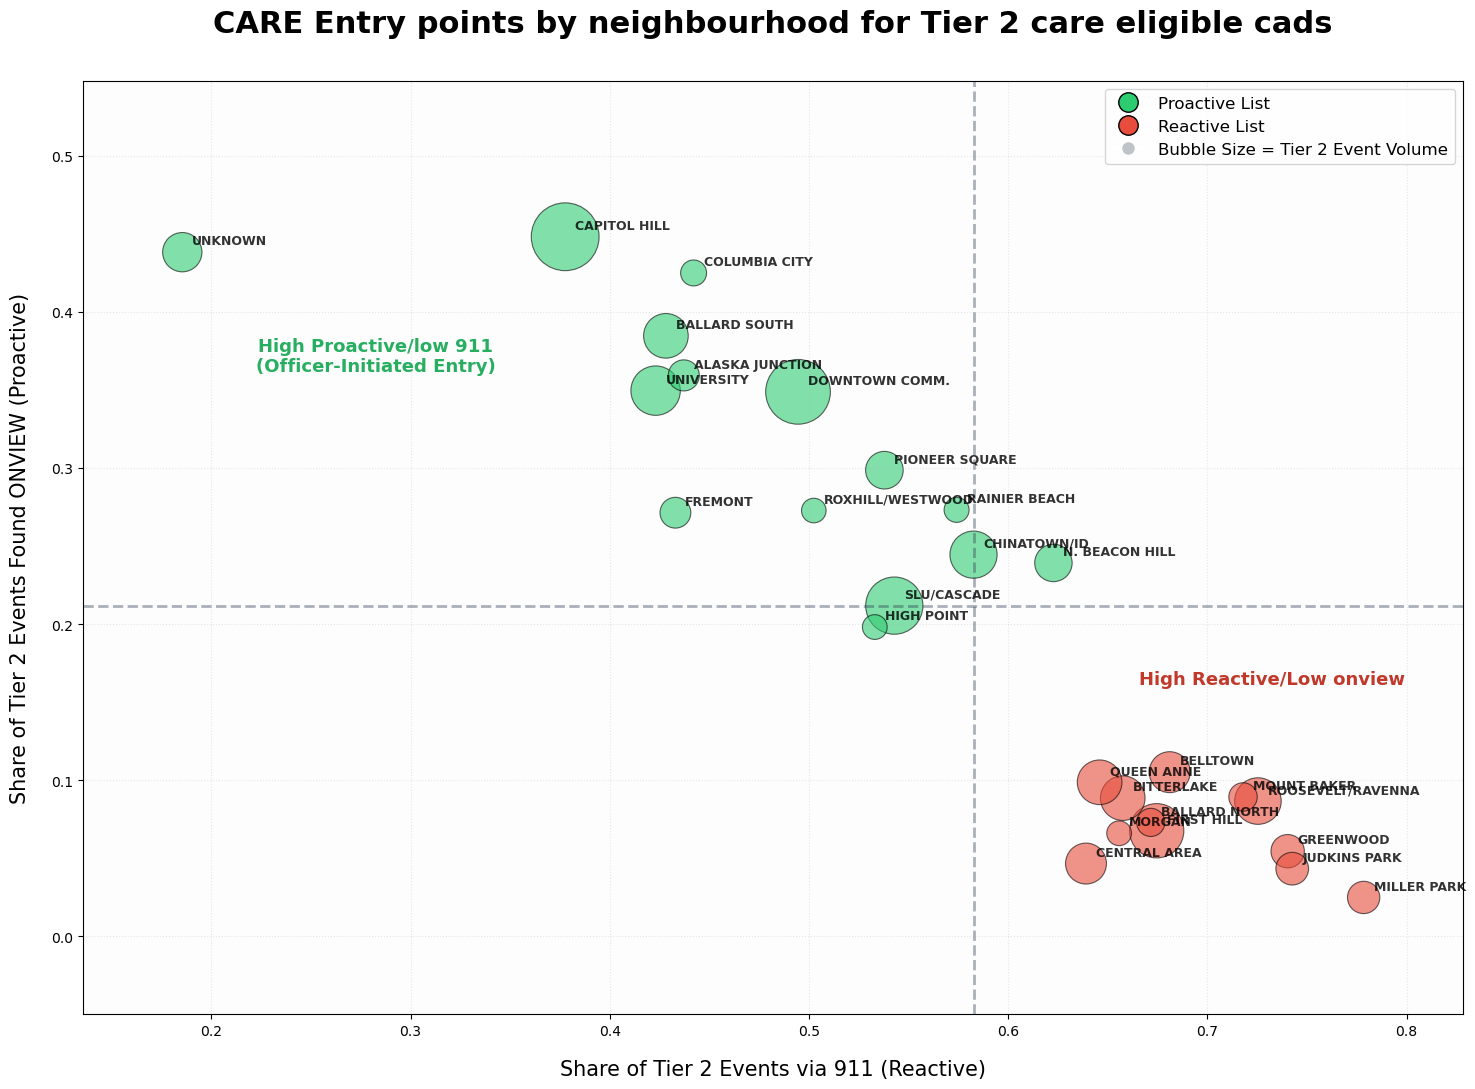

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Data Preparation
data = [
    # Reactive
    {"nb": "FIRST HILL", "events": 1020, "s911": 0.674510, "sov": 0.067647, "type": "Reactive"},
    {"nb": "ROOSEVELT/RAVENNA", "events": 750, "s911": 0.725333, "sov": 0.086667, "type": "Reactive"},
    {"nb": "BITTERLAKE", "events": 689, "s911": 0.657475, "sov": 0.088534, "type": "Reactive"},
    {"nb": "QUEEN ANNE", "events": 689, "s911": 0.645864, "sov": 0.098694, "type": "Reactive"},
    {"nb": "BELLTOWN", "events": 580, "s911": 0.681034, "sov": 0.105172, "type": "Reactive"},
    {"nb": "CENTRAL AREA", "events": 579, "s911": 0.639033, "sov": 0.046632, "type": "Reactive"},
    {"nb": "GREENWOOD", "events": 385, "s911": 0.740260, "sov": 0.054545, "type": "Reactive"},
    {"nb": "JUDKINS PARK", "events": 369, "s911": 0.742547, "sov": 0.043360, "type": "Reactive"},
    {"nb": "MILLER PARK", "events": 361, "s911": 0.778393, "sov": 0.024931, "type": "Reactive"},
    {"nb": "MOUNT BAKER", "events": 280, "s911": 0.717857, "sov": 0.089286, "type": "Reactive"},
    {"nb": "BALLARD NORTH", "events": 274, "s911": 0.671533, "sov": 0.072993, "type": "Reactive"},
    {"nb": "MORGAN", "events": 212, "s911": 0.655660, "sov": 0.066038, "type": "Reactive"},
    # Proactive
    {"nb": "CAPITOL HILL", "events": 1589, "s911": 0.377596, "sov": 0.448081, "type": "Proactive"},
    {"nb": "DOWNTOWN COMM.", "events": 1448, "s911": 0.494475, "sov": 0.348757, "type": "Proactive"},
    {"nb": "SLU/CASCADE", "events": 1133, "s911": 0.542807, "sov": 0.211827, "type": "Proactive"},
    {"nb": "UNIVERSITY", "events": 844, "s911": 0.422986, "sov": 0.349526, "type": "Proactive"},
    {"nb": "CHINATOWN/ID", "events": 769, "s911": 0.582575, "sov": 0.244473, "type": "Proactive"},
    {"nb": "BALLARD SOUTH", "events": 689, "s911": 0.428157, "sov": 0.384615, "type": "Proactive"},
    {"nb": "UNKNOWN", "events": 534, "s911": 0.185393, "sov": 0.438202, "type": "Proactive"},
    {"nb": "PIONEER SQUARE", "events": 489, "s911": 0.537832, "sov": 0.298569, "type": "Proactive"},
    {"nb": "N. BEACON HILL", "events": 485, "s911": 0.622680, "sov": 0.239175, "type": "Proactive"},
    {"nb": "ALASKA JUNCTION", "events": 334, "s911": 0.437126, "sov": 0.359281, "type": "Proactive"},
    {"nb": "FREMONT", "events": 328, "s911": 0.432927, "sov": 0.271341, "type": "Proactive"},
    {"nb": "COLUMBIA CITY", "events": 233, "s911": 0.442060, "sov": 0.424893, "type": "Proactive"},
    {"nb": "RAINIER BEACH", "events": 216, "s911": 0.574074, "sov": 0.273148, "type": "Proactive"},
    {"nb": "HIGH POINT", "events": 212, "s911": 0.533019, "sov": 0.198113, "type": "Proactive"},
    {"nb": "ROXHILL/WESTWOOD", "events": 209, "s911": 0.502392, "sov": 0.272727, "type": "Proactive"}
]

df = pd.DataFrame(data)

# Calculate medians for the crosshair
x_med = df['s911'].median()
y_med = df['sov'].median()

# Colors
colors = {'Proactive': '#2ecc71', 'Reactive': '#e74c3c'}

plt.figure(figsize=(15, 11))

# Bubble sizes
sizes = df['events'] * 1.5

# Scatter Plot
for t in ['Proactive', 'Reactive']:
    subset = df[df['type'] == t]
    plt.scatter(subset['s911'], subset['sov'], 
                s=subset['events'] * 1.5, 
                alpha=0.6, 
                color=colors[t],
                edgecolors='black',
                linewidth=0.8,
                label=f'{t} Neighborhoods')

# Text Annotation
for i, row in df.iterrows():
    plt.text(row['s911'] + 0.005, row['sov'] + 0.005, row['nb'], 
             fontsize=9, fontweight='semibold', alpha=0.8)

# Quadrant Lines
plt.axvline(x=x_med, color='#2c3e50', linestyle='--', alpha=0.4, linewidth=2)
plt.axhline(y=y_med, color='#2c3e50', linestyle='--', alpha=0.4, linewidth=2)

# Quadrant Labels
plt.text(x_med - 0.3, y_med + 0.15, "High Proactive/low 911\n(Officer-Initiated Entry)", 
         color='#27ae60', fontweight='bold', ha='center', fontsize=13)

plt.text(x_med + 0.15, y_med - 0.05, "High Reactive/Low onview", 
         color='#c0392b', fontweight='bold', ha='center', fontsize=13)


# Title and Labels
plt.title("CARE Entry points by neighbourhood for Tier 2 care eligible cads", fontsize=22, pad=35, fontweight='bold')
plt.xlabel("Share of Tier 2 Events via 911 (Reactive)", fontsize=15, labelpad=15)
plt.ylabel("Share of Tier 2 Events Found ONVIEW (Proactive)", fontsize=15, labelpad=15)

# Aesthetics
plt.grid(True, linestyle=':', alpha=0.3)
plt.gca().set_facecolor('#fdfdfd')
plt.xlim(df['s911'].min() - 0.05, df['s911'].max() + 0.05)
plt.ylim(-0.05, df['sov'].max() + 0.1)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Proactive List', markerfacecolor='#2ecc71', markersize=14, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Reactive List', markerfacecolor='#e74c3c', markersize=14, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='Bubble Size = Tier 2 Event Volume', markerfacecolor='#bdc3c7', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=12)

plt.tight_layout()
plt.savefig("tier2_care_quadrant.png", dpi=300)
print("Tier 2 Chart generated: tier2_care_quadrant.png")

This is the old one:

In [149]:
nb_focus = nb[nb["tier2_high"]].copy()

# Rank within each zone by Tier 2 volume (or by onview share if you want)
nb_focus_ranked = (
    nb_focus.sort_values(["zone", "tier2_events"], ascending=[True, False])
)

nb_focus_ranked[
    ["dispatch_neighborhood", "zone", "tier2_events", "share_911", "share_onview", "tier2_onview_share"]
].head(25)


,dispatch_neighborhood,zone,tier2_events,share_911,share_onview,tier2_onview_share
52,SLU/CASCADE,High 911 + High ONVIEW,1133,0.515894,0.236711,0.211827
42,NORTHGATE,High 911 + High ONVIEW,1085,0.485511,0.245624,0.120737
20,FREMONT,Low 911 + Low ONVIEW,328,0.459919,0.164633,0.271341
8,CAPITOL HILL,"Proactive Zone (low 911, high ONVIEW)",1589,0.421991,0.335663,0.448081
15,DOWNTOWN COMMERCIAL,"Proactive Zone (low 911, high ONVIEW)",1448,0.435880,0.372630,0.348757
10,CHINATOWN/INTERNATIONAL DISTRICT,"Proactive Zone (low 911, high ONVIEW)",769,0.380076,0.451308,0.244473
58,UNKNOWN,"Proactive Zone (low 911, high ONVIEW)",534,0.116926,0.774348,0.438202
45,PIONEER SQUARE,"Proactive Zone (low 911, high ONVIEW)",489,0.472719,0.319205,0.298569
1,ALASKA JUNCTION,"Proactive Zone (low 911, high ONVIEW)",334,0.436809,0.302659,0.359281
37,MOUNT BAKER,"Proactive Zone (low 911, high ONVIEW)",280,0.457998,0.275335,0.089286


In [155]:
top_reactive = (
    nb_focus_ranked[nb_focus_ranked["zone"].str.contains("Reactive")]
    .sort_values("tier2_events", ascending=False)
    .head(20)
)

top_proactive = (
    nb_focus_ranked[nb_focus_ranked["zone"].str.contains("Proactive")]
    .sort_values("tier2_events", ascending=False)
    .head(20)
)

top_reactive[["dispatch_neighborhood","tier2_events","share_911","share_onview","tier2_onview_share"]]


,dispatch_neighborhood,tier2_events,share_911,share_onview,tier2_onview_share
19,FIRST HILL,1020,0.551703,0.155881,0.067647
57,UNIVERSITY,844,0.497975,0.139426,0.349526
28,LAKECITY,803,0.570239,0.149428,0.132005
49,ROOSEVELT/RAVENNA,750,0.500792,0.131563,0.086667
4,BALLARD SOUTH,689,0.476500,0.211799,0.384615
6,BITTERLAKE,689,0.581090,0.159282,0.088534
46,QUEEN ANNE,689,0.479262,0.158920,0.098694
5,BELLTOWN,580,0.542366,0.204087,0.105172
9,CENTRAL AREA/SQUIRE PARK,579,0.478792,0.139721,0.046632
40,NORTH BEACON HILL,485,0.532737,0.224542,0.239175


In [156]:
top_proactive[["dispatch_neighborhood","tier2_events","share_911","share_onview","tier2_onview_share"]]


,dispatch_neighborhood,tier2_events,share_911,share_onview,tier2_onview_share
8,CAPITOL HILL,1589,0.421991,0.335663,0.448081
15,DOWNTOWN COMMERCIAL,1448,0.435880,0.372630,0.348757
10,CHINATOWN/INTERNATIONAL DISTRICT,769,0.380076,0.451308,0.244473
58,UNKNOWN,534,0.116926,0.774348,0.438202
45,PIONEER SQUARE,489,0.472719,0.319205,0.298569
1,ALASKA JUNCTION,334,0.436809,0.302659,0.359281
37,MOUNT BAKER,280,0.457998,0.275335,0.089286
47,RAINIER BEACH,216,0.395245,0.388739,0.273148
24,HIGH POINT,212,0.392469,0.417294,0.198113
36,MORGAN,212,0.352608,0.396280,0.066038


Chart saved as care_quadrant_chart.png


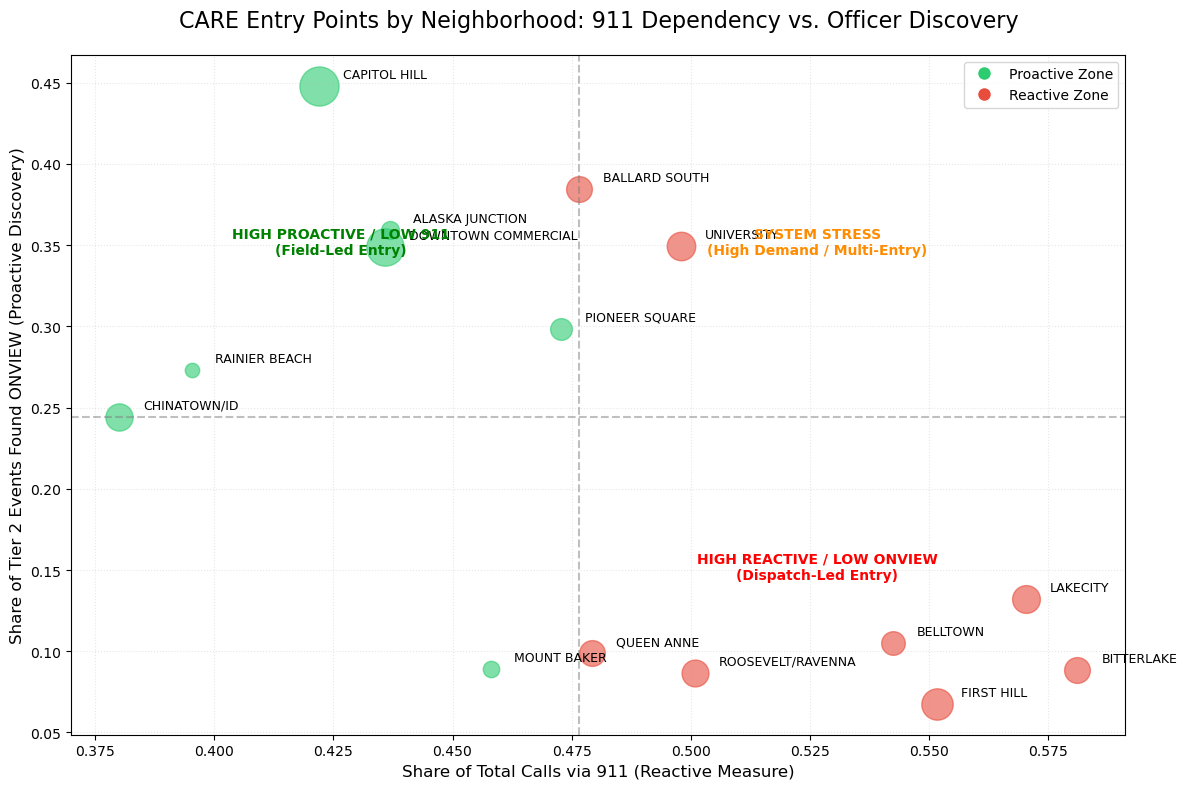

In [153]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    {"neighborhood": "FIRST HILL", "tier2_events": 1020, "share_911": 0.551703, "share_onview": 0.155881, "tier2_onview_share": 0.067647, "zone": "Reactive"},
    {"neighborhood": "UNIVERSITY", "tier2_events": 844, "share_911": 0.497975, "share_onview": 0.139426, "tier2_onview_share": 0.349526, "zone": "Reactive"},
    {"neighborhood": "LAKECITY", "tier2_events": 803, "share_911": 0.570239, "share_onview": 0.149428, "tier2_onview_share": 0.132005, "zone": "Reactive"},
    {"neighborhood": "ROOSEVELT/RAVENNA", "tier2_events": 750, "share_911": 0.500792, "share_onview": 0.131563, "tier2_onview_share": 0.086667, "zone": "Reactive"},
    {"neighborhood": "BALLARD SOUTH", "tier2_events": 689, "share_911": 0.476500, "share_onview": 0.211799, "tier2_onview_share": 0.384615, "zone": "Reactive"},
    {"neighborhood": "BITTERLAKE", "tier2_events": 689, "share_911": 0.581090, "share_onview": 0.159282, "tier2_onview_share": 0.088534, "zone": "Reactive"},
    {"neighborhood": "QUEEN ANNE", "tier2_events": 689, "share_911": 0.479262, "share_onview": 0.158920, "tier2_onview_share": 0.098694, "zone": "Reactive"},
    {"neighborhood": "BELLTOWN", "tier2_events": 580, "share_911": 0.542366, "share_onview": 0.204087, "tier2_onview_share": 0.105172, "zone": "Reactive"},
    {"neighborhood": "CAPITOL HILL", "tier2_events": 1589, "share_911": 0.421991, "share_onview": 0.335663, "tier2_onview_share": 0.448081, "zone": "Proactive"},
    {"neighborhood": "DOWNTOWN COMMERCIAL", "tier2_events": 1448, "share_911": 0.435880, "share_onview": 0.372630, "tier2_onview_share": 0.348757, "zone": "Proactive"},
    {"neighborhood": "CHINATOWN/ID", "tier2_events": 769, "share_911": 0.380076, "share_onview": 0.451308, "tier2_onview_share": 0.244473, "zone": "Proactive"},
    {"neighborhood": "PIONEER SQUARE", "tier2_events": 489, "share_911": 0.472719, "share_onview": 0.319205, "tier2_onview_share": 0.298569, "zone": "Proactive"},
    {"neighborhood": "ALASKA JUNCTION", "tier2_events": 334, "share_911": 0.436809, "share_onview": 0.302659, "tier2_onview_share": 0.359281, "zone": "Proactive"},
    {"neighborhood": "MOUNT BAKER", "tier2_events": 280, "share_911": 0.457998, "share_onview": 0.275335, "tier2_onview_share": 0.089286, "zone": "Proactive"},
    {"neighborhood": "RAINIER BEACH", "tier2_events": 216, "share_911": 0.395245, "share_onview": 0.388739, "tier2_onview_share": 0.273148, "zone": "Proactive"}
]

df_chart = pd.DataFrame(data)

plt.figure(figsize=(12, 8))
# Thresholds based on medians of these specific high-demand areas
x_thresh = df_chart["share_911"].median()
y_thresh = df_chart["tier2_onview_share"].median()

# Color mapping
colors = {'Proactive': '#2ecc71', 'Reactive': '#e74c3c'}

for i, row in df_chart.iterrows():
    plt.scatter(row['share_911'], row['tier2_onview_share'], 
                s=row['tier2_events'] * 0.5, # Size by volume
                alpha=0.6, 
                color=colors[row['zone']])
    plt.text(row['share_911'] + 0.005, row['tier2_onview_share'] + 0.005, row['neighborhood'], fontsize=9)

# Add quadrant lines
plt.axvline(x=x_thresh, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=y_thresh, color='gray', linestyle='--', alpha=0.5)

# Quadrant Labels
plt.text(x_thresh - 0.05, y_thresh + 0.1, "HIGH PROACTIVE / LOW 911\n(Field-Led Entry)", color='green', fontweight='bold', ha='center')
plt.text(x_thresh + 0.05, y_thresh + 0.1, "SYSTEM STRESS\n(High Demand / Multi-Entry)", color='darkorange', fontweight='bold', ha='center')
plt.text(x_thresh + 0.05, y_thresh - 0.1, "HIGH REACTIVE / LOW ONVIEW\n(Dispatch-Led Entry)", color='red', fontweight='bold', ha='center')

plt.title("CARE Entry Points by Neighborhood: 911 Dependency vs. Officer Discovery", fontsize=16, pad=20)
plt.xlabel("Share of Total Calls via 911 (Reactive Measure)", fontsize=12)
plt.ylabel("Share of Tier 2 Events Found ONVIEW (Proactive Discovery)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Proactive Zone', markerfacecolor='#2ecc71', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Reactive Zone', markerfacecolor='#e74c3c', markersize=10)]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig("care_quadrant_chart.png")
print("Chart saved as care_quadrant_chart.png")

extra images:

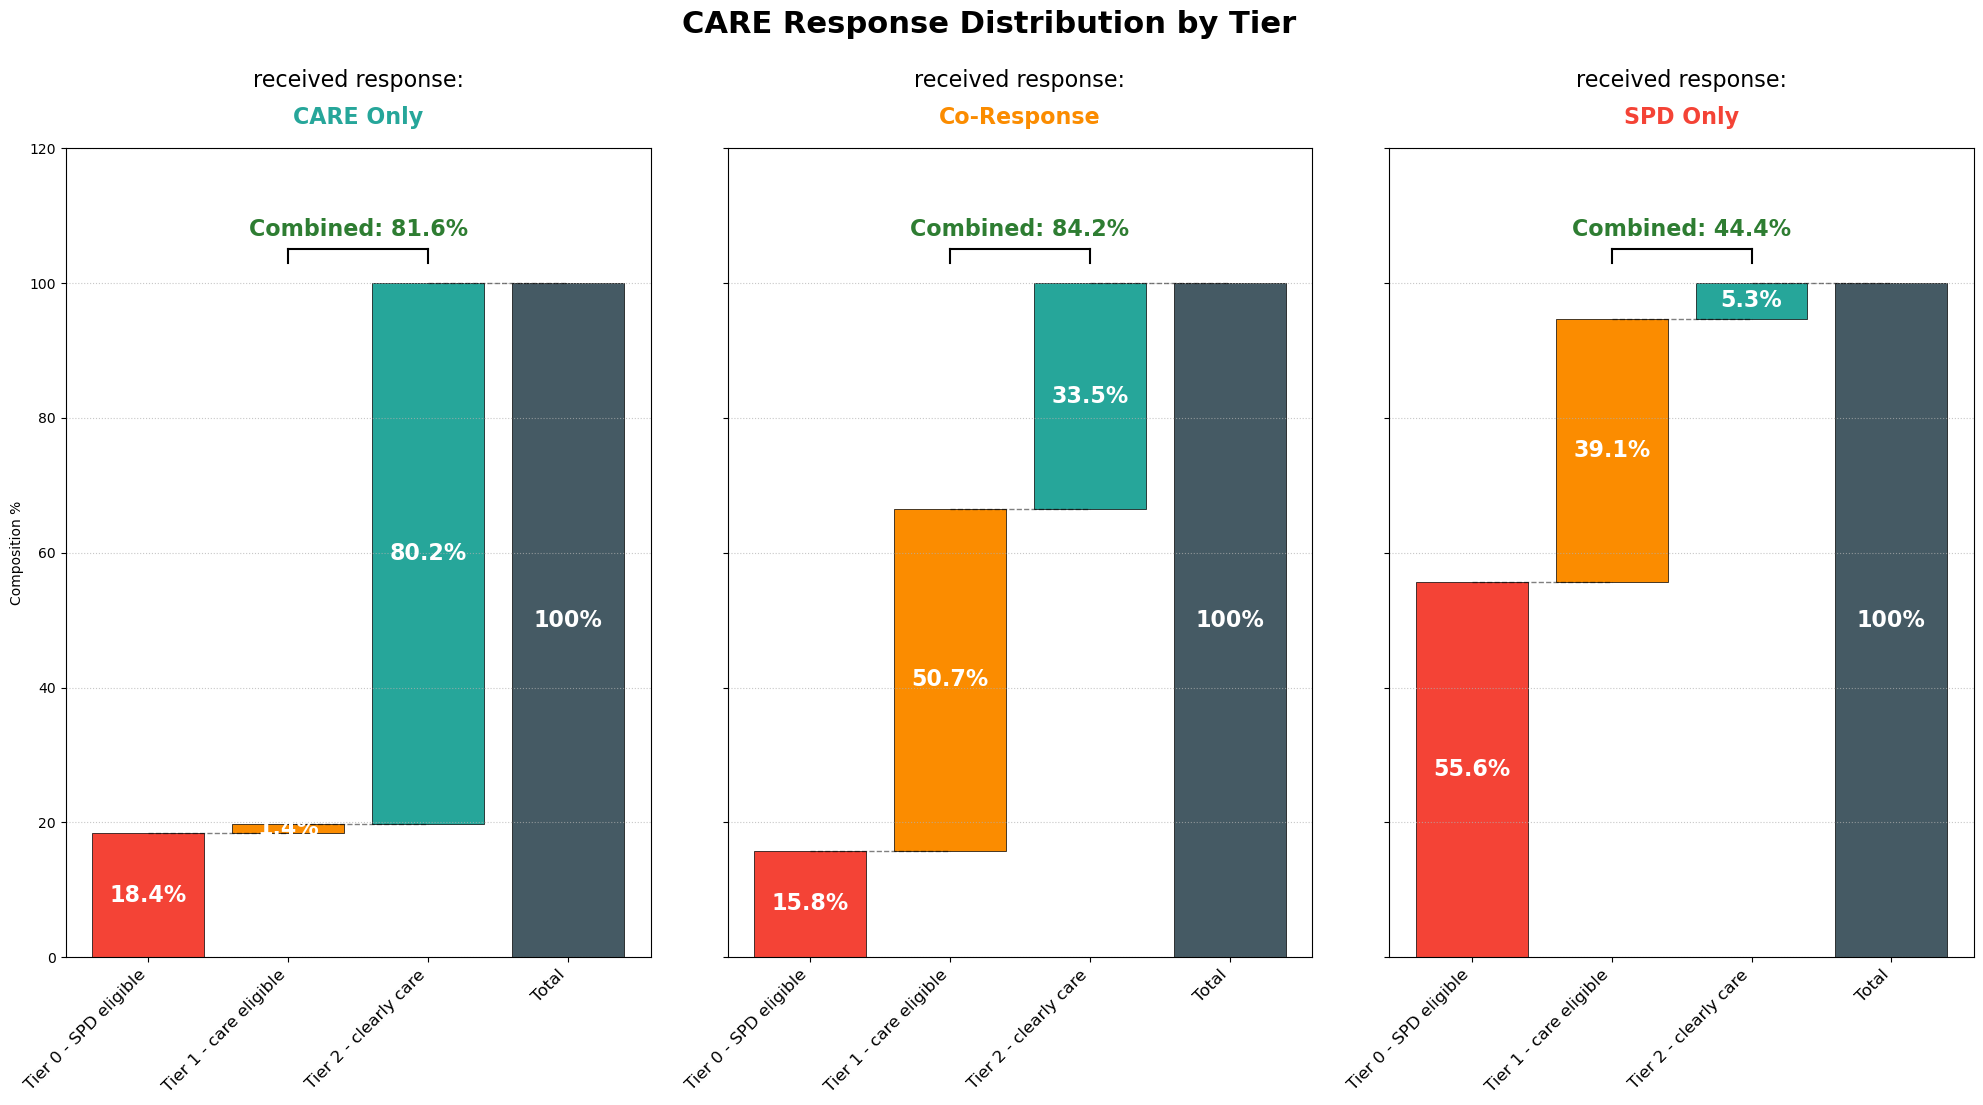

In [226]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['received response: CARE Only', 'received response: Co-Response', 'received response: SPD Only']
data = {
    'received response: CARE Only': {'Tier 0': 18.4, 'Tier 1': 1.4, 'Tier 2': 80.2},
    'received response: Co-Response': {'Tier 0': 15.8, 'Tier 1': 50.7, 'Tier 2': 33.5},
    'received response: SPD Only': {'Tier 0': 55.6, 'Tier 1': 39.1, 'Tier 2': 5.3}
}

# Color Mapping
colors = ['#f44336', '#fb8c00', '#26a69a'] # Red, Orange, Green
total_color = '#455a64'
title_colors = {
    'CARE Only': '#26a69a', 
    'Co-Response': '#fb8c00', 
    'SPD Only': '#f44336'
}

labels = ['Tier 0 - SPD eligible', 'Tier 1 - care eligible', 'Tier 2 - clearly care', 'Total']

fig, axes = plt.subplots(1, 3, figsize=(20, 11), sharey=True)
fig.suptitle('CARE Response Distribution by Tier', fontsize=22, fontweight='bold', y=1)

for i, full_cat_name in enumerate(categories):
    ax = axes[i]
    values = [data[full_cat_name]['Tier 0'], data[full_cat_name]['Tier 1'], data[full_cat_name]['Tier 2']]
    cumulative = np.cumsum([0] + values)
    
    # 1. Plot Tiers
    for j in range(3):
        ax.bar(labels[j], values[j], bottom=cumulative[j], color=colors[j], edgecolor='black', linewidth=0.5)
        ax.text(j, cumulative[j] + values[j]/2, f'{values[j]}%', ha='center', va='center', color='white', fontsize=16, fontweight='bold')
        
        if j < 2:
            ax.plot([j, j+1], [cumulative[j+1], cumulative[j+1]], color='black', linestyle='--', linewidth=1, alpha=0.5)

    # 2. Combined T1 + T2 Highlight
    t1_t2_sum = values[1] + values[2]
    # Draw a bracket-like line over Tier 1 and Tier 2
    bracket_y = max(cumulative) + 5
    ax.plot([1, 2], [bracket_y, bracket_y], color='black', lw=1.5)
    ax.plot([1, 1], [bracket_y - 2, bracket_y], color='black', lw=1.5)
    ax.plot([2, 2], [bracket_y - 2, bracket_y], color='black', lw=1.5)
    ax.text(1.5, bracket_y + 2, f'Combined: {t1_t2_sum:.1f}%', ha='center', fontsize=16, fontweight='bold', color='#2e7d32')

    # 3. Final Total Bar
    ax.bar(labels[3], 100, color=total_color, edgecolor='black', linewidth=0.5)
    ax.text(3, 50, '100%', ha='center', va='center', color='white', fontweight='bold', fontsize=16)
    ax.plot([2, 3], [100, 100], color='black', linestyle='--', linewidth=1, alpha=0.5)

    # 4. Bold and Colored Titles
    # Extract the phrase to color
    phrase = full_cat_name.split(': ')[1]
    ax.set_title(f'received response:\n', fontsize=16, loc='center', pad=25)
    ax.text(0.5, 1.03, phrase, transform=ax.transAxes, fontsize=16, fontweight='bold', 
            color=title_colors[phrase], ha='center')

    # Formatting
    ax.set_ylim(0, 120)
    ax.set_ylabel('Composition %' if i == 0 else '')
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=12, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('waterfall_analysis_final.png', bbox_inches='tight', dpi=300)
plt.show()

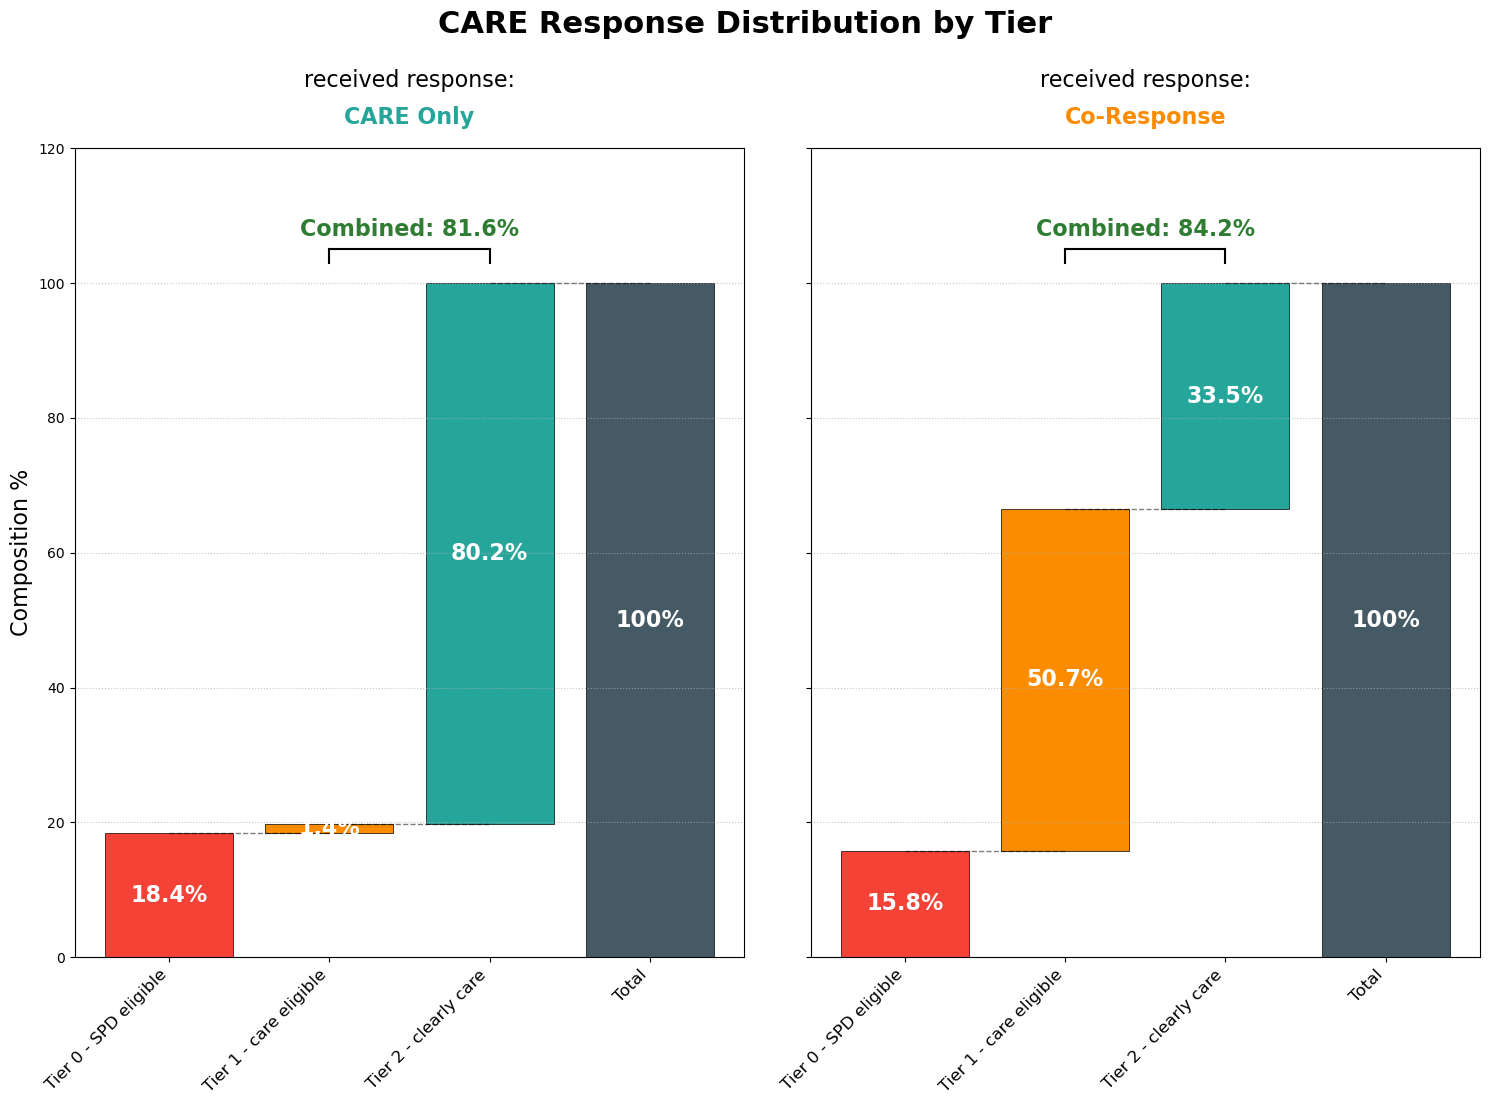

In [235]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['received response: CARE Only', 'received response: Co-Response']
data = {
    'received response: CARE Only': {'Tier 0': 18.4, 'Tier 1': 1.4, 'Tier 2': 80.2},
    'received response: Co-Response': {'Tier 0': 15.8, 'Tier 1': 50.7, 'Tier 2': 33.5}
}

# Color Mapping
colors = ['#f44336', '#fb8c00', '#26a69a'] # Red, Orange, Green
total_color = '#455a64'
title_colors = {
    'CARE Only': '#26a69a', 
    'Co-Response': '#fb8c00'
}

labels = ['Tier 0 - SPD eligible', 'Tier 1 - care eligible', 'Tier 2 - clearly care', 'Total']

fig, axes = plt.subplots(1, 2, figsize=(15, 11), sharey=True)
fig.suptitle('CARE Response Distribution by Tier', fontsize=22, fontweight='bold', y=1)

for i, full_cat_name in enumerate(categories):
    ax = axes[i]
    values = [data[full_cat_name]['Tier 0'], data[full_cat_name]['Tier 1'], data[full_cat_name]['Tier 2']]
    cumulative = np.cumsum([0] + values)
    
    # 1. Plot Tiers
    for j in range(3):
        ax.bar(labels[j], values[j], bottom=cumulative[j], color=colors[j], edgecolor='black', linewidth=0.5)
        ax.text(j, cumulative[j] + values[j]/2, f'{values[j]}%', ha='center', va='center', color='white', fontsize=16, fontweight='bold')
        
        if j < 2:
            ax.plot([j, j+1], [cumulative[j+1], cumulative[j+1]], color='black', linestyle='--', linewidth=1, alpha=0.5)

    # 2. Combined T1 + T2 Highlight
    t1_t2_sum = values[1] + values[2]
    # Draw a bracket-like line over Tier 1 and Tier 2
    bracket_y = max(cumulative) + 5
    ax.plot([1, 2], [bracket_y, bracket_y], color='black', lw=1.5)
    ax.plot([1, 1], [bracket_y - 2, bracket_y], color='black', lw=1.5)
    ax.plot([2, 2], [bracket_y - 2, bracket_y], color='black', lw=1.5)
    ax.text(1.5, bracket_y + 2, f'Combined: {t1_t2_sum:.1f}%', ha='center', fontsize=16, fontweight='bold', color='#2e7d32')

    # 3. Final Total Bar
    ax.bar(labels[3], 100, color=total_color, edgecolor='black', linewidth=0.5)
    ax.text(3, 50, '100%', ha='center', va='center', color='white', fontweight='bold', fontsize=16)
    ax.plot([2, 3], [100, 100], color='black', linestyle='--', linewidth=1, alpha=0.5)

    # 4. Bold and Colored Titles
    # Extract the phrase to color
    phrase = full_cat_name.split(': ')[1]
    ax.set_title(f'received response:\n', fontsize=16, loc='center', pad=25)
    ax.text(0.5, 1.03, phrase, transform=ax.transAxes, fontsize=16, fontweight='bold', 
            color=title_colors[phrase], ha='center')

    # Formatting
    ax.set_ylim(0, 120)
    ax.set_ylabel('Composition %' if i == 0 else '', fontsize=16)
    ax.grid(axis='y', linestyle=':', alpha=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=12, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('waterfall_analysis_final.png', bbox_inches='tight', dpi=300)
plt.show()